# Introduction à CKKS

Jocelyn Maury

jocelyn.maury@univ-st-etienne.fr

Ce jupyter notebook à pour but d'expliquer les bases de CKKS. CKKS est un schéma cryptographique qui permet de réaliser des opérations (addition et multiplication) sur des valeurs chiffrées qui aboutissent approximativement au même résultat une fois le résultat déchiffré que si les opérations avaient été effectuées sur les données en clair. 

Ce notebook est basé sur plusieurs ressources, et fortement basé sur les deux ressource suivante : https://arxiv.org/pdf/2503.05136 et https://eprint.iacr.org/2016/421.pdf 

# Encodage

La sécurité de CKKS est basée sur le problème de "RLWE". Ce problème repose sur le présupposé qu'il est très dur de trouver $m$ une fois chiffré de la façon suivante : 
$$m_i = - A_i \times S + m_i + e_i$$
avec $m_i$ un message, $A_i$ un polynôme public tiré de façon aléatoire, $S$ un polynôme privé aléatoire à coefficient compris dans l'ensemble {-1, 0, 1} et $e_i$ un petit bruit gaussien aléatoire. Pour chiffrer un message de cette façon, nous avons besoin que notre message soit un polynôme car le problème vis dans l'anneau des polynômes cyclotomiques à coefficents entier : $\mathbf{Z}[X]/X^N +1$ avec $N$ une puissance de 2, pour des raisons de sécurité.   

Cependant, dans la plupart des application, les valeurs d'entrées sur lesquelles nous souhaitons réaliser des opérations ne sont pas directement des polynômes : Elles peuvent être des réels ou des complexes. Donc nous cherchons une façon de transformer nos complexes en polynômes cyclotomiques à coefficient réels. Il faut que cette transformation soit bijective et homomorphe : Nous cherchons donc un isomoprhisme $\mathbb{C}^N \to \mathbf{Z}[X]/X^N +1$. 

Le théorème d'interpolation de Lagrange nous indique qu'à partir de couples de points $(x_1, y_1), (x_2, y_2)...(x_n, y_n)$ il y a un seul polynôme de degré maximum $n - 1$ qui passe par tout ces point. Ainsi, en prenant les points d'entrées noté $y$ et en définissant un ensemble de points d'évaluation de ces points d'entrées noté $x$, nous pouvons calculer les coefficients du polynôme unique qui passe par tout ces points, noté $c$. Matriciellement,  nous pouvons poser que les points d'évaluations multipliés par les coefficients du polynôme unique nous donnerons un ensemble de points tel que 

$$
\begin{array}{cc}
\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
=
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
\Rightarrow X \cdot c = y
\end{array} 
$$



Nous, nous disposerons du vecteur d'entrée $y$ et des points d'évaluations $X$ et nous chercherons à calculer les coefficients du polynômes uniques passant par tout les couples de points $(x,y)$. Cela revient à résoudre l'équation suivante : 
$$
X^{-1} \cdot  y = c$$
soit 
$$\begin{pmatrix}  
1 & x_{1} & x_{1}^{2} & \cdots & x_{1}^{n - 1} \\  
1 & x_{2} & x_{2}^{2} & \cdots & x_{2}^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & x_{n} & x_{n}^{2} & \cdots & x_{n}^{n - 1}
\end{pmatrix} ^{-1}
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{pmatrix}
=
\begin{pmatrix}
c_1 \\
c_2 \\
\vdots \\
c_n
\end{pmatrix} 
$$ 

Il faut donc s'assurer que la matrice $X$ soit toujours inversible. Comme elle est constituée pour chaque ligne d'un $x_i$ qui augmente en puissance de colonne en colonne, il s'agit en fait d'une matrice de Vandermonde :

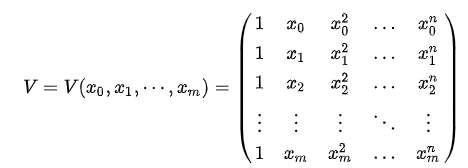

https://en.wikipedia.org/wiki/Vandermonde_matrix

Une matrice de Vandermonde est toujours inversible si les $\alpha_i$ sont tous distincts deux à deux. Ainsi, avec la contrainte de choisir des $x_i$ tous distincts deux à deux, nous nous assurons que notre matrice $X$, que nous nommerons à présent $V$ est toujours inversible. Il nous faut nous intéresser à la nature des $x_i$ qui compose $V$. Comme nous travaillons dans $\mathbf{Z}[X]/X^N+1$, cela signifie que les $x_i$ de notre matrice $V$ doivent respecter la relation $x_i^n +1 =0$. Donc on a : 
$$ \begin{array}{cc}\\
x_{i}^{n} +1=0 \\
x_i^n = -1 \\
x^{2n}_i = (-1)^2 = 1
\end{array}
$$
Donc les $x_i^n = -1$ font partie de l'ensemble des $2n$ ième racines unités. 

https://e.math.cornell.edu/people/belk/numbertheory/CyclotomicPolynomials.pdf

https://en.wikipedia.org/wiki/Cyclotomic_polynomial

De plus, pour trouver les solutions à $x^{2n}_i = 1$, nous pouvons poser
$$\begin{array}{cc}
x^{2n}_i = 1 \\
(x^{n} + 1)(x^{n} - 1) = 0
\end{array}
$$
Nous connaissons déjà les solutions à $x^{2n}_i = 1$, ce sont les $2n$ e racines unités, sachant que classiquement, nous avons les $n$ e racines unités représentées par l'ensemble de complexes suivant : $\{ \zeta^N = 1 : \zeta = e^{2k \pi i /n }, 0 \leq k < n \}$, donc les $2n$ e racines unités sont notées $\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \}$. 
Nous, nous cherchons l'ensemble de solutions à $(x^n + 1) = 0$ et nous connaissons les solutions à $X^{2n} - 1 = 0$ ce qui revient à l'ensemble des solutions de $(x^n +1)(x^n -1) = 0$. Donc si nous arrivons à déterminer l'ensemble des solutions de $(x^n -1) = 0$ alors nous pourrons faire :  
$$
\begin{array}{cc}
\{\text{2ne racines unités}\} - \{\text{solutions à }(x^n - 1 = 0)\} = \{\text{solutions à }(x^n + 1 = 0) \}
\end{array}
$$
Donc nous cherchons 
$$
\begin{array}{cc}
x^n - 1 = 0 \\
x^n = 1  \\
\Rightarrow \{\zeta'^n =1 : \zeta' = e^{2k \pi i / n}, 0 \leq k' < n\}
\end{array}
$$
Les solutions à $(x^n + 1 = 0)$ sont les $2ne$ racines unités qui ne sont pas solutions à $(x^n - 1 = 0)$ donc nous cherchons 
$$
\begin{array}{cc}
\{ \zeta^{2N} = 1 : \zeta = e^{2k \pi i / 2N} = e^{k \pi i / n}, 0 \leq k < 2N  \} \neq \{\zeta'^n =1 : \zeta' = e^{2k' \pi i / n}, 0 \leq k' < n\} \\
\zeta = e^{k \pi i /n}, \zeta' = e^{2k' \pi i /n}  \\
\zeta = \zeta' \text{ ssi } k = 2k', \text{ soit } \frac{k}{2} = k'
\end{array}
$$
Comme $k,k' \in \mathbb{Z}$ alors $k$ doit être un multiple de $2$ (un nombre pair). A l'inverse, pour tout les cas où $k$ est impair, ce n'est plus solution à $(x^n =1)$ et donc solution à $(x^n = -1)$. Ainsi, les racines de $(x^n = -1)$ sont les $n$ complexes distincts suivants : 
$$
\begin {array}{cc}
\{\zeta = e^k \pi i /n, 0 \leq k < 2N, 2 \nmid k \} \\
= \omega, \omega^3, \omega^5,\dots, w^{2n -1}
\end{array}
$$


Donc nous pouvons construire une matrice $V$ avec tout les $x_i$ distincts et qui respectent $x_i^n +1 =0$.
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
$$

Il nous faut vérifier la bijectivité de l'application $V$. En effet, même si le théorème d'interpolation de Lagrange semble nous donner la bijectivité, il faut vérifier que l'on en respecte le cadre : 

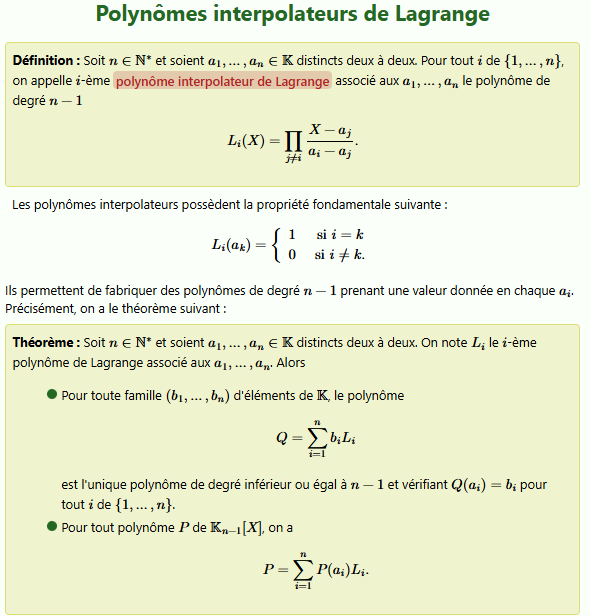

https://www.bibmath.net/dico/index.php?action=affiche&quoi=./p/polynomelagrange.html

Pour plus de lisibilité, nous allons nous servir de la propriété suivante pour notre matrice de Vandermonde $V^{-1}= \frac{V^T \cdot \ I^R_n}{n}$. 

Tout d'abord : 
$$
\begin{array}{cc}
V \cdot V^T = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\cdot
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\
=
\begin{pmatrix}
\sum_{k=0}^{n-1}\omega^{2k} & \sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \cdots & \sum_{k=0}^{n-1}\omega^{2nk} \\
\sum_{k=0}^{n-1}\omega^{4k} & \sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+1)} \\
\sum_{k=0}^{n-1}\omega^{6k} & \sum_{k=0}^{n-1}\omega^{8k} &\sum_{k=0}^{n-1}\omega^{10k} & \cdots & \sum_{k=0}^{n-1}\omega^{2k(n+2)} \\
\vdots & & \ddots & & \vdots \\
\sum_{k=0}^{n-1}\omega^{2nk} & \sum_{k=0}^{n-1}\omega^{2(n+1)k}  &  \sum_{k=0}^{n-1}\omega^{2(n+2)k} & \cdots &  \sum_{k=0}^{n-1}\omega^{2(n+n-1)k}
\end{pmatrix}
\end{array}
$$
Nous pouvons voir que tout les éléments antidiagonales sont $\sum_{k=0}^{n-1}\omega^{2nk}$ donc : 
$$\begin{array}{cc}
\sum_{k=0}^{n-1}\omega^{2nk} \\ 
= \sum_{k=0}^{n-1} e^{(i \pi /n)2nk} \\
= \sum_{k=0}^{n-1} e^{2 i \pi k} \\
= \sum_{k=0}^{n-1} (cos(2 \pi k) + i sin(2 \pi k)) \\
= \sum_{k=0}^{n-1} (1 + 0) = n
\end{array}
$$
Donc les éléments anti-diagonaux sont uniquement $n$. Pour les autres éléments $\sum_{i=0}^{n-1} \omega^{2k}, \sum_{i=0}^{n-1} \omega^{4k}, \dots, \sum_{i=0}^{n-1} \omega^{2(2n-1)k}$ nous pouvons identifier qu'ils sont tous de la forme $\sum_{k=0}^{n-1} \omega^{2(m)k}$ avec $1 \leq m < n-1$. Nous avons grâce à la formule de la somme géométrique : 
$$
\begin{array}{cc}
S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} \\
x \cdot S_n = x + x^2 + x^3 + \dots + x^n \\
x \cdot S_n - S_n = (x + x^2 + x^3 + \dots + x^n) - (1 + x + x^2 + \dots + x^{n-1}) = x^n - 1 \\
S_n \cdot(x - 1) = x^n -1 \\
S_n = \frac{x^n -1}{x - 1} \text{tant que }x \neq 1 \\
\text{Donc } S_n = \sum_{i=0}^{n-1} x^i = 1 + x + x^2 + \dots + x^{n-1} = \frac{x^n -1}{x - 1}
\end{array}
$$

Grâce à cette formule on a : 
$$
\begin{array}{cc}
\sum_{k=0}^{n-1} \omega^{2(m)k} = \frac{\omega^{(2m)n} - 1}{\omega^{2m} - 1} \\
= \frac{\omega^{(2n)m} - 1}{\omega^{2m} - 1} \\
= \frac{1 - 1}{\omega^{2m} - 1} = 0 \text{ tant que } 0 \leq m < n
\end{array}
$$
Ainsi, nous pouvons réécrire l'inverse comme : 
$$V \cdot V^T = 
\begin{pmatrix}
0 & \cdots & 0 & 0 & n \\
0 & \cdots & 0 & n & 0 \\
0 & \cdots & n & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
n & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
 = n \cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
= n \cdot I^R_n
$$
avec $I^R_n$ la matrice de renversement (elle a pour effet d'échanger l'odre des colonnes, la première passe dernière, la deuxième passe avant dernière...).
A partir de ce résultat : 
$$
\begin{array}{cc}
V \cdot V^T = n \cdot I^R_n \\
V^{-1} \cdot V \cdot V^T = V^{-1} \cdot n \cdot I^R_n \\
V^T = V^{-1} \cdot n \cdot I^R_n \\
\frac{V^T \cdot I^R_n}{n} = V^{-1}
\end{array}
$$


A partir de là, nous pouvons étudier comment seront calculés les coefficients des polynômes, pour voir les contraintes nécessaires pour que les parties imaginaires s'annulent : 
$$
\begin{array}{cc}
V^{-1} \cdot y  = c  \\ \\
\frac{V^T \cdot I^R_n}{n} \cdot y \propto V^T \cdot I^R_n \cdot y \\ \\
\propto 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\ \\
=   
\begin{pmatrix}
1 & 1 & \cdots & 1 & 1 \\
\omega^{2n-1}  & \omega^{2n-3} & \cdots & \omega^3 & \omega \\
(\omega^{2n-1})^2  & (\omega^{2n-3})^2 & \cdots &  (\omega^3)^2 & (\omega)^2  \\
\vdots & & \ddots & & \vdots \\
(\omega^{2n-1})^{n-1} & (\omega^{2n-3})^{n-1} &  \cdots &  (\omega^3)^{n-1} &  (\omega)^{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix} \\
= \begin{pmatrix}
\sum_{i=1}^{n}y_i \\
\sum_{i=1}^{n}y_i \omega^{2n - (2i-1)} \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{2}} \\
\vdots \\
\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))^{n-1}} \\
\end{pmatrix}
\end{array}
$$
Ainsi, nous avons la forme explicite de nos coefficients à un facteur prêt Nous pouvons voir qu'il s'agit de combinaisons linéaires entre nos valeurs en entrées et les points d'évaluation. En entrée, nous avons des $y_i \in \mathbb{C}$ donc  $\sum_{i=0}^{n-1}y_i \in \mathbb{C}$ sauf si les valeurs imaginaires se compensent entre elles. De plus, le produit pondéré des points d'évaluation $\omega_i$ donnera aussi un résultat dans $\mathbb{C}$ sauf si les parties imaginaires des points d'évaluation se compensent entre elles après pondération par les $y_i$. Sans cette annulation de la partie imaginaire, notre vecteur de coefficients de polynôme $c^N \in \mathbf{C}[X]/X^N +1$ et non $\mathbf{Z}[X]/X^N + 1$.
Donc nous voulons nous assurer que 
- $\sum_{i=1}^{n}y_i = a + 0i$ avec $a \in \mathbb{R}$.
- $\sum_{i=1}^{n}y_i \omega^{(2n - (2i-1))b} = a + 0i$ avec $a \in \mathbb{R}, 1 \leq b < n$.

Comme nous voulons que les valeurs du vecteur d'entrée soit à choix libre, il faut construire un $y'$, basé sur $y$ qui respecte $\sum_{i=0}^{n-1}y_i = a + 0i$. Une façon efficace de faire cela est de prendre $y' = (y_1, y_2,\dots, y_n ) | (\overline{y_1}, \overline{y_2}, \dots, \overline{y_n}) = (y_1, y_2,\dots, y_n, \overline{y_1}, \overline{y_2}, \dots, \overline{y_n} ) = (y | \overline{y})$  soit la concaténation de $y$ avec son conjugué. Ainsi, $\sum_{i=0}^{n-1}{y'_i} = a + 0i$.

Pour le deuxième cas, nous avons une somme de produit pondéré, sachant que les $y'$ s'annulent leur partie imaginaire entre eux. Il faudrait donc une symétrie de conjugués sur les $\omega$ pour s'assurer que les parties imaginaires s'annulent bien : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1)b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
De cette façon, les parties imaginaires s'annulent entre elles deux à deux. 
Comme le choix des $\omega$ n'est pas arbitraire, il faut vérifier qu'ils respectent la relation : $\omega_i = \overline{\omega_{2n - i}}$, i.e : 
$$
\begin{array}{cc}
\omega_1 = \overline{\omega_{2n-1}} \\
\omega_3 = \overline{\omega_{2n-3}} \\
\omega_5 = \overline{\omega_{2n-5}} \\
\dots \\
\omega_{n-1} = \overline{\omega_{n+1}} \\
\dots \\
\omega_{2n-1} = \overline{\omega_{1}} \\
\end{array}
$$
Cette relation est vraie et peut être dérivée directement à partir de la formule d'Euler. 
Grâce à cette relation, nous savons que nous avons bien
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_1}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_n}\overline{\omega^{(2n-1)b}}
\end{array}
$$
Cependant, nous pouvons voir que nous avons $y_n \times \omega^{(2n - (n-1))b} + \overline{y_1} \times \overline{\omega^{(2n - (2n+1))b}}$ . Les parties imaginaires ne sont pas forcées de s'annuler car nous les $y_i$ ne sont pas alignés avec leur $\omega$. Nous souhaitons avoir $y_n \times \omega^{(2n - (n-1))b} + \overline{y_n} \times \overline{\omega^{(2n - (2n+1))b}}$, ce qui nous donnerait dans la somme total : 
$$
\begin{array}{cc}
\sum_{i=1}^{n}y'_i \omega^{(2n - (2i-1))b} \\ 
= y_1\omega^{(2n -1)b} + \dots + y_n\omega^{(2n-(n-1))b} + \overline{y_n}\overline{\omega^{(2n-(2n+1))b}} + \dots + \overline{y_1}\overline{\omega^{(2n -1)b}}
\end{array}
$$

Donc nous devons modifier $y' = (y_1, \dots, y_n, \overline{y_1}, \dots, \overline{y_n}) =(y | \overline{y})$ en $y' = (y_1, \dots, y_n, \overline{y_n}, \dots, \overline{y_1}) = (y | \text{ reverse order}(\overline{y}))$. En construisant $y'$ de cette façon et grâce à la structure particulière de $V$ nous avons donc $\frac{V^T \cdot I^R_N}{n} \cdot y = c \in \mathbb{R}^N$. 

Nous ne faisons plus $\mathbf{R}[X]/X^N +1 \to \mathbb{C}^N$ car il était impossible d'avoir bijectivité (bijectivité uniquement possible pour $\mathbf{C}[X]/X^N +1 \to \mathbb{C}^N$). A la place nous faisons $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}}^N \to \mathbb{C}^{N/2}$. Nous avons réduit notre espace d'entrée par deux.  Cependant, nous ne somme toujours pas dans $\mathbf{Z}[X]/X^N +1$. Nous réglerons ce problème plus tard. 
Maintenant que nous avons la bijectivité, nous avons besoin de vérifier que $V$ est aussi homomorphique pour avoir isomorphisme entre l'anneau $\mathbf{R}[X]/X^N +1$ et $\mathbb{C}^{N/2}$. Pour cela, il faut que : 
- $V(c + d) = Vc + Vd$, vérifié par linéarité de matrice 
- $V(c * d) = Vc ? Vd$ avec $?$ une opération multiplicative qui permet à $C^{N/2}$ muni de l'addition et $?$ d'être un anneau. L'opération $*$ désigne la convolution, qui correspond à la multiplication de polynôme. 
Posons deux polynômes $c(X) = \sum_{i=0}^{n-1} c_i X^i;  \ d(X) = \sum_{j=0}^{n-1} d_j X^j$. La multiplication des deux polynômes nous donne : 
$$\begin{array}{cc}\\
c(X)d(X) \\
= (\sum_{i=0}^{n-1} c_i X^i) (\sum_{j=0}^{n-1} d_j X^j) \\
= \sum_{i=0}^{n-1}\sum_{j=0}^{n-1}c_i d_j X^{i+j}
\end{array}
$$
Pour simplifier la démonstration, nous pouvons regarder ce qu'il se passe au niveau d'une composante de $(V(c * d))_k$ qui consiste donc à évaluer le polynômes en la composante $\omega_k$ :
$$\begin{array} {cc}
(V(c * d))_k \\
= (\sum_{i=0}^{n-1} c_i \omega^i_k) (\sum_{j=0}^{n-1} d_j \omega^j_k) \\
= (Vc)_k )(Vd)_k
\end{array}$$
De cette façon le vecteur $V(c * d)$ est constitué des produits suivants : 
$$\begin{pmatrix}
(Vc)_0(Vd)_0 \\
(Vc)_1(Vd)_1 \\
\vdots \\
(Vc)_{n-1}(Vd)_{n-1} \\
\end{pmatrix} = Vc \ \odot \ Vd$$
Ce qui nous donne : 
$$V(c * d) = Vc \ \odot Vd$$
Donc on a un isomorphisme d'anneau $R[X]/X^N +1 \to C^{N/2}$ grâce à $V$ : 
$$\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
\vdots \\
c_n
\end{pmatrix} 
= 
\begin{pmatrix}
y_1 \\
y_2 \\
y_3 \\
\vdots \\
y_n
\end{pmatrix}
$$
soit 
$$Vc = y$$
et donc 
$$V^{-1}y = c$$
C'est sur cet isomorphisme que repose l'encodage de CKKS. Nous prenons en entrée un vecteur de complexes $y$ puis nous le concaténons à son conjugué, pour ensuite l'évaluer en les racines unités pour obtenir les coefficients du polynôme qui servira de vecteur encodé. Pour passer dans l'espace $Z[X]/X^N +1$ nous allons arrondir les coefficient à l'entier le plus proche. Si nous nous contentons de directement arrondir, nous allons perdre énormément de précision. Pour garder le maximum de précision possible, nous multiplions au préalable nos coefficient par un facteur $\Delta$ : $\tilde{c} = \lfloor \Delta c \rceil$. 

Une question intéressante à étudier est l'impact du rounding sur la précision de résultat après décodage. En effet, la transformation opérée par $V$ nous permet d'avoir $V(V^{-1}y) = y$.  
$$
\begin{array}{cc}
V(V^{-1}y) = y \\
V(\Delta V^{-1}y) \times \frac{1}{\Delta}= y 
\end{array}
$$
mais nous effectuons en réalité : $V(\lfloor \Delta V^{-1}y \rceil)$. Le rounding de chaque valeur de $V^{-1}y = c$ entraîne une erreur maximale de $|\frac{1}{2}|$ sur chaque coordonnée. Comment un changement maximale de $\frac{1}{2}$ sur chaque coordonnées peut impacté le décodage ? Est-ce que $V^{-1}$ est très sensible au changement de ses inputs ?  
L'article suivant https://eprint.iacr.org/2022/162.pdf nous donne les bornes intéressantes suivantes : 
- **Lemma 1** : $\text{Let m} \in \mathbb{R}^N. \text{Then } ||m||_{\infty} \leq ||m||^{can}_\infty$.
- **Lemma 2** : $\text{Let m} \in \mathbb{R}^N. \text{Then } ||m||^{can}_\infty \leq N||m||_{\infty}$.

Ce sont les bornes les plus simples, il en existe de meilleurs mais je garde celles-ci pour que la suite soient plus claires (pour des bornes plus précises, se référer au papier).
Lorsque nous encodons, nous avons dans le pire cas : 
$$
\begin{array}{cc}
\lfloor \Delta V^{-1}y \rceil= \Delta V^{-1}y + \text{rounding error} \\
|\lfloor \Delta V^{-1}y \rceil | = \Delta V^{-1}y + |[\frac{1}{2}]^N| \\
\end{array}
$$
Cette erreur d'arrondi affecte le décodage comme suit : 
$$
\begin{array}{cc}
\frac{1}{\Delta} V \lfloor \Delta V^{-1}y \rceil  =\frac{1}{\Delta} V(\Delta V^{-1}y + \text{rounding error})  \\
\frac{1}{\Delta} | V \lfloor \Delta V^{-1}y \rceil | \leq \frac{1}{\Delta} V \Delta V^{-1}y + V \times |[\frac{1}{2}]^N| \cdot \frac{1}{\Delta}
\end{array}
$$
Comme nous connaissons la borne $||m||^{can}_\infty \leq N||m||_{\infty}$ alors nous pouvons borner $V \times |[\frac{1}{2}]^N| \cdot \frac{1}{\Delta}$ : 
$$
\begin{array}{cc}
 V \times |[\frac{1}{2}]^N| \cdot \frac{1}{\Delta} = (\frac{1}{\Delta} |[\frac{1}{2}]^N|)^{can} \\
 ||(\frac{1}{\Delta} |[\frac{1}{2}]^N|)||^{can}_{\infty} \leq N||(\frac{1}{\Delta} |[\frac{1}{2}]^N|)||_{\infty} \\
 ||(\frac{1}{\Delta} |[\frac{1}{2}]^N|)||^{can}_{\infty} \leq \frac{N}{2\Delta}
\end{array}
$$
Ainsi, l'impact du rounding sur le décodage est borné par $\frac{N}{2 \Delta}$. Donc pour un même niveau de précision $\Delta$ donné, le décodage sera moins exacte à mesure que $N$ grandit. Nous pouvons aussi voir qu'il suffit d'avoir un $\Delta$ suffisamment grand pour outrepasser cette contrainte. 







Au final, nous opérons les opérations d'encodage et de décodage suivantes : 
$$
y \in \mathbb{C^{N/2}} \to y' \in \hat{\mathbb{C}}^N \to c \in \mathbf{R}[X]/X^N +1 \to \tilde{c} \in \mathbf{Z}[X]/X^N +1 \to \tilde{y'} \in \hat{\mathbb{C}}^N \to \tilde{y} \in \mathbb{C^{N/2}}
$$

Pour garder les calculs les plus simple possible, nous allons travailler avec des coefficients modulo $t$ pour garder la taille des coefficient plus petit qu'une certaine limite. Pour ce faire, nous allons travailler dans $\mathbf{Z}_t[X]/X^N + 1$. Pour choisir le modulus $t$ nous devons prendre en compte plusieurs facteurs : 
- Nombre d'opérations souhaitées 
- Tailles des messages en entrées 
- Bruit tolérables 
- Cohérent avec la NTT/FTT pour la multiplication optimisée dans $Z[X]/X^N +1$. 

Pour la taille des messages d'entrées, nous devons nous assurer que $\Delta m$ n'overflow pas, donc $\Delta m < t$. 
Les opérations possibles sont l'addition et la multiplication. Donc nous aimerions nous assurer que nous pouvons au moins faire une multiplication ou une addition de deux messages encodés. Evidemment, cela dépend directement de la taille des messages en entrée et de leur taille une fois encodés. Si nous définissons le message de taille maximum $m_{max}$ alors l'addition prend une taille $\Delta m_{max} + \Delta m_{max}$ et la multiplication $\Delta m_{max} \cdot \Delta m_{max}$. En supposant que $\Delta m_{max} \geq 2$  alors $| \Delta m_{max} \cdot \Delta m_{max} | \geq | \Delta m_{max} + \Delta m_{max} |$. Donc il faut choisir $t \geq | \Delta m_{max} \cdot \Delta m_{max} |$. Comme nous travaillons avec des polynômes, il faut s'assurer en réalité qu'aucun des coefficient des polynômes ne soit plus grand que $t$. Posons $|a_i| < B$ pour $a_i$ les coefficients de $\Delta m_{max}$. Ainsi $| \Delta m_{max} \cdot \Delta m_{max} | \leq NB^2$ avec $N$ le degré du polynôme.  Donc il faut au moins prendre $t \geq NB^2$.  

Par ailleurs, nous verrons ultérieurement que CKKS est un schéma lourd computationnellement. Dans l'objectif d'optimisé ce coût, la multiplication est optimisé via Fast Fourrier Transform. Son but est de réduire la complexité de la multiplication de polynôme. En effet, nos données encodés vivent dans l'anneau des polynôme donc les additions et multiplications seront des additions et des multiplications de polynômes. La façon basique d'effectuer une multiplication de polynôme est : 
$$ \begin{array}{cc}
A(X) = \sum_{i=0}^{n-1} a_i X^i, B(X) = \sum_{j=0}^{n-1} b_j X^j \\
C(X) = A(X) \cdot B(X) = (\sum_{i=0}^{n-1} a_i X^i)(\sum_{j=0}^{n-1} b_j X^j) = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_i b_j X^{i +j}
\end{array}
$$
Cette multiplication peut être représenté par un calcul matriciel : 
$$
\begin{pmatrix}
b_0 & 0 & 0 & \cdots & 0 & 0 \\
b_1 & b_0 & 0 & \cdots & 0 & 0 \\
b_2 & b_1 & b_0 & \cdots & 0 & 0 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
b_{n-2} & b_{n-3} & b_{n-4} & \cdots & b_0 & 0 \\
b_{n-1} & b_{n-2} & b_{n-3} & \cdots & b_{1} & b_{0} \\
0 & b_{n-1} & b_{n-2} & \cdots & b_2 & b_1 \\
0 & 0 & b_{n-1} & \cdots & b_3 & b_2 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & 0 & b_{n-1} & b_{n-2} \\
0 & 0 & 0 & \cdots & 0 & b_{n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
a_0 \\
a_1 \\
a_2 \\
\vdots \\
a_{n-2} \\
a_{n-1}
\end{pmatrix}
= 
\begin{pmatrix}
b_0a_0 \\
b_1a_0 + b_0a_1 \\
b_2a_0 + b_1a_1 + b_0a_2 \\
\vdots \\
b_{n-1}a_0 + b_{n-2}a_1 + \cdots + b_0a_{n-1} \\ 
\vdots \\
b_{n-1}a_{n-2} + b_{n-2}a_{n-1} \\ 
b_{n-1}a_{n-1}
\end{pmatrix}
$$
Nous pouvons identifier que la la matrice contenant les coefficient $b_i$ est une matrice de Toeplitz que nous noterons $T$. Il apparaît clairement que la complexité de la multiplication polynômiale de cette façon est $\mathcal{O}(n^2)$. Pour l'optimiser, nous souhaiterions passer d'une matrice qui effectue environ $2n-1 \times n$ opérations à une matrice qui en effectue moins, par exemple $n$ opérations. Une façon de faire serait de diagonaliser la matrice, de cette façon, nous n'aurions plus que $n$ opérations à faire, $1$ par ligne. Une matrice est diagonalisable s'il existe une matrice $M$ tel que : $Q = MDM^{-1}$. Ainsi, au lieu de faire $Ta  =c$ qui prend $n^2$ opérations, nous pourrions faire $MDM^{-1}a$, avec $D$ une matrice diagonale qui prend $n$ opérations. Il faut garder en tête que la complexité de $M, M^{-1}$ doit aussi être $<n^2$ sinon nous revenons à la complexité initiale. 
Pour qu'une matrice soit diagonalisable, elle doit être carrée. $T$ n'est pas carré mais elle n'est pas dense donc il est possible qu'en étudiant sa structure, nous puissions la condensé en une matrice carré. 

Chaque ligne $i$ du vecteur final représente le coefficient $c_i$ du polynôme $C(X)$ obtenu. Le vecteur final obtenu est de taille $2n-1$, car la multiplication de deux polynômes de degré $n$ nous donne un polynôme de degré $2n-1$. Cependant, nous travaillons modulo $X^N +1$ donc il est impossible d'avoir un degré $\geq N$ car $X^N = -1$. Il y a donc "wrap-around" à partir du degré $n$ : 
$$
\begin{array}{cc}
C(X) = c_0 + c_1X + c_2 X^2 + \cdots + c_nX^n + c_{n+1}X^{n+1} + \cdots + c_{2n-1}X^{2n-1} \\
\equiv c_0 + c_1X + c_2 X^2 + \cdots + c_n(-1) + c_{n+1}(-1X) + \cdots + c_{2n-1}(-1X^{n-1}) \text{ mod }X^N +1 \\ 
\equiv c_0 + c_1X + c_2 X^2 + \cdots - c_n - c_{n+1}X - \cdots - c_{2n-1}X^{n-1} \text{ mod }X^N +1 \\
\equiv (c_0 - c_n) + (c_1 - c_{n+1})X + (c_2 - c_{n+2})X^2 + \cdots + (c_{n-1} - c_{2n-1})X^{n-1}
\end{array}
$$
Au final, nous n'avons qu'un polynôme de degré $N$. Nous pouvons réécrire la matrice $T$ de façon plus dense : 
$$
T = 
\begin{pmatrix}
b_0 &  -b_{n-1} & -b_{n-2} & \cdots & -b_{2} & -b_{1} \\
b_1 & b_0 &  -b_{n-1} & \cdots & -b_{3} & -b_{2} \\
b_2 & b_1 &  b_{0} & \cdots & -b_{4} & -b_{3} \\
\vdots & & \ddots & & & \vdots \\
b_{n-2} & b_{n-3} & b_{n-4} & \cdots & b_{0} & -b_{n-1} \\
b_{n-1} & b_{n-2} & b_{n-3} & \cdots & b_{1}  &b_{0} 
\end{pmatrix}
$$
$T$ est maintenant carrée. C'est aussi une matrice anticirculante : 

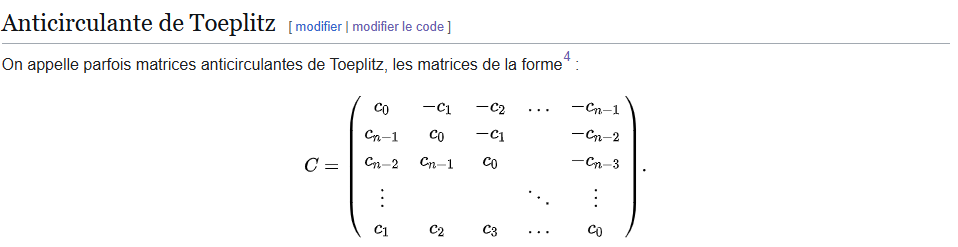
(source : https://fr.wikipedia.org/wiki/Matrices_anticirculantes).

Les matrices anticirculantes sont diagonalisables. 
Si nous posons :
$$ Q = 
\begin{pmatrix}
0 & 0 & 0 & \cdots  & 0 & -1 \\
1 & 0 & 0 & \cdots  & 0 & 0 \\
0 & 1 & 0 & \cdots  & 0 & 0 \\
\vdots & \vdots & \ddots & \vdots  & \vdots & \vdots \\
0 & 0 & 0 & 1  & 0 & 0 \\
0 & 0 & 0 & \cdots  & 1 & 0 \\
\end{pmatrix}
$$
alors nous pouvons écrire $T$ come 
$$ \begin{array}{cc}
T = b_0I + b_1Q + b_2Q^2 + \dots + b_{n-1}Q^{n-1} \\
T = f(Q)
\end{array}
$$
(source : https://arxiv.org/pdf/1908.07154)
Si $Q$ est diagonalisable alors : 
$$
\begin{array}{cc}
Q = MDM^{-1} \\
Q^2 = (MDM^{-1})(MDM^{-1}) = MD^2M^{-1} \\
Q^3 = (MDM^{-1})(MDM^{-1})(MDM^{-1}) = MD^3M^{-1} \\
\dots \\
Q^k = MD^kM^{-1} \\
\end{array}
$$
Nous pouvons en déduire : 
$$
\begin{array}{cc}
T = f(Q)= f(MDM^{-1}) \\
= b_0I + b_1(MDM^{-1}) + b_2(MDM^{-1})^2 + \dots + b_{n-1}(MDM^{-1})^{n-1} \\
= b_0I + b_1(MDM^{-1}) + b_2(MD^2M^{-1}) + \dots + b_{n-1}(MD^{n-1}M^{-1}) \\
= M(b_0I + b_1D + b_2D^2+\dots+b_{n-1}D^{n-1})M^{-1} \\
= Mf(D)M^{-1}
\end{array}
$$
$Q$ est diagonalisable si $det(Q - \lambda I) = 0$. 
On remarque que $Q^N = -I$ donc $Q^N + I = 0$. De cette façon on a $(Q^N + I)v = 0$ pour tout $v$. Donc le polynôme annulateur de $Q$ est $p(X) = X^N +1$. 
Ce polynôme est un polynôme cyclonomique. Sur $\mathbb{C}$ il se factorise en $X^N + 1 = \prod_{k=0}^{N-1}(X - \lambda_k)$ avec $\lambda_k = e^{(2k + 1) \pi i/N}$, les racines toutes distinctes. Comme le polynôme annulateur est scindé et uniquement composé de racines distinctes, alors $Q$ est diagonalisable. 
Nous pouvons maintenant chercher les valeurs propres et vecteurs propres de $Q$. 
$$
\begin{array}{cc}
Qv = \lambda v \\
Q^Nv=  \lambda^Nv \\
\text{Comme } Q^Nv = -v \\
-v = \lambda^N v \\
\lambda^N = -1
\end{array}
$$
Donc les valeurs propres $\lambda_k$ sont exactement les $\lambda_k = e^{(2k + 1) \pi i/N}$. 
On sait que $Qv = \lambda v$ et que $Q$ consiste à cycler vers la gauche les éléments de $v$, i.e : 
$$
Q(v_0, v_1, v_2, \dots, v_{n-1}) = (-v_{n-1}, v_0, v_1, \dots, v_{n-2})
$$
Donc si nous regardons éléments par éléments l'égalité $Qv = \lambda v$ nous avons 
$$ \begin{array}{cc}
-v_{n-1} = \lambda v_0 \\
v_0 = \lambda v_1 \\
v_1 = \lambda v_2 \\
\vdots \\
v_{n-2} = \lambda v_{n-1}
\end{array}
$$
Nous pouvons remonter : 
$$
\begin{array}{cc}
v_{n-2} = \lambda v_{n-1} = \lambda(-(\lambda v_0)) = -\lambda^2v_0 \\
v_{n-3} = \lambda v_{n-2} = \lambda(-\lambda^2v_0) = -\lambda^3v_0 \\
v_{n-4} = \lambda(-\lambda^3v_0) = -\lambda^4v_0 \\ 
\vdots \\
v_0 = - \lambda^{n}v_0
\end{array}
$$
On a donc la relation $v_k = -\lambda^{n-k}v_0$. Comme $v_0 = - \lambda^{n}v_0$ alors $\lambda^n = -1$ donc : 
$$
\begin{array}{cc}
v_k = -\lambda^{n-k}v_0 \\
v_k = -(\lambda^n \cdot \lambda^{-k})v_0 \\
v_k = -(-1 \cdot \lambda^{-k})v_0 \\
v_k = \lambda^{-k}v_0 \\
\text{En posant }\mu = \lambda^{-1} \\
v_k = \mu^kv_0 \\
\text{Comme nous avions }\lambda^n = -1 \\
\mu^n = \lambda^{-n} = -1^{-n} = - 1
\end{array}
$$
Nous avons donc le vecteur propre 
$$
\begin{array}{cc}
v^{<k>} = (v_0, v_1, v_2, \dots, v_{n-1}) \\
= (\mu^{0}v_0, \mu^{1}v_0, \mu^{2}v_0, \dots, \mu^{(n-1)}v_0) \\
= v_0(1, \mu^{1},\mu^{2}, \dots, \mu^{(n-1)}) \\
\end{array}
$$
associé à la valeur  $\mu^{k} = e^{(2k + 1) \pi i/N}$ avec $0 \leq k < N$.
$$
\begin{array}{cc}
Q = MDM^{-1} \\
Q = 
\begin{pmatrix}
v^{<0>} & v^{<1>} & v^{<2>} & \dots & v^{<n-2>} & v^{<n-1>}
\end{pmatrix}
\cdot 
\begin{pmatrix}
\lambda^{<0>} & 0 & 0 & \dots & 0 & 0 \\
0 & \lambda^{<1>} &  0 & \dots & 0 & 0 \\
0 & 0 & \lambda^{<2>} & \dots & 0 & 0 \\
\vdots & \vdots & & \ddots & 0 & 0 \\
0 & 0 & 0 & \dots & \lambda^{<n-2>} & 0 \\
0 & 0 & 0 & \dots & 0 & \lambda^{<n-1>} \\
\end{pmatrix} 
\cdot 
\begin{pmatrix}
v^{<0>} & v^{<1>} & v^{<2>} & \dots & v^{<n-2>} & v^{<n-1>}
\end{pmatrix} ^{-1} \\
= 
\begin{pmatrix}
1 & 1 & 1 & \dots & 1 & 1 \\
\mu^{<0>^{1}} & \mu^{<1>^{1}} & \mu^{<2>^{1}} & \dots & \mu^{<n-2>^{1}}  & \mu^{<n-1>^{1}} \\
\mu^{<0>^{2}} & \mu^{<1>^{2}} & \mu^{<2>^{2}} & \dots & \mu^{<n-2>^{2}}  & \mu^{<n-1>^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\mu^{<0>^{n-1}} & \mu^{<1>^{n-1}} & \mu^{<2>^{n-1}} & \dots & \mu^{<n-2>^{n-1}}  & \mu^{<n-1>^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
\lambda^{<0>} & 0 & 0 & \dots & 0 & 0 \\
0 & \lambda^{<1>} &  0 & \dots & 0 & 0 \\
0 & 0 & \lambda^{<2>} & \dots & 0 & 0 \\
\vdots & \vdots & & \ddots & 0 & 0 \\
0 & 0 & 0 & \dots & \lambda^{<n-2>} & 0 \\
0 & 0 & 0 & \dots & 0 & \lambda^{<n-1>} \\
\end{pmatrix} 
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \dots & 1 & 1 \\
\mu^{<0>^{1}} & \mu^{<1>^{1}} & \mu^{<2>^{1}} & \dots & \mu^{<n-2>^{1}}  & \mu^{<n-1>^{1}} \\
\mu^{<0>^{2}} & \mu^{<1>^{2}} & \mu^{<2>^{2}} & \dots & \mu^{<n-2>^{2}}  & \mu^{<n-1>^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
\mu^{<0>^{n-1}} & \mu^{<1>^{n-1}} & \mu^{<2>^{n-1}} & \dots & \mu^{<n-2>^{n-1}}  & \mu^{<n-1>^{n-1}} \\
\end{pmatrix}^{-1} \\
= 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
\omega & 0 & 0 & \cdots & 0 & 0 \\
0 & \omega^3 & 0 & \cdots & 0 & 0 \\
0 & 0 & \omega^5 & \cdots & 0 & 0 \\
\vdots & \vdots & & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & \omega^{2n-3} & 0 \\
0 & 0 & 0 & \cdots & 0 & \omega^{2n-1}
\end{pmatrix}
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1}
\end{array}
$$
Comme nous avons les valeurs propres $\lambda^{<k>}$, nous pourrons simplement faire $T = f(Q) = Mf(D)M^{-1}$ en appliquant $f(\cdot)$ au $\lambda^{<k>}$. Ainsi, nous avons : 
$$
\begin{array}{cc}
T = Mf(D)M^{-1} \\ 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}
\cdot 
\begin{pmatrix}
f(\omega) & 0 & 0 & \cdots & 0 & 0 \\
0 & f(\omega^3) & 0 & \cdots & 0 & 0 \\
0 & 0 & f(\omega^5) & \cdots & 0 & 0 \\
\vdots & \vdots & & \ddots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & f(\omega^{2n-3}) & 0 \\
0 & 0 & 0 & \cdots & 0 & f(\omega^{2n-1})
\end{pmatrix}
\cdot 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1} \\
\end{array}
$$
et donc la multiplication entre deux polynômes peut être faites de la façon suivante : 
$$
\begin{array}{cc}
A(X) \cdot B(X) = \sum_{i=0}^{n-1} \sum_{j=0}^{n-1} a_i b_j X^{i +j} \\
= Ta =Mf(D)M^{-1}a
\end{array}
$$
L'opération s'effectue toujours en complexité $\mathcal{O}(n^2)$ parce que la transformation $M^{-1}$ et $M$ ont une complexité naïve de $\mathcal{O}(n^2)$ donc on a $\mathcal{O}(n^2) + \mathcal{O}(n) + \mathcal{O}(n^2) = \mathcal{O}(n^2)$. L'opération $M$ est en fait une transformation de Fourrier. Par conséquent, elle peut être transformé en Fast Fourrier Transformation (FFT), qui s'effectue en complexité $\mathcal{O}(n \ log \ n)$. Ainsi, on opère la multiplication polynomiale en $\mathcal{O}(n \ log \ n) + \mathcal{O}(n) + \mathcal{O}(n \ log \ n) = \mathcal{O}(n \ log \ n) < \mathcal{O}(n^2)$.  







# Démonstration de l'encodage/décodage de messages 

Voici un exemple jouet d'encodage et de décodage d'un message. 

### Input

Comme vu précédemment, en entrée, nous prenons un vecteur de complexe de taille $N/2$, avec $N$ une puissance de 2. 

In [1]:
import numpy as np 

power_of_two  = 2
n = 2**power_of_two

# y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y = np.array([1.1 +4.3j, 3.5 - 1.4j])

print(y)

[1.1+4.3j 3.5-1.4j]


### Encodage, 1e étape : Construction de $y'$

Puis nous construisons $y' = (y| \text{ reverse order}(\overline{y}))$. 

In [2]:
y_and_conj = np.concatenate((y, y.conjugate()[::-1]), axis=0)
y_and_conj

array([1.1+4.3j, 3.5-1.4j, 3.5+1.4j, 1.1-4.3j])

### Encodage, 2e étape : Passage en polynôme cyclotomique à coefficient réels

Nous avons défini $V$, l'isomoprhisme d'anneau $\mathbf{R}[X]/X^N +1 \to \hat{\mathbb{C}^N}$ tel que : 
$V\cdot c = y$. Comme nous partons des complexes et nous voulons obtenir les coefficients du polynômes qui sert d'encodage à notre message, nous cherchons 
$$
\begin{array}{cc}
V^{-1}y = c \\ 
\frac{V^T \cdot I^R_N}{N} \cdot y = c
\end{array}
$$

Pour rappel : 
$$
\begin{array}{cc}
\omega = e^{k \pi i/n} \\ \\
V = 
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix} \\ \\
V^T = 
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 \\
\omega & \omega^3 & \omega^5 & \cdots & \omega^{2n-1} \\
(\omega)^2 & (\omega^3)^2 & (\omega^5)^2 & \cdots & (\omega^{2n-1})^2 \\
\vdots & & \ddots & & \vdots \\
(\omega)^{n-1} & (\omega^3)^{n-1} & (\omega^5)^{n-1} & \cdots & (\omega^{2n-1})^{n-1}
\end{pmatrix} \\ \\ 
I^R_N =  
\begin{pmatrix}
0 & \cdots & 0 & 0 & 1 \\
0 & \cdots & 0 & 1 & 0 \\
0 & \cdots & 1 & 0 & 0 \\
\vdots & & \ddots & & \vdots \\
1 & \cdots & 0 & 0 & 0 \\
\end{pmatrix}
\end{array}
$$

In [3]:
V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
w = np.exp(1j * np.pi / n)
for ligne in range(1, n+1, 1):
    for col in range(n): 
        V[ligne-1,col] = (w**(2*ligne -1))**(col)

np.set_printoptions(linewidth=300)
print(V, V.T, sep="\n\n\n")

[[ 1.        +0.j          0.70710678+0.70710678j  0.        +1.j         -0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678+0.70710678j  0.        -1.j          0.70710678+0.70710678j]
 [ 1.        +0.j         -0.70710678-0.70710678j  0.        +1.j          0.70710678-0.70710678j]
 [ 1.        +0.j          0.70710678-0.70710678j  0.        -1.j         -0.70710678-0.70710678j]]


[[ 1.        +0.j          1.        +0.j          1.        +0.j          1.        +0.j        ]
 [ 0.70710678+0.70710678j -0.70710678+0.70710678j -0.70710678-0.70710678j  0.70710678-0.70710678j]
 [ 0.        +1.j          0.        -1.j          0.        +1.j          0.        -1.j        ]
 [-0.70710678+0.70710678j  0.70710678+0.70710678j  0.70710678-0.70710678j -0.70710678-0.70710678j]]


In [4]:
reversal_matrix = np.zeros(shape=(n, n))
for i in range(n): 
    reversal_matrix[i,n-1-i] = 1
reversal_matrix

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 1., 0., 0.],
       [1., 0., 0., 0.]])

In [5]:
# Exemple de transformation via la reversal matrix 
exemple_matrix = np.array(([1, 2, 3, 4], [5, 6, 7, 8],  [9, 10, 11, 12], [13, 14, 15, 16]))
print(
    exemple_matrix, exemple_matrix @ reversal_matrix, reversal_matrix @ exemple_matrix, sep="\n\n"
)

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]]

[[ 4.  3.  2.  1.]
 [ 8.  7.  6.  5.]
 [12. 11. 10.  9.]
 [16. 15. 14. 13.]]

[[13. 14. 15. 16.]
 [ 9. 10. 11. 12.]
 [ 5.  6.  7.  8.]
 [ 1.  2.  3.  4.]]


In [6]:
v_encoded_as_pol = (V.T @ reversal_matrix)/n @ y_and_conj
v_encoded_as_pol

array([2.3       +0.00000000e+00j, 0.1767767 +2.22044605e-16j, 2.85      +2.22044605e-16j, 1.87383297-2.44249065e-15j])

A cause de la précision de calcul de la machine, la partie imaginaire ne disparaît pas totalement

In [7]:
print(np.max(np.abs(v_encoded_as_pol.imag)))
print(np.mean(np.abs(v_encoded_as_pol.imag)))

2.4424906541753444e-15
7.216449660063518e-16


Je construit une fonction qui pourra être appelé pour vérifier si les parties imaginaire ne sont jamais suffisamment grandes pour être considérées autrement qu'une erreur de précision. 

In [8]:
def check_ckks_imag(v_encoded_as_pol, tol=1e-10):
    imag = np.array([z.imag for z in v_encoded_as_pol])
    real = np.array([z.real for z in v_encoded_as_pol])

    bad = np.where(np.abs(imag) > tol)[0]

    if len(bad) > 0:
        msg = ["Imaginary parts continue to be part of the encoded message"]

        for i in bad:
            msg.append(
                f"Index {i}: {real[i]} + {imag[i]}j (|imag|={abs(imag[i])})"
            )

        raise ValueError("\n".join(msg))

    return real

La tolérance a $1.00000000e-10 \approx 0$. est un choix arbitraire. Tant qu'aucune partie imaginaire n'es tplus grande que ce seuil, nous pouvons décider de ne garder que la partie réel. 

In [9]:
v_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=v_encoded_as_pol)

### Encodage, 3e étape : Passage en polynôme cyclotomique à coefficient entiers

Maintenant, nous allons convertir notre polynôme à coefficient réel en polynôme à coefficient entier en arrondissant les valeurs après les avoir multipliées par le fecteur $\Delta$. Le choix de $\Delta$ doit aussi se faire selon le modulo $t$ choisit.

In [10]:
Delta = 100
v__int_encoded_as_pol_appr = np.round(Delta * v_encoded_as_pol_appr, 0)
v__int_encoded_as_pol_appr

array([230.,  18., 285., 187.])

Comme vous pouvez le voir, plus la valeur de $\Delta$ sera grande, plus la précision gardée lors de l'arrondi sera importante. Il faut garder en tête qu'il quasiment impossible de garder une précision parfaite en utilisant CKKS, car nous avons une approximation lors de l'encodage en polynôme à cause de la précision limitée des machines, une nouvelle approximation au moment de l'arrondi et nous aurons aussi de l'ajout de bruit lors du chiffrement/déchiffrement et des opérations. 

### Décodage : Retour aux vecteurs complexes

Notre message est bien encodé. Nous pouvons travailler dans l'espace sur lequel nous allons chiffrer, faire les opérations et déchiffrer. 
Pour le moment, nous pouvons déjà vérifier que le décodage fonctionne correctement en réalisant l'inverse de l'encodage : 
$$ 
\begin{array}{cc}
Enc(y) = \lfloor \Delta (\frac{V^T \cdot I^R_N}{n} \cdot y') \rceil = \tilde{c} \\ \\
Dec((Enc(y))) = V \cdot \frac{1}{\Delta}\tilde{c}
\end{array}
$$

In [11]:
y_estimated = V @ (1/Delta * v__int_encoded_as_pol_appr)
y_estimated

array([1.10498954+4.2995689j, 3.49501046-1.4004311j, 3.49501046+1.4004311j, 1.10498954-4.2995689j])

Le vecteur obtenu correspond à $V \cdot c = (y | \text{reverse order}(\overline{y}))$. Pour récupérer seulement $y$, il faut prendre uniquement la première moitié du résultat. 

In [12]:
print(y, y_estimated, y_estimated[0:(n//2)], sep="\n")

[1.1+4.3j 3.5-1.4j]
[1.10498954+4.2995689j 3.49501046-1.4004311j 3.49501046+1.4004311j 1.10498954-4.2995689j]
[1.10498954+4.2995689j 3.49501046-1.4004311j]


### Wrapping up 

Maintenant que la démonstration est faite, je vais construire les fonctions qui permettront d'encoder et decoder facilement nos messages. 

In [13]:
def CKKS_Encoding(m, Delta, q=None): 
    n_div_2 = len(m)
    if (n_div_2 & (n_div_2 - 1)) != 0 : 
        n_div_2 = 1 << (n_div_2 - 1).bit_length()
        m = np.concatenate((m, np.zeros(n_div_2 - len(m))), axis=0)
    m_and_conj = np.concatenate((m, m.conjugate()[::-1]), axis=0)
    n = n_div_2*2
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    reversal_matrix = np.zeros(shape=(n, n))
    for i in range(n): 
        reversal_matrix[i,n-1-i] = 1
    m_encoded_as_pol = (V.T @ reversal_matrix)/n @ m_and_conj
    m_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=m_encoded_as_pol)
    # m_encoded_as_pol_appr = np.real_if_close(m_encoded_as_pol, tol=1_000)
    m_int_encoded_as_pol_appr = np.array(
        [int(round(Delta * x)) for x in m_encoded_as_pol_appr],
        dtype=object
    )
    m_int_encoded_as_pol_appr = np.array([int(x) for x in m_int_encoded_as_pol_appr], dtype=object)
    return m_int_encoded_as_pol_appr

In [14]:
CKKS_Encoding(m=y, Delta=Delta)

array([230, 18, 285, 187], dtype=object)

In [15]:
def CKKS_decoding(m_encoded, Delta):
    n = len(m_encoded)
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(1, n+1, 1):
        for col in range(n): 
            V[ligne-1,col] = (w**(2*ligne -1))**(col)
    y_estimated = V @ (1/Delta * m_encoded)
    return y_estimated[0:(n//2)]

In [16]:
CKKS_decoding(
    m_encoded= 2 * CKKS_Encoding(
        m = np.array([1, 2] * (n//2), dtype=object), 
        Delta=Delta
    ),Delta = Delta
)

array([(1.977485331071761-1.6653345369377348e-16j), (4.005218260790448+2.7755575615628914e-16j), (1.994781739209551-1.0547118733938987e-15j), (4.022514668928238+1.1379786002407855e-15j)], dtype=object)

In [17]:
CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta), Delta=Delta)

array([(1.1049895397947347+4.299568901432424j), (3.4950104602052665-1.4004310985675779j)], dtype=object)

De cette façon, nous pouvons simplement analyser l'impact sur la précision de la valeur de $\Delta$

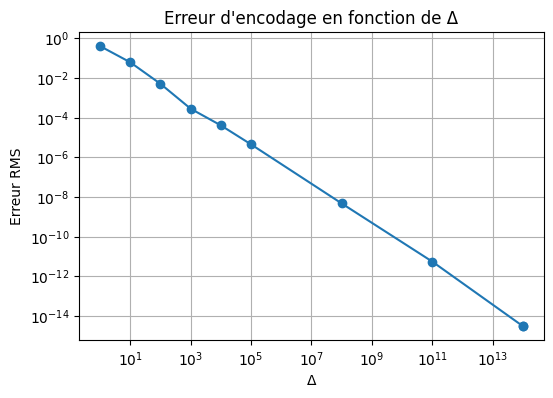

In [18]:
import matplotlib.pyplot as plt

Delta_values = [1, 10, 100, 1_000, 10_000, 100_000, 100_000_000, 100_000_000_000, 100_000_000_000_000, 100_000_000_000_000]

erreurs_rms = []

for Delta_value in Delta_values:
    result = CKKS_decoding(m_encoded=CKKS_Encoding(m=y, Delta=Delta_value), Delta=Delta_value)
    erreur = np.abs(y - result)

    erreurs_rms.append(
        np.sqrt(np.mean(erreur**2))
    )

plt.figure(figsize=(6,4))
plt.loglog(Delta_values, erreurs_rms, marker='o')
plt.xlabel("Δ")
plt.ylabel("Erreur RMS")
plt.title("Erreur d'encodage en fonction de Δ")
plt.grid(True, which="both")
plt.show()

Plus $\Delta$ est élevé, plus les erreurs se réduisent. Cependant, à cause de la précision des machines, lors les valeurs en entrées sont grandes, peu importe le facteur $\Delta$ choisit, nous ne serons pas capable de retrouver les valeurs de départ après encodage et décodage. 

Il faut garder en tête qu'il y a plusieurs facteurs qui impactent la précision de l'encodage/décodage : 
- Le facteur $\Delta$ qui indique combien de nombre après la virgule seront gardés après le rounding 
- Le nombre d'entrées $N$, car le rounding ajoute de l'erreur qui propage au décodage et est borné par $\frac{N}{2\Delta}$
- La précision des calculs effectuées par la machine. Plus $\Delta$ est grand, plus les erreurs machines seront insignificiantes. Plus $N$ est grand, plus les matrices d'embedding seront grandes et donc les erreurs machines pourront être importantes. 

Ainsi, il est clair que plus le facteur $\Delta$ est grand, plus le résultat sera exact et plus $N$ est grand et plus le résultat sera inexact. 

L'impact du choix de $N$ peut être étudier expérimentalement, mais il faut garder en tête que des erreurs de calculs par la machine peuvent être faits durant les opérations et donc rendre l'erreur causé par le facteur $N$ moins discernable. 

Nous allons donc comparer les valeurs après encodage/décodage lorsqu'un rounding est utilisé et lorsqu'il nest pas utilisé, en comparant des entrées en petit nombre et des entrées en grand nombres. 

N = 2, Delta = 10000, Borne = 0.0001 
Erreur exp décodée : 3.865226518591953e-05
Erreur worst case décodée : 7.071067811865475e-05
Erreur machine : 2.220446049250313e-16

N = 16, Delta = 10000, Borne = 0.0008 
Erreur exp décodée : 0.0002500424576495221
Erreur worst case décodée : 0.0005101148618689163
Erreur machine : 1.6806591203325517e-14

N = 64, Delta = 10000, Borne = 0.0032 
Erreur exp décodée : 0.0011560450293674218
Erreur worst case décodée : 0.002037387816723145
Erreur machine : 3.133602471098452e-13

N = 256, Delta = 10000, Borne = 0.0128 
Erreur exp décodée : 0.004366517142902384
Erreur worst case décodée : 0.008148784219222528
Erreur machine : 8.512221168923257e-12

N = 1024, Delta = 10000, Borne = 0.0512 
Erreur exp décodée : 0.016198778935019992
Erreur worst case décodée : 0.03259494512839722
Erreur machine : 1.0241780212799194e-10

N = 4096, Delta = 10000, Borne = 0.2048 
Erreur exp décodée : 0.06462611099430243
Erreur worst case décodée : 0.130379732576676
Erreur machine

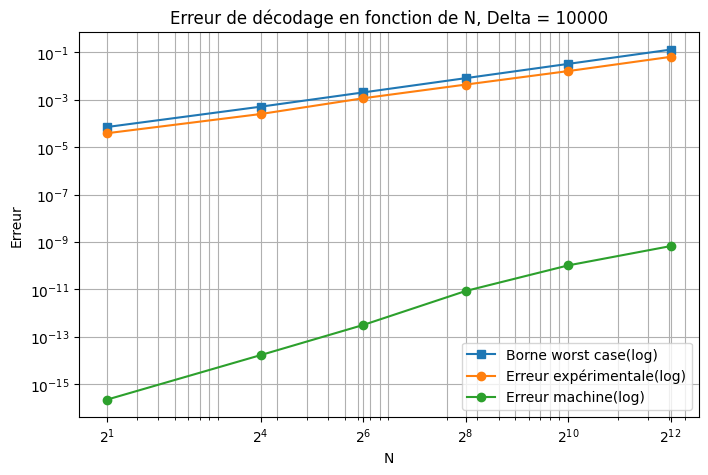

In [19]:
import matplotlib.pyplot as plt

Delta_values = [10_000]
n_values = [2**1, 2**4, 2**6, 2**8, 2**10, 2**12]

exp_errors = []
worst_errors = []
worst_errors_refined = []
computing_errors = []
for n in n_values : 
    for i, Delta_value in enumerate(Delta_values):
        y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
        #Calcul par étape pour isoler le rounding, en ayant exactement les mêmes matrices V utilisées dans les deux (réductions de l'impact de la précision machine) 
        y_and_conj = np.concatenate((y, y.conjugate()[::-1]), axis=0)
        reversal_matrix = np.zeros(shape=(n, n))
        for i in range(n): 
            reversal_matrix[i,n-1-i] = 1
        V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
        w = np.exp(1j * np.pi / n)
        for ligne in range(1, n+1, 1):
            for col in range(n): 
                V[ligne-1,col] = (w**(2*ligne -1))**(col)
        v_encoded_as_pol = (V.T @ reversal_matrix)/n @ y_and_conj
        v_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=v_encoded_as_pol)

        #Encoding : Without rounding, so without rounding error
        v__int_encoded_as_pol_appr = (Delta_value * v_encoded_as_pol_appr)
        #Encoding : With rounding error
        v__int_encoded_as_pol_appr_rounded = np.round(v__int_encoded_as_pol_appr, 0)

        rounding_error_exp_case = np.abs(v__int_encoded_as_pol_appr - v__int_encoded_as_pol_appr_rounded)
        rounding_error_worst_case = np.ones(n) * 0.5

        # Avoir la même matrice de décodage pour les deux cas pour limiter l'impact des imprécisions machines 
        decoded_values = (V @ (v__int_encoded_as_pol_appr * 1/Delta_value))[0:(n//2)]
        decoding_errors = np.linalg.norm(y - decoded_values, ord=np.inf)
        decoding_errors_exp_case = np.linalg.norm((V @ rounding_error_exp_case * 1/Delta_value )[0:(n//2)], ord=np.inf)
        rounding_error_worst_case = np.linalg.norm((V @ rounding_error_worst_case * 1/Delta_value )[0:(n//2)], ord=np.inf)
        exp_errors.append(decoding_errors_exp_case)
        worst_errors.append(rounding_error_worst_case)
        
        print(f"N = {n}, Delta = {Delta_value}, Borne = {n/(2*Delta_value)} \n"
            f"Erreur exp décodée : {decoding_errors_exp_case}\n"
            f"Erreur worst case décodée : {rounding_error_worst_case}\n"
            f"Erreur machine : {decoding_errors}\n"

            )
    
    computing_errors.append([decoding_errors])
    


plt.figure(figsize=(8,5))
worst_errors_refined
plt.loglog(n_values, worst_errors, marker='s', label="Borne worst case(log)")
plt.loglog(n_values, exp_errors, marker='o', label="Erreur expérimentale(log)")
plt.loglog(n_values, computing_errors, marker='o', label="Erreur machine(log)")

plt.xlabel("N")
plt.ylabel("Erreur")
plt.title(f"Erreur de décodage en fonction de N, Delta = {Delta_values[0]}")

plt.xticks(
    n_values,
    [f"$2^{{{int(np.log2(n))}}}$" for n in n_values]
)

plt.grid(True, which="both")
plt.legend()

plt.show()

n = 2**power_of_two

Il reste difficile d'écarter complètement l'impact des erreurs de précisions machines, mais nous pouvons tout de même voir l'impact de la taille de l'échantillon sur les erreurs de décodages. Une remarque intéressante est que si $N = 2^4$ alors nous avons une précision d'au moins 3 chiffres après la virgule avec $\Delta = 10000$. En gardant cette valeur de $\Delta$ mais en passantr à $N = 2^{12}$, je n'ai plus qu'une précision de 0 chiffre après la vrigule, donc une précision sur les entiers. Enfin, la seule valeur de $N$ pour laquelle l'heuristique $log_10(\Delta)$ nous donne la précision de l'encodage/décodage, ce qui est logique, vu que notre borne gorssière est $\frac{N}{2\Delta}$, avec $N = 2$ nous avons $\frac{2}{2\Delta} = \Delta$. 

# Chiffrement homomorphe 


Maintenant que nous pouvons encoder et décoder nos messages, nous allons les chiffrer pour en sécuriser le contenu. Le schéma homomorphe sur lequel repose CKKS est le suivant : 
$$\begin{array}{cc}
Encr(\Delta m_i) = - A_i \times S + \Delta m_i +e_i \\
A_i, S, e_i \in \mathbf{Z}_q[X]/X^N+1 \\
\end{array}
$$
sachant que $A_i$ est public, $S$ est un polynôme à coefficient choisit parmi l'ensemble $\{-1, 0, 1\}$ constituant la clé privée de l'utilisateur et $e_i$ un polynôme à petits coefficients tiré via une gaussienne. La sécurité de ce schéma est basé sur RLWE. Il est facile pour une personne de déchiffrer un message en connaissant $Encr(m_i), A_i, S$ : 
$$
Decr(Encr(\Delta m_i)) = Decr(-A_iS + (\Delta m_i + e_i)) = A_iS - A_iS + (\Delta m_i + e_i) = \Delta m_i + e_i = m_i + \frac{e_i}{\Delta}
$$
Ainsi, le chiffrement puis déchiffrement d'un message encodé renvoi bien le message initial avec un petit bruit en plus. Ce bruit est si petit qu'il est considéré négligeable et donc $m_i + \frac{e_i}{\Delta} \approx m_i$. Ainsi : 
$$
m_i \approx Decr(Encr(\Delta m_i))
$$
C'est donc un schéma de chiffrement approximatif car le résultat après chiffrement et déchiffrement est une approximation du message de départ. L'approximation est considéré si proche du message initial qu'il est utilisable au même titre que le véritable message. Il existe des schémas de chiffrement exact. Nous acceptons la contrainte de l'approximation car elle nous permet d'effectuer efficacement des opérations sur des réels. 

## Chiffrement 

Dans la pratique, le chiffrement d'un message se déroule de la façon suivante : 
$$\begin{array}{cc}
Encr(\Delta m_i) = (A_i,B_i) \\
B_i = -A_iS + \Delta m_i + e_i
\end{array}$$
La paire $(A_i, B_i)$ est l'ensemble du chiffrement qui est envoyé à la partie souhaitant effectuer des opérations sur le message. L'idée est que $A_i$ est indiscernable de $B_i$. Ainsi, une personne qui obtiens ce couple n'est pas capable de reconstruire $m_i$ sans la connaissance de $S$. La partie qui reçoit le message peut ensuite effectuer les opérations directement sur les messages chiffrés. 

In [20]:
def poly_mutl_mod(v1, v2, q, with_modulus=True):
    v1 = np.array(v1, dtype=object)
    v2 = np.array(v2, dtype=object)
    n = len(v1)
    result = [0] * n
    for i in range(n): 
        for j in range(n): 
            coef = (v1[i] * v2[j])
            if (i + j >= n) : 
                result[(i+j) - n] -= coef
            else : 
                result[i+j] += coef

    if with_modulus : 
        for k in range(n) : 
            result[k] = result[k] % q
    
    return np.array(result, dtype=object)

In [21]:
def modulus_centering(x, q):
    return ((x + q//2) % q) - q//2

In [22]:
def mod_for_arb_int(x, q): 
    return np.array([int(v) % q for v in x], dtype=object)

In [23]:
def round_for_arb_int(x): 
    return np.array([int(round(v)) for v in x], dtype=object)

In [24]:
# Création d'un message
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage d'un message
m_i = CKKS_Encoding(m=y_i, Delta=Delta)

B_m = int(np.max(np.abs(m_i)))
B_e = int(np.round(6*(8/np.sqrt(2*np.pi)), 0))    # borne gaussienne grossière

q = int((10*(B_m + B_e))*(Delta**(2)))

In [25]:
# Sampling du masque publique A, un polynôme de degré n-1, modulo Q
rng = np.random.default_rng(12345)  # générateur moderne

In [26]:
# Sampling de la clé privée (évidemment ici la création de la clé n'est pas sécurisé)
S = mod_for_arb_int(np.array(
    [int(x) for x in np.random.randint(-1, 2, size=n)],
    dtype=object
), q)

In [27]:
import random 

A = np.array(
    [random.randrange(0, q) for _ in range(n)],
    dtype=object
)

# Sampling du bruit utilisé pour cacher le message, c'est un petit polynôme de degré n-1
E = np.array(
    [int(x) for x in np.round(rng.normal(loc=0, scale=8/np.sqrt(2*np.pi), size=n))], dtype=object
)

# Construction du chiffrement du message 
B = mod_for_arb_int((poly_mutl_mod(-A, S, q)  + m_i + E), q)

# Construction de la paire (A,B) supposé indiscernable 
Encr_m_i = np.array([A, B])

print("Masque public A", np.polynomial.polynomial.Polynomial((modulus_centering(A, q))), sep="\n")
print()
print("Clé privée S", np.polynomial.polynomial.Polynomial(modulus_centering(S, q)), sep="\n")
print()
print("Bruit pour cacher le message", np.polynomial.polynomial.Polynomial(modulus_centering(E, q)), sep="\n")
print()
print("Paire envoyé au serveur : ", Encr_m_i, sep="\n")
print()
print("Partie A : ", np.polynomial.polynomial.Polynomial(A), sep="\n")
print()
print("Partie B : ", np.polynomial.polynomial.Polynomial(B), sep="\n")

Masque public A
-9581330 - 4916632 x + 2476096 x**2 + 2664880 x**3

Clé privée S
-1 + 1 x + 0 x**2 + 0 x**3

Bruit pour cacher le message
-5 + 4 x - 3 x**2 - 1 x**3

Paire envoyé au serveur : 
[[14518670 19183368 2476096 2664880]
 [17183452 4664571 7392775 188561]]

Partie A : 
14518670 + 19183368 x + 2476096 x**2 + 2664880 x**3

Partie B : 
17183452 + 4664571 x + 7392775 x**2 + 188561 x**3


## Déchiffrement 

Le déchiffrement du message s'effectue comme suit : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) = Decr(A_i, B_i) \\
= Decr(A_i, -A_iS + (\Delta m_i + e_i)) \\ 
= A_iS - A_iS + (\Delta m_i + e_i) = \Delta m_i + e_i = m_i + \frac{e_i}{\Delta}
\end{array}
$$

In [28]:
Decr_m_i = round_for_arb_int((mod_for_arb_int((B + poly_mutl_mod(A, S, q)), q)) * Delta) // Delta
print(Decr_m_i, (m_i) % q, sep="\n")

[24099902 24099873 47 24099777]
[24099907 24099869 50 24099778]


Nous pouvons comparer la différence de valeur entre le message avant chiffrement et après pour faire apparaître le bruit qui lui est ajouté. 

In [29]:
import matplotlib.pyplot as plt 

def Show_encryption_impact(m, m_encr_decr, q, in_percent=False):

    m_c = modulus_centering(m, q)
    m_dec_c = modulus_centering(m_encr_decr, q)

    impact = np.abs(m_c - m_dec_c)

    if in_percent:
        impact = impact * 100 / (np.abs(m_c) + 1e-6)

    max_noise = np.max(impact)
    print("max noise:", max_noise)

    plt.figure(figsize=(8,5))
    bins = np.linspace(0, max_noise, 10)

    plt.hist(impact, bins=bins)

    plt.xlabel("Erreur (centrée modulo q)")
    plt.ylabel("Fréquence")
    plt.title("Histogramme du bruit")
    plt.grid(True, alpha=0.3)
    plt.show()

max noise: 5.9999998800000025


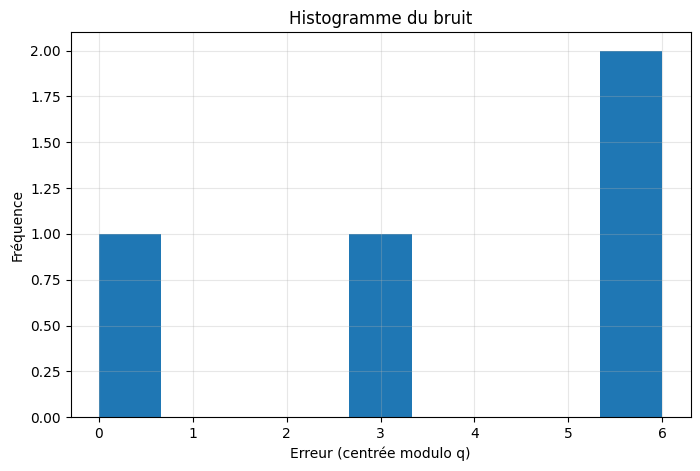

In [30]:
Show_encryption_impact(m=m_i % q, m_encr_decr=Decr_m_i, q=q, in_percent=True)

Nous retrouvons bien le bruit gaussien centré en $0$. Nous pouvons wrap-up les opérations dans des fonctions pour plus de lisibilité. 

In [31]:
def CKKS_Encryption(m_encoded, q, S): 
    n = len(m_encoded)
    # rng = np.random.default_rng()  # générateur moderne
    A = np.array(
    [random.randrange(0, q) for _ in range(n)],
    dtype=object
    )
    E = np.array(
    [int(x) for x in np.round(rng.normal(loc=0, scale=8/np.sqrt(2*np.pi), size=n))], dtype=object
    )
    # E = np.zeros(n, dtype=object)
    B = mod_for_arb_int((poly_mutl_mod(-A, S, q)  + m_encoded + E), q)
    Encr_m = np.array([A, B])
    return Encr_m

In [32]:
def CKKS_Decryption(Encr_m, S, Delta, q): 
    A = Encr_m[0]
    B = Encr_m[1]
    Decr_m = round_for_arb_int((mod_for_arb_int((B + poly_mutl_mod(A, S, q)), q)) * Delta) // Delta
    return Decr_m

In [33]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

[24099905 24099931 24099899 24099789]
[24099907 24099928 24099900 24099789]
max noise: 3


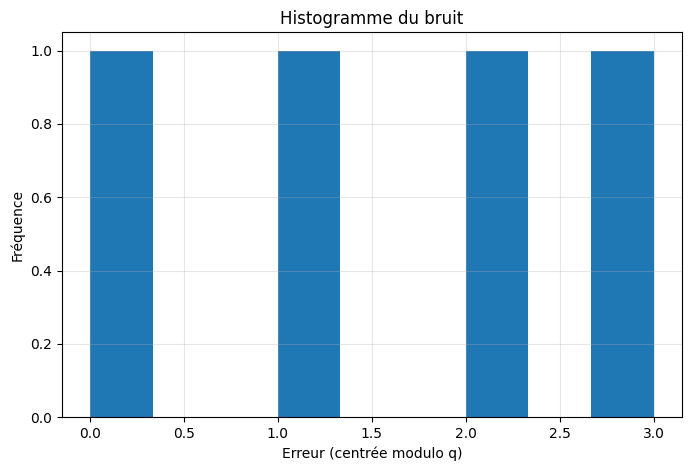

In [34]:
m_encr_decr = CKKS_Decryption(
    CKKS_Encryption(
        m_encoded=m_i, q = q, S=S
        ), S=S, Delta=Delta, q=q
    )

print(m_encr_decr, (m_i) % q, sep="\n")

Show_encryption_impact(m=m_i, m_encr_decr=m_encr_decr, q=q)

Le but de CKKS est de chiffrer un message, puis d'effecteur un certain nombre d'opérations avec ce message chiffré puis de déchiffrer le résultat. En théorie, il n'y a pas plusieurs fois le chiffrement et le déchiffrement d'un même message, donc le bruit ne va pas s'accumuler par ce biais là. Nous pouvons considérer que chiffrer et déchiffrer sera toujours safe de ce point de vue là, c'est à dire que nous aurons toujours un approximation assez fidèle du message original. 

# Addition


L'addition de deux messages chiffrés est définie en additionnant chaque partie du couple chiffré : 
$$
\begin{array}{cc}
Encr(\Delta m_i) + Encr(\Delta m_j) = (A_i, B_i) + (A_j, B_j) \\
= (A_i + A_j, B_i + B_j) \\
= (A_i + A_j, (-A_iS + \Delta m_i + e_i) + (-A_jS + \Delta m_j + e_j)) \\
= (A_i + A_j, -S(A_i + A_j) + \Delta m_i + \Delta m_j + e_i + e_j) \\ 
\text{En possant} A_i + A_j = A_k, B_i + B_j = B_k \\
= (A_k, B_k)
\end{array}
$$

D'abord nous allons créer, encoder et chiffrer deux messages, à l'aide de notre clé privé et de bruit. 

In [35]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

Puis, nous additionons les messages chiffrés entre eux. 

In [36]:
Encr_m_i_add_m_j = np.array(
    [
    mod_for_arb_int(Encr_m_i[0] + Encr_m_j[0], q), 
    mod_for_arb_int(Encr_m_i[1] + Encr_m_j[1], q)
    ], dtype=object
)

Puis nous pouvons déchiffrer le message : 
$$
\begin{array}{cc}
Decr((A_k, B_k))
= B_k + S(A_i + A_j) \\
=(-S(A_i + A_j) + S(A_i + A_j) + \Delta m_i + \Delta m_j + e_i + e_j) \\
= \Delta m_i + \Delta m_j + e_i + e_j \\ 
= m_i + m_j + \frac{e_1 + e_2}{\Delta} \approx m_i + m_j
\end{array}
$$
Si nous comparons avec l'addition faites avant le chiffrement : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i + \Delta m_j)) = Decr(A, -AS + (\Delta m_i + \Delta mj_j + e)) \\
= AS - AS + (\Delta m_i + \Delta mj_j + e) \\
= (\Delta m_i + \Delta mj_j + e) \approx m_i + m_j + \frac{e}{\Delta}
\end{array}
$$
Comme $m_i + m_j + \frac{e_1 + e_2}{\Delta} \approx (\Delta m_i + \Delta mj_j + m_i + m_j + \frac{e}{\Delta})$ alors nous avons bien $Decr(Encr(\Delta m_i) + Encr(\Delta m_j) \approx Decr(Encr(\Delta m_i + \Delta m_j))$.


In [37]:
result_addition = CKKS_Decryption(
    Encr_m=Encr_m_i_add_m_j, S=S, Delta=Delta, q=q
    )

print((result_addition), ((m_i+m_j)), sep="\n")

[59 24099940 155 24099982]
[52 -55 150 -17]


max noise: 7


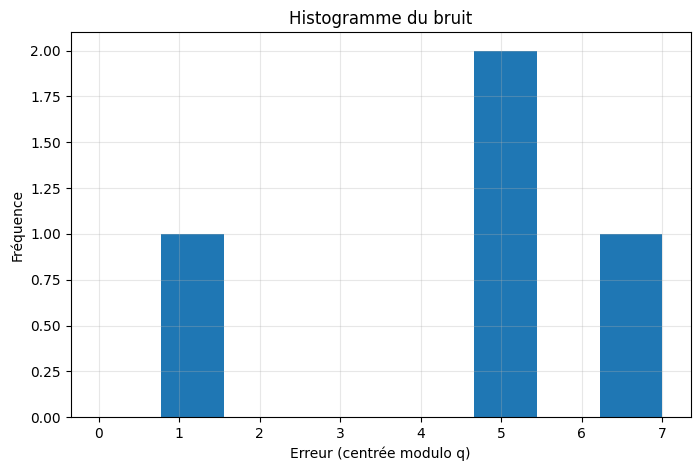

In [38]:
Show_encryption_impact(m=(m_i+m_j)% q, m_encr_decr=result_addition, q=q)

Le bruit ajouté lors d'une addition de deux messages chiffrés est $\frac{e_i + e_j}{\Delta}$. Comme les $e$ sont très petits, ce bruit est négligeable. 

L'addition entre un message chiffré et un message non chiffré est possible, et s'effectue de façon similaire : 
$$
\begin{array}{cc}
Encr(\Delta m_i) + \Delta m_j = (A_i, B_i) + \Delta m_j \\
= (A_i, -A_iS + \Delta m_i + e_i + \Delta m_j ) \\
= Encr(\Delta(m_i + m_j))
\end{array}
$$


In [39]:
# Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

In [40]:
# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)

In [41]:
Encr_m_i_add_m_j_plt = np.array(
    (
    Encr_m_i[0], 
    mod_for_arb_int(Encr_m_i[1] + m_j, q)
    )
)

Puis 
$$
\begin{array}{cc}
Decr((A_i, -A_iS + \Delta m_i + e_i + \Delta m_j)) \\
= A_iS - A_iS + \Delta m_i + \Delta m_j + e_i \\ 
= m_i + m_j + \frac{e_i}{\Delta} \approx m_i + m_j
\end{array}
$$
A nouveau $Decr(Encr(\Delta m_i)) + \Delta m_j) =\Delta m_i + e_i + \Delta m_j = m_i + m_j + \frac{e_i}{\Delta} = Decr(Encr(\Delta m_i) + \Delta m_j)$.

[24099914 24099798 24099746 24099849]
[24099915 24099797 24099750 24099849]
max noise: 4


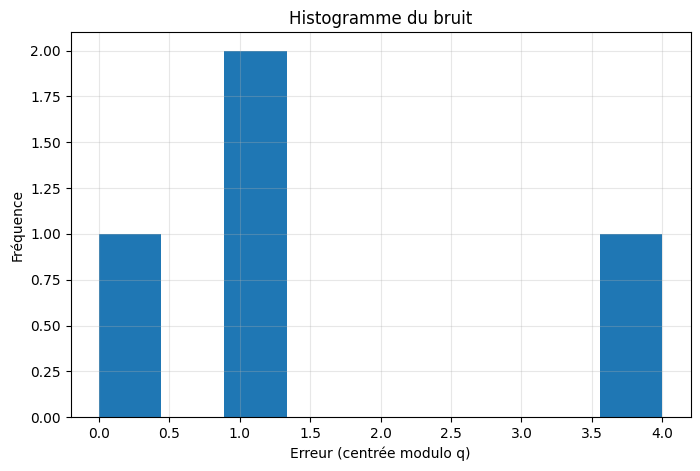

In [42]:
result_addition_plt = CKKS_Decryption(
    Encr_m=Encr_m_i_add_m_j_plt, S=S, Delta=Delta, q=q
    )

print(result_addition_plt, ((m_i+m_j) % q), sep="\n")

Show_encryption_impact(m=(m_i+m_j) % q, m_encr_decr=result_addition_plt, q=q)

Le bruit ajouté lors d'une addition d'un message chiffé avec un message non chiffré est $\frac{e_i}{\Delta}$. Il semble donc que l'addition d'un chiffré et d'un non chiffré soit moins approximative que dans le cas de l'addition de deux chiffrés mais il faut garder en tête que les $e$ sont très petits donc dans les deux cas le bruit ajouté est négligeable.

A la différence du chiffrement, il est possible que de nombreuses additions se suivent lors du traitement des messages. Par conséquent, le bruit va augmenter de $\frac{e_i + e_j}{\Delta} \times \text{|addition|}$. Le bruit étant très petit et le $\Delta$ choisit pouvant être très grand, il est possible de faire un grand nombre d'addition avant que le bruit ajouté soit trop important. Une façon de définir un budget d'opérations peut être de travailler modulo $q$. Ainsi, lorsque l'opération suivante entraînerait le dépassement du modulo, alors le résultat n'aura plus de lien avec le résultat souhaité, donc le budget d'opérations aurait été dépassé. Il convient donc de choisir le modulo en accord avec le nombre d'opérations que nous souhaitons faire mais aussi avec l'erreur de précision maximum que nous pouvons tolérer sur le résultat final. 

## Addition : Wrap-up 

In [43]:
def CKKS_addition_pltx(Encr_m_i, m_j, q):
    Encr_m_i_add_m_j_plt = np.array(
        (
        Encr_m_i[0], 
        mod_for_arb_int(Encr_m_i[1] + m_j, q)
        )
    ) 

    return Encr_m_i_add_m_j_plt

In [44]:
def CKKS_addition_ct(Encr_m_i, Encr_m_j, q): 
    Encr_m_i_add_m_j = np.array(
        [
        mod_for_arb_int(Encr_m_i[0] + Encr_m_j[0], q), 
        mod_for_arb_int(Encr_m_i[1] + Encr_m_j[1], q)
        ], dtype=object
    )

    return Encr_m_i_add_m_j

# Multiplication 

La multiplication de deux nombres chiffrés puis déchiffrés nous donne : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \\ 
(\Delta m_i + e_i)(\Delta m_j + e_j) \\
= \Delta^2 m_i m_j + \Delta(m_ie_j + m_je_i) + e_ie_j \\
\approx \Delta^2 m_i m_j
\end{array}
$$
SI nous nous concentrons sur les opérations de ciphertext nous avons : 
$$
\begin{array}{cc}
Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \\ 
= (B_i + A_iS)(B_j + A_jS) \\
= B_iB_j + B_iA_jS + B_jA_iS + S^2A_iA_j \\
=\underbrace{B_iB_j}_{D_0} + S\underbrace{(A_iB_j + A_jB_i)}_{D_1} + S^2\underbrace{(A_iA_j)}_{D_2}
\end{array}
$$

Pour avoir un résultat tel que $Decr(Encr(\Delta m_i)) \cdot Decr(Encr(\Delta m_j)) \approx Decr(Encr(\Delta m_i) ?Encr(\Delta m_j))$, nous avons besoin de produire à partir de $Encr(\Delta m_i)?Encr(\Delta m_j)$ les trois parties $D_0, D_1, D_2$, que nous viendront ensuite évalue en $S$ au moment du déchiffrement. Donc nous avons la multiplication de chiffrés suivante : 

$$\begin{array}{cc}
Encr(\Delta m_i)?Encr(\Delta m_j) \\
= (A_i, B_i)\otimes(A_j, B_j) \\
= (B_iB_j, A_iB_j + A_jB_i, A_iA_j) \\ 
= (D_0, D_1, D_2)
\end{array}
$$

Puis pour déchiffrer, nous pouvons simplement faire : 
$$
\begin{array}{cc}
Decr(D_0, D_1, D_2)= D_0 + D_1S + D_2S^2 \\ 
= \Delta ^2 m_i m_j + \Delta(m_ie_j + m_je_i + e_ie_j) \\
\approx \Delta^2m_im_j
\end{array}
$$ 

Nous avons donc un schéma capable d'évaluer de façon homomorphe la multiplication. Pour se faire, nous avons besoin d'évaluer notre résultat chiffrer en $S$ et en $S^2$. Cependant, nous sortons du problème standard $RLWE$ où nous avons $(A, B)$ supposé indiscernable et où nous déchiffrons en $B + AS$. Donc nous allons avoir besoin de passer d'une évaluation en $S^2$ à une évaluation en $S$. C'est la "relinéarisation". 

## Relinéarisation


L'idée est que nous aimerions passer de $D_0 + D_1S + D_2S^2$ à $F_0 + F_1S$. Nous pouvons déjà remarquer de $D_O + D_1S = Decr(D_0, D_1)$.  
Ensuite, nous devons factoriser $D_2S^2$ mais sans utiliser directement $S$ car nous somme dans l'espace des chiffrés, donc $S$ nous est inconnu. En théorie, nous pourrions simplement envoyer $S^2$ chiffré pour que l'évaluateur puisse l'utiliser dans ses calculs :  
$$
\begin{array}{cc}
D_2 \otimes Encr(S^2) \\
= D_2 \otimes (S^2 + e)  \\
D_2S^2 + D_2e \\
D_2S^2 + A_iA_je
\end{array}
$$
Le problème est que l'erreur $A_iA_je$ est trop importante pour que le résultat déchiffre correctement. Nous pouvons noter que lors de la multiplication d'un plaintext avec un ciphertext, le bruit qui en résultat est $\text{plaintext} \cdot e$. Ainsi, le bruit dépend ne dépend que de la taille du plaintext. Une idée serait donc de transformer $D_2 S^2$ de façon à réduire $D_2$ et à augmenter $S^2$ pour contrebalancer. Par exemple, nous pourrions faire : 
$$
\begin{array}{cc}
\frac{D_2}{2} \otimes Encr(2S^2) \\
= D_2S^2 + \frac{D_2}{2}e
\end{array}
$$
De cette façon, nous avons réussi à réduire le bruit par deux. Cependant, l'évaluateur ne connait pas $S_2$, il ne connait que $Encr(S^2)$ et l'envoyeur ne connait pas $D_2$ avant de devoir envoyer $Encr(S_2)$. Par conséquent, nous ne pouvons pas calculer à l'avancer le $PGCD(D_2, S^2) = d$ puis envoyer $Encr(lS^2)$ puis que l'évaluateur fasse $\frac{D_2}{d} \otimes Encr(dS^2)$. Nous pourrions imaginer que l'utilisateur envoie à l'avance tout les multiples possibles de $S$ mais cela en représenterait naïvement $q$, avec $q$ un nombre très grand. Cela n'est pas réaliste. Donc nous avons besoin d'une décomposition qui soit assez générale pour fonctionner dans tout les cas de figures et si possible qui ne demande pas à l'envoyeur de transmettre trop de multiples de $S_2$. 

Une façon de faire est d'utiliser la "gagdet decomposition". 

### Gadget decomposition

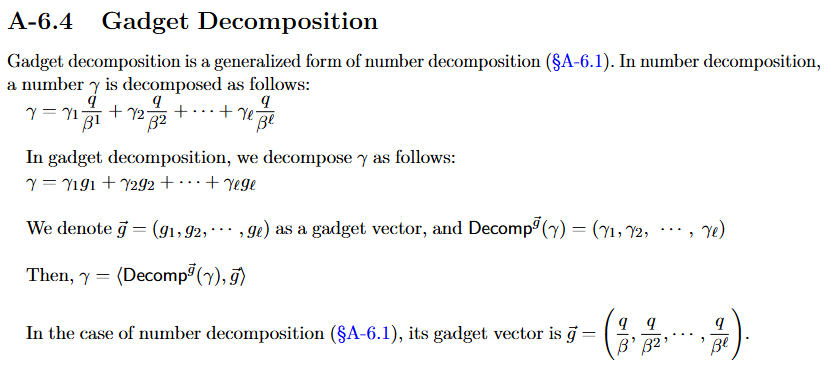

(source : https://arxiv.org/pdf/2503.05136)

Ainsi, nous décomposons $D_2$ en base $\beta$ et de niveau $\ell$ comme suit ($q$ est le plus grand numérateur possible comme nous travaillons en modulo $q$, donc le dernier facteur de décomposition sera forcément $\frac{q}{q} = \frac{q}{\beta^\ell}$, donc $\beta = q^{1/ \ell}$ ) : 
$$
\begin{array}{cc}
D_2 = \langle Decomp^g(D_2), g \rangle \\
g = (\frac{q}{\beta}, \frac{q}{\beta^2}, \dots, \frac{q}{\beta^\ell})  \\
Decomp^g(D_2) = (D_{2,1}, D_{2,2}, \dots, D_{2,\ell}) \\
\end{array}
$$
Nous avons la relation 
$$
\begin{array}{cc}
 \langle Decomp^g(D_2), g> \otimes Encr(S^2) \rangle \\
= D_2 \otimes Encr(S^2) \\
= D_2S^2 + A_iA_je
\end{array}
$$
Nous souhaitons augmenter le chiffré pour diminuer le plaintext car le bruit dépend du plaintext : 
$$
\begin{array}{cc}
\langle Decomp^g(D_2), (Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots, Encr(\frac{q}{\beta^\ell})) \rangle \\
= \langle Decomp^g(D_2), RLeV^{\beta, \ell} \rangle \\
= D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\
= D_{2,1}(\frac{q}{\beta}S^2 + e_1) + D_{2,2}(\frac{q}{\beta^2}S^2 + e_2) + \dots + D_{2,\ell}(\frac{q}{\beta^\ell}S^2 + e_\ell) \\
= \frac{q}{\beta}D_{2,1} S^2 + D_{2,1}e_1 + \frac{q}{\beta^2}D_{2,2} S^2 + D_{2,2}e_2 + \dots + \frac{q}{\beta^\ell}D_{2,_\ell} S^2 + D_{2,\ell}e_\ell \\
= S^2(\frac{q}{\beta}D_{2,1} + \frac{q}{\beta^2}D_{2,2} + \dots + \frac{q}{\beta^\ell}D_{2,\ell}) + \sum_{i = 1}^\ell (D_{2,i} e_i) \\
= D_2S^2 + \sum_{i = 1}^\ell (D_{2,i} e_i)
\end{array}
$$
Pour savoir si $\sum_{i = 1}^\ell (D_{2,i} e_i)$ est négligeable ou non, nous devons connaitre $|D_{2,i}|$ :  
$$
\begin{array}{cc}
\langle Decomp^g(D_2), g \rangle = D_{2,1}\frac{q}{\beta} + D_{2,2}\frac{q}{\beta^2} + \dots + D_{2,\ell}\frac{q}{\beta^\ell} \\
\text{Comme q = } \beta^\ell \\
= D_{2,1}\frac{\beta^\ell}{\beta} +  D_{2,2}\frac{\beta^\ell}{\beta^2} + \dots + D_{2,\ell}\frac{\beta^\ell}{\beta^\ell} \\
= D_{2,1}\beta^{\ell - 1} + D_{2,2}\beta^{\beta^{\ell - 2}} + \dots + D_{2,\ell}\beta^0
\end{array}
$$
Ainsi, $0 \leq |D_{2,i}| \leq \beta$, et $\beta = q^{1/\ell}$. Donc plus le niveau de décomposition $\ell$ est grand, plus $|D_{2,i}|$ sera petit. Nous souhaitons connaître $e_{relin} = |\sum_{i = 1}^\ell (D_{2,i} e_i)|$. Nous savons que $|D_{2,i}| \leq \beta$ et $|e_i| \leq \sigma$ donc $|e_{relin}| = \ell\beta\sigma = \ell q^{1/\ell}\sigma$.
Nous cherchons 
$$
\begin{array}{cc}
\underset{\ell}{\operatorname{arg \min}}\ f(\ell) = \ell q^{1/\ell}\sigma \\
q^{1/\ell} = e^{ln(q)/\ell} \\
f(\ell) = \ell e^{ln(q)/\ell}\sigma \\
f'(\ell) = e^{ln(q)/\ell} + \ell(\frac{d(e^{ln(q)/\ell})}{d\ell}) \\
\frac{d(e^{ln(q)/\ell})}{d\ell} = \frac{d(ln(q)/\ell)}{dl} e^{ln(q)/\ell} \\
= - \frac{ln(q)}{\ell^2} e^{ln(q)/\ell} \\
f'(\ell) = e^{ln(q)/\ell} - \ell \frac{ln(q)}{\ell^2} e^{ln(q)/\ell} \\
= q^{1/\ell} - \frac{ln(q)}{\ell} q^{1/\ell} \\
= q^{1/\ell} (1 - \frac{ln(q)}{\ell}) \\
q^{1/\ell} (1 - \frac{ln(q)}{\ell}) = 0 \\
 (1 - \frac{ln(q)}{\ell}) = 0 \\
 1 = \frac{ln(q)}{\ell} \\
 \ell = ln(q)
\end{array}
$$
Ainsi, on minimise le bruit lorsque $\ell = ln(q)$, soit $ln(q)q^{1/ln(q)}\sigma = ln(q) {e^{ln(q)}}^{1/ln(q)} \sigma = ln(q) e \sigma$. En pratique, on choisit plutôt $\ell < ln(q)$ pour limiter le nombre de clé privée chiffrée à envoyer à l'évaluateur, donc on s'expose à un bruit plus important, mais qui n'empêche de déchiffrer sur un résultat qui reste correct. Au final, nous réalisons la multiplication de chiffré comme suit : 
$$
\begin{array}{cc}
Encr(\Delta m_i) \otimes Encr(\Delta m_j) = (A_i, B_i)\otimes (A_j, B_j) \\
= (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \\
=  (A_iB_j + A_jB_i, B_iB_j) + \langle Decomp^g(A_iA_j), RLev^{\beta, \ell} (S^2) \rangle \\
\end{array}
$$

Puis, nous déchiffrons  :
$$
\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \big) \\
\approx Decr(D_1, D_0) + Decr(\langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle) \\
\approx D_0 + D_1S + D_2S^2 \\
\approx \Delta^2 m_i m_j
\end{array}
$$

La multiplication fonctionne mais nous aimerions un résultat $\Delta m_i m_j$ et non $\Delta^2 m_i m_j$ pour avoir $Decr(Encr(\Delta m_i) \otimes Encr(\Delta m_j)) \approx Decr(Encr(\Delta(m_i m_j))$. 
C'est l'étape du "rescaling". 
Nous ne pouvons pas directement diviser par $\Delta$ dans l'espace des chiffrés car nous travaillons modulo $q$, donc l'inverse d'un élément n'existe pas toujours et même s'il existe, la division n'est pas définie de manière unique. Une façon de divisier par $\Delta$ est d'utiliser le "modulo rescaling". 


## Rescaling

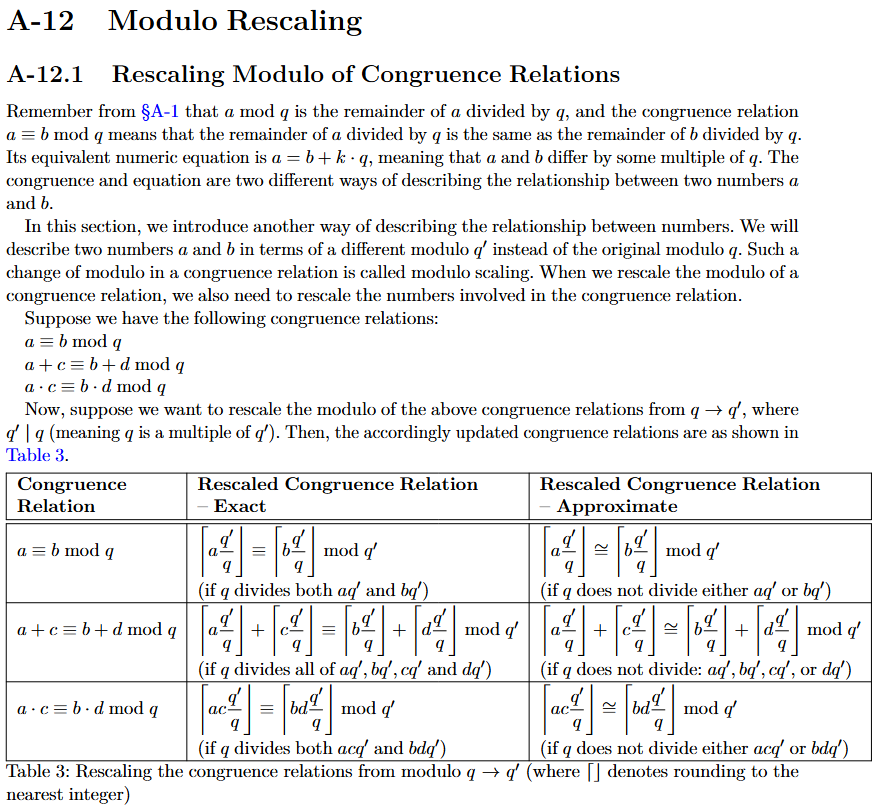

(source : https://arxiv.org/pdf/2503.05136)

En reprenant, si j'ai $a \equiv b \text{ mod } q$, $q' |q$ et $q = pq'$ alors 
$$
\begin{array}{cc}
a \equiv b \text{ mod } q \\
a = b + k \times q \\
a = b + k \times pq' \\
a \frac{q'}{q} = b\frac{q'}{q} + k \times pq'\frac{q'}{q} \\
a \frac{q'}{q} = b\frac{q'}{q} + k \times q' \\
a \frac{q'}{q} = b\frac{q'}{q} \text{ mod } q'
\end{array}
$$
$a \frac{q'}{q}$ et $b\frac{q'}{q}$ ne sont pas forcément des entiers. Comme nous travaillons dans les entiers, nous avons besoin d'arrondir pour être sûr de rester dans le bon espace : 
$$
\begin{array}{cc}
a \frac{q'}{q} = b\frac{q'}{q} \text{ mod } q' \\
\lceil a \frac{q'}{q} \rfloor \approx \lceil b\frac{q'}{q} \rfloor \text{ mod } q'
\end{array}
$$

Grâce à ce modulo rescaling, j'arrive au final à multiplier par $\frac{q'}{q}$ ce qui revient à diviser par $\frac{q}{q'} = \frac{pq'}{q'} = p$. Donc en choisissant $p = \Delta$, je peux diviser mon ciphertext par $\Delta$. J'ai donc $q = \Delta q'$. Et si je veux pouvoir rescale plusieurs fois, car je souhaite faire plusieurs multiplications avant de déchiffrer, je dois avoir : 
$$
\begin{array}{cc}
q = \Delta q' \\
q' = \Delta q'' \\
\vdots \\
q_0 = \Delta q_1
\end{array}
$$
Au final $q = \Delta^o q_0$ avec $o$ le nombre de multiplications que je souhaite effectuer dans l'espace des chiffrés. Cela implique que $q$ est un multiple de $q'$ et donc n'est pas premier. Il faut aussi que $q_0$ soit suffisamment grand pour qu'une fois arriver à $mod \ q_0$, il y ai encore suffisamment d'espace pour contenir le résultat qui va être déchiffré, soit au minimum $q_0 > \Delta m_{i + j} + e$. Comme $q_0$ doit être suffisamment grand alors $q = \Delta^o q_0$, explose rapidement et nous serons limiter qu'à un faible nombre de multiplication avant de devoir déchiffrer car ne ne pourrons plus diviser par $\Delta$. Une solution à cela est de passer par Residue Number System. Pour rappel : 

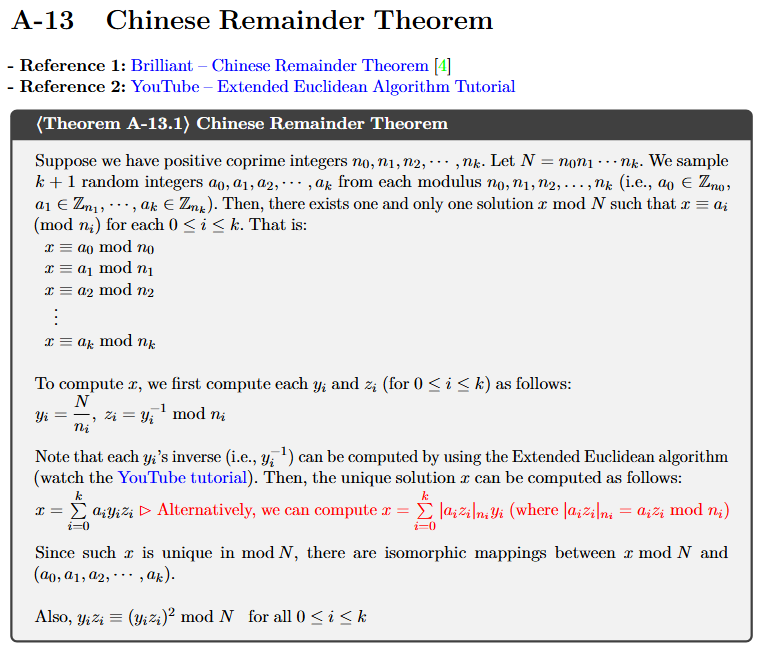

(source : https://arxiv.org/pdf/2503.05136)

ce qui nous permet de représenter cette valeur comme $\Delta^2 m_i m_j \text{ mod }q \rightarrow (a_0, a_1, \dots, a_k)$. Cette représentation permet de réduire la taille de chaque nombre manipuler et de paralléliser les calculs. Nous ne pouvons donc plus construire $q = q_0 \Delta^o$ car les $\Delta$ ne seront pas copremiers entre eux. Pour qu'ils puissent être copremiers entre eux, nous devons relaxer l'égalité en $n_i \approx \Delta$ tout en gardant $n_0 = q_0$. Pour garder le POC simple, je vais utiliser le système $q = \Delta^o q_0$. 

## Calcul du modulo 

Comme la multiplication de deux chiffrés entraînent une augmentation importante du bruit, qui ne sera réduit qu'après rescaling, il faut s'assurer que notre espace de chiffré puisse acceuillir $|(\Delta m_i + e_i) \times \Delta m_j + e_j)| = |\Delta ^2 m_i m_j + \Delta(m_i e_j + m_j e_i) + e_i e_j|$. 

In [45]:
import numpy as np
input_size = 2**1
power_of_two  = int(np.log2(input_size*2))
n = 2**power_of_two
n

4

In [46]:
maximum = 0 
Delta = 10**20
#Méthode sampling pour avoir une idée de la taille maximum de multiplication de message 
for i in range(500_000):
    if i % 1_000 == 0 :
        print(f"Iteration : {i}")
    # y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0] * 0.5
    y_i = (np.round(np.random.randn(1, n//2), 2)*0.2 + (np.round(np.random.randint(-3,3, size=(1,n//2))*(1j), 2)))[0]
    # y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

    # Encodage de deux messages
    m_i = CKKS_Encoding(m=y_i, Delta=Delta)
    # m_j = CKKS_Encoding(m=y_j, Delta=Delta)

    if np.abs(np.max(m_i)) > maximum : 
            maximum = int(np.abs(np.max(m_i)))
            print(maximum)

    # print(m_i, m_j, (poly_mutl_mod(m_i, m_j, q=q, with_modulus=False), q), sep="\n")
    # for value in poly_mutl_mod(m_i, m_j, q=q, with_modulus=False): 
    #     if np.abs(value) > maximum : 
    #         maximum = int(np.abs(value))
    #         print(maximum)

Iteration : 0
899999999999999360
17394826817189074944
22100000000000000000
113349217024203702272
150000000000000131072
200000000000000163840
250000000000000163840
Iteration : 1000
Iteration : 2000
Iteration : 3000
Iteration : 4000
Iteration : 5000
Iteration : 6000
Iteration : 7000
Iteration : 8000
Iteration : 9000
Iteration : 10000
Iteration : 11000
Iteration : 12000
Iteration : 13000
Iteration : 14000
Iteration : 15000
Iteration : 16000
Iteration : 17000
Iteration : 18000
Iteration : 19000
Iteration : 20000
Iteration : 21000
Iteration : 22000
Iteration : 23000
Iteration : 24000
Iteration : 25000
Iteration : 26000
Iteration : 27000
Iteration : 28000
Iteration : 29000
Iteration : 30000
Iteration : 31000
Iteration : 32000
Iteration : 33000
Iteration : 34000
Iteration : 35000
Iteration : 36000
Iteration : 37000
Iteration : 38000
Iteration : 39000
Iteration : 40000
Iteration : 41000
Iteration : 42000
Iteration : 43000
Iteration : 44000
Iteration : 45000
Iteration : 46000
Iteration : 47000


In [47]:
#Détermine la précision après la virgule 
Delta = 10**(20)
#Taille maximale d'un input encodé
max_size_m = maximum*2
# max_size_m = 2**60 
#Taille de l'input encodé avec du bruit 
max_size_m_delta_noised = max_size_m * Delta + 2*13
#Taille induite par la multiplication 
max_size_q = max_size_m_delta_noised**1

q_0 = 10**(25) ##25
# q_0 = max_size_q

nb_mult = 30 #30

#Taille induite par le nombre de multiplication 
q = q_0*(Delta**nb_mult)

S = mod_for_arb_int(np.array(
    [int(x) for x in np.random.randint(-1, 2, size=n)],
    dtype=object
), q)

## Démonstration

### Création des entrées 

In [48]:
# # Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)
Encr_m_j = CKKS_Encryption(m_encoded=m_j, q=q, S=S)

### Premier ciphetext : $(D_1, D_0)$

In [49]:
# Premier ciphertext 
A_i, B_i = Encr_m_i[0], Encr_m_i[1]
A_j, B_j = Encr_m_j[0], Encr_m_j[1]
D_0 = (poly_mutl_mod(B_i, B_j, q))
D_1 = mod_for_arb_int((poly_mutl_mod(A_i, B_j, q) + poly_mutl_mod(A_j, B_i, q)), q)

first_ciph = np.array((D_1, D_0))

### Deuxième ciphertext : $\langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle $

Pour rappel : 
$$
\begin{array}{cc}
\langle Decomp^g(D_2), (Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots, Encr(\frac{q}{\beta^\ell})) \rangle \\
= \langle Decomp^g(D_2), RLeV^{\beta, \ell} \rangle \\
= D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\
= D_{2,1}(\frac{q}{\beta}S^2 + e_1) + D_{2,2}(\frac{q}{\beta^2}S^2 + e_2) + \dots + D_{2,\ell}(\frac{q}{\beta^\ell}S^2 + e_\ell) \\
= \frac{q}{\beta}D_{2,1} S^2 + D_{2,1}e_1 + \frac{q}{\beta^2}D_{2,2} S^2 + D_{2,2}e_2 + \dots + \frac{q}{\beta^\ell}D_{2,_\ell} S^2 + D_{2,\ell}e_\ell \\
= S^2(\frac{q}{\beta}D_{2,1} + \frac{q}{\beta^2}D_{2,2} + \dots + \frac{q}{\beta^\ell}D_{2,\ell}) + \sum_{i = 1}^\ell (D_{2,i} e_i) \\
= D_2S^2 + \sum_{i = 1}^\ell (D_{2,i} e_i)
\end{array}
$$

Donc nous avons besoin de définir un niveau de décomposition $\ell$ et un facteur $\beta$, puis de calculer à la fois les $\frac{q}{\beta^i} = \beta^{\ell - i}$ et les $D_{2,i}$ associés. 

In [50]:
# Calcul des facteurs de décomposition en base Beta et au niveau l 
decomp_factors_beta = []
Beta = 2**16
ell = q.bit_length() // 16
# decomp_factors = [int(Beta**i) for i in range(ell)]   # Beta^0, Beta^1, ..., Beta^(ell-1)
for i in range (ell) : 
    # decomp_factors.append(int(np.round(q/(Beta**(i+1)), 0)))
    decomp_factors_beta.append(int(round((Beta**(ell-(i+1))))))

In [51]:
# Calcul de D_2 et de sa décomposition
D_2 = poly_mutl_mod(A_i, A_j, q)

def compute_D_2_factors(D_2, decomp_factors_beta):
    D_2_factors = []
    reste = D_2.copy()
    for decomp_factor in decomp_factors_beta:
        D_2_factors.append(reste // decomp_factor)
        reste -= D_2_factors[-1]*decomp_factor

    return D_2_factors


D_2_factors = compute_D_2_factors(D_2=D_2, decomp_factors_beta=decomp_factors_beta)

In [52]:
#Vérification que la décomposition recomposée nous donne D2
total = 0 
for i, factor in enumerate(D_2_factors):
    total += factor * decomp_factors_beta[i]
# print(total, D_2, sep="\n")
print(np.abs(total - D_2) % q)

[0 0 0 0]


Puis nous construisons l'ensemble des : $Encr(\frac{q}{\beta}S^2), Encr(\frac{q}{\beta^2}S^2), \dots ,Encr(\frac{q}{\beta^\ell}S^2) $. 

In [53]:
# Chiffrement de S^2 avec le facteur de décomposition associé 
list_of_S_2_Encr = []
S2 = poly_mutl_mod(S, S, q)
for i, decomp_factor in enumerate(decomp_factors_beta) :
    list_of_S_2_Encr.append(
        CKKS_Encryption(
            m_encoded= mod_for_arb_int(decomp_factor*S2, q),
            q = q, 
            S = S
        )
    )

Nous pouvons à présent calculer : 
$$
\begin{array}{cc}
D_{2,1} Encr(\frac{q}{\beta}S^2) + D_{2,2} Encr(\frac{q}{\beta^2}S^2) + \dots + D_{2,\ell} Encr(\frac{q}{\beta^\ell}S^2) \\ 
\approx D_2S^2
\end{array}
$$

In [54]:
# Calcul du deuxième ciphertext 
second_cipher = np.array(
    [
        [0 for _ in range(n)],
        [0 for _ in range(n)]
    ],
    dtype=object
)
# POur chaque facteur decomposé D_2
for i in range(ell): 
    # Pour chaque partie du ciphertext (soit A et B)
    for j in range(len(list_of_S_2_Encr[i])):
        second_cipher[j] += poly_mutl_mod(D_2_factors[i], list_of_S_2_Encr[i][j], q)

second_cipher = np.array([
    mod_for_arb_int(second_cipher[0], q), 
    mod_for_arb_int(second_cipher[1], q)
    ]
)

### Combinaison des ciphertexts 

In [55]:
Combine_cipher = np.array([
    mod_for_arb_int(first_ciph[0] + second_cipher[0], q), 
    mod_for_arb_int(first_ciph[1] + second_cipher[1], q), 
    ])
result = CKKS_Decryption(Combine_cipher, S, Delta, q)

### Déchiffrement de la multiplication 

Ici, nous allons déchiffrer le résultat de la multiplication **avant** rescaling, donc le résultat est  :
$$\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle \big) \\
= \Delta^2 m_i m_j + \Delta(m_ie_j + m_je_i) + e_ie_j
\end{array}
$$

ce qui ne pourra pas correctement se déchiffrmeent car le bruit est important et que le facteur de scaling est $\Delta^2$ et non $\Delta$. 

In [56]:
# Vérification des résultat 
mult_of_encoded_pltx = poly_mutl_mod(m_i, m_j, q)
mult_scaled_of_pltx =mod_for_arb_int(Delta*CKKS_Encoding((y_i * y_j), Delta), q)
mult_of_pltx_scaled =mod_for_arb_int(CKKS_Encoding((y_i * y_j), Delta), q)

mult_of_encr_decr_pltx = poly_mutl_mod(
    CKKS_Decryption(
        CKKS_Encryption(m_encoded=m_i,q=q,S=S),
        S=S, 
        Delta=Delta,
        q=q
    ), 
    CKKS_Decryption(
        CKKS_Encryption(m_encoded=m_j,q=q,S=S),
        S=S, 
        Delta=Delta,
        q=q
    ),
    q=q
) 
result_by_D = ((D_0 + poly_mutl_mod(D_1, S, q) + poly_mutl_mod(D_2, poly_mutl_mod(S, S, q), q)) % q)

print(
    f"{'Mult of ciphertexts':<32}: {result}\n\n"
    f"{'Encoded and scaled mult of pltx':<32}: {mult_scaled_of_pltx}\n\n"
    f"{'Mult of encoded pltxs':<32}: {mult_of_encoded_pltx}\n\n"
    f"{'Mult of Encr then Decr pltxs':<32}: {mult_of_encr_decr_pltx}\n\n"
    f"{'By D_2':<32}: {result_by_D}\n\n"
    f"{'Expected result' :<32} : {mult_of_pltx_scaled}"
)

# # Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q)
# Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q, in_percent=False)
# Show_encryption_impact(m=(mult_of_encoded_pltx), m_encr_decr=result, q=q, in_percent=True)
# Show_encryption_impact(m=(mult_of_pltx_scaled), m_encr_decr=result, q=q, in_percent=True)

Mult of ciphertexts             : [7989913875398956598957739047857079774938
 9999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999997094538312218645957991232203634713708579
 13511931929509508889141747350991994693730 3821557540406947291945920466125755318544]

Encoded and scaled mult of pltx : [7989913875398957465600000000000000000000
 99999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999

Nous obtenons le bon résultat, mais nous devons le rescaled pour espérer obtenir le correct résultat lors du décodage. 

### Rescaling en pratique 

In [57]:
q_prime = q // Delta
Combine_cipher_rescaled = np.array([
    mod_for_arb_int((Combine_cipher[0] // Delta), q_prime), 
    mod_for_arb_int((Combine_cipher[1] // Delta), q_prime)
])
result_rescaled = CKKS_Decryption(Combine_cipher_rescaled, S, Delta, q_prime)

In [58]:
Combine_cipher_rescaled

array([[86984566982847041887173646999715450602365261910513385189421250964529861742950604609193198610357772604466004750349552233051624822931923124878463437511214979184415872281284451870900376578397122955288403633711413848632797760951124651782778913495297598867895671491942799191625964379014801880240172688123764552706248099236631722625284008339148174916303149359292401771459305642464121691292710368002808408222722371974573818046476066813716354029215936878966561828544275507069674001204746280527923835457121334241257221075869725486611214573237343634378552744389761351642946018810065439312607908291694239055791636943,
        51557255928616173041078191982151564443251779068832466115710820335357859935142053255938834341575834249571444534173021005510570359705754742779104469786085929231263388764504053789597277436722561764259677598797083638202847104443062498614016023469564919550718214433376080411070722074996564705967860397710116386845647416329545575223433091712694946555421256256922954009853736714858632

In [59]:
A = Combine_cipher_rescaled[0]
B = Combine_cipher_rescaled[1]
Decr_m = round_for_arb_int((mod_for_arb_int((B + poly_mutl_mod(A, S, q_prime)), q_prime)) * Delta) // Delta
Decr_m

array([79899138753989565988,
       99999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999970945383122186459580,
       135119319295095088892, 38215575404069472922], dtype=object)

max noise: 1.7469168570850436e-13


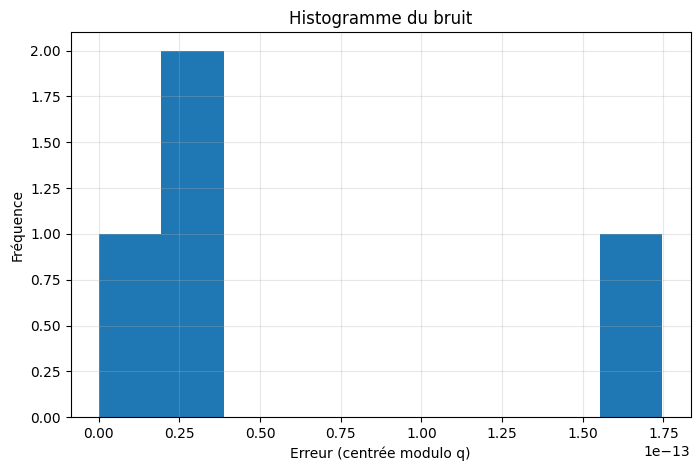

In [60]:
Show_encryption_impact(m=(mult_of_pltx_scaled), m_encr_decr=result_rescaled, q=q_prime, in_percent=True)

### Résultats 

Dans un premier temps nous pouvons comparer : 
$$\begin{array}{cc}
Decr \big( (D_1, D_0) + \langle Decomp^g(D_2), RLev^{\beta, \ell} (S^2) \rangle / \Delta \big) \\
= \Delta m_i m_j + (m_ie_j + m_je_i) + \frac{e_i e_j}{\Delta} \\
\approx \Delta m_i m_j
\end{array}
$$
et 

$$\begin{array}{cc}
Encoding(y_i \cdot y_j) = \Delta m_i m_j
\end{array}
$$


In [61]:
# Comparaison da la multiplication après scaling et déchiffrement avec la multiplication effectué avant l'encodage puis chiffré 
print(result_rescaled, mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime), "\n", sep="\n")

print(f"Différence entre la multiplication CKKS et la multiplication en clair : {np.abs(result_rescaled - mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime))}")

[79899138753989565988
 99999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999970945383122186459580
 135119319295095088892 38215575404069472922]
[79899138753989574656
 999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999

Enfin, nous pouvons comparer les résultats après décodage 

In [62]:
# Comparaison des deux résultats finaux 
CKKS_mult_decoded = CKKS_decoding(modulus_centering(result_rescaled, q_prime), Delta)

print(
    f"{'CKKS mult decoded':<19} : {CKKS_mult_decoded}\n"
    f"{'Expected result':<19} : {(y_i*y_j)}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<19} : {np.abs(CKKS_mult_decoded - (y_i*y_j))}")

CKKS mult decoded   : [(0.32331929619747113+1.415970951911794j) (1.27466347888232-1.2864154339901086j)]
Expected result     : [0.3233193 +1.41597095j 1.27466348-1.28641543j]
Erreur de précision : [1.6653345369377348e-15 2.2644195468014703e-15]


La multiplication entre un chiffré et un clair s'effectue de façon similaire, mais sans l'étape de relinéarisation  :
$$
\begin{array}{cc}
Encr(\Delta m_i) \cdot \Delta m_j \\
= (A,B) \cdot \Delta m_j \\
= (A \cdot \Delta m_j, B \cdot \Delta m_j) \\
= (A \cdot \Delta m_j,(-AS + \Delta m_i + e_i) \Delta m_j ) \\
= (A \cdot \Delta m_j, -AS \Delta m_j + \Delta^2 m_i m_j + m_j e_i)
\end{array}
$$
Lors du déchiffrement cela nous donne : 
$$
\begin{array}{cc}
 -AS \Delta m_j + \Delta^2 m_i m_j + m_j e_i + AS\Delta m_j \\
 = \Delta^2 m_i m_j + m_j e_i
\end{array}
$$
Donc nous avons seulement besoin de relinéariser le résultat pour obtenir $\Delta m_i m_j + \frac{m_j e_i}{\Delta}$. 
Le bruit est moins important que pour une multiplication par un chiffré, et il y a une étape en moins de nécessaire. 

In [63]:
# # Création de deux messages
y_i = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
y_j = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]

# Encodage de deux messages
m_i = CKKS_Encoding(m=y_i, Delta=Delta)
m_j = CKKS_Encoding(m=y_j, Delta=Delta)

# Chiffrement des deux messages 
Encr_m_i = CKKS_Encryption(m_encoded=m_i, q=q, S=S)

In [64]:
# Multiplication 
A_i = Encr_m_i[0]
B_i = Encr_m_i[1]
Result_mult_pltx = np.array((poly_mutl_mod(A_i, m_j, q), poly_mutl_mod(B_i, m_j, q)), dtype=object)

#Rescaling 
q_prime = q // Delta
Result_mult_pltx_rescaled = np.array([
    mod_for_arb_int((Result_mult_pltx[0] // Delta), q_prime), 
    mod_for_arb_int((Result_mult_pltx[1] // Delta), q_prime)
])
result_rescaled = CKKS_Decryption(Result_mult_pltx_rescaled, S, Delta, q_prime)

In [65]:
# Comparaison da la multiplication après scaling et déchiffrement avec la multiplication effectué avant l'encodage puis chiffré 
print(result_rescaled, mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime), "\n", sep="\n")

print(f"Différence entre la multiplication CKKS et la multiplication en clair : {np.abs(result_rescaled - mod_for_arb_int(CKKS_Encoding((y_i * y_j) , Delta), q_prime))}")

[144497353764910307945 268591962328575827844
 99999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999866382984076695835223
 99999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999999

In [66]:
# Comparaison des deux résultats finaux 
CKKS_mult_one_encr_decoded = CKKS_decoding(modulus_centering(result_rescaled, q_prime), Delta)

print(
    f"{'CKKS mult decoded':<19} : {CKKS_mult_one_encr_decoded}\n"
    f"{'Expected result':<19} : {(y_i*y_j)}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<19} : {np.abs(CKKS_mult_one_encr_decoded - (y_i*y_j))}")

CKKS mult decoded   : [(4.440704951923338-0.5334376148125226j) (-1.5507578766251324+2.138902703653562j)]
Expected result     : [ 4.44070495-0.53343761j -1.55075788+2.1389027j ]
Erreur de précision : [7.9966891354784e-15 6.75322301446426e-15]


Maintenant que nous avons un algorithme qui permet de faire un multiplication, nous pouvons tester d'ne faire un maximum. 

## Multiplication : wrap-up 

In [67]:
def CKKS_multiplication_pltx(Encr_m_i, m_j, q, Delta):
    # Multiplication 
    A_i = Encr_m_i[0]
    B_i = Encr_m_i[1]
    Result_mult_pltx = np.array((poly_mutl_mod(A_i, m_j, q), poly_mutl_mod(B_i, m_j, q)), dtype=object)

    #Rescaling 
    q_prime = q // Delta
    Result_mult_pltx_rescaled = np.array([
        mod_for_arb_int((Result_mult_pltx[0] // Delta), q_prime), 
        mod_for_arb_int((Result_mult_pltx[1] // Delta), q_prime)
    ])

    return Result_mult_pltx_rescaled, q_prime


In [68]:
def CKKS_mutiplication_ct(Encr_m_i, Encr_m_j, q, Delta, S): 

    # Calcul du premier ciphertext
    A_i, B_i = Encr_m_i[0], Encr_m_i[1]
    A_j, B_j = Encr_m_j[0], Encr_m_j[1]
    D_0 = (poly_mutl_mod(B_i, B_j, q))
    D_1 = mod_for_arb_int((poly_mutl_mod(A_i, B_j, q) + poly_mutl_mod(A_j, B_i, q)), q)
    first_ciph = np.array((D_1, D_0))

    n = len(A_i)

    # Calcul du second ciphertext
    D_2 = poly_mutl_mod(A_i, A_j, q)
    # Calcul des facteurs de décomposition en base Beta et au niveau l 
    decomp_factors_beta = []
    Beta = 2**16
    ell = q.bit_length() // 16
    for i in range (ell) : 
        decomp_factors_beta.append(int(round((Beta**(ell-(i+1))))))
    D_2_factors = compute_D_2_factors(D_2=D_2, decomp_factors_beta=decomp_factors_beta)

    # Chiffrement de S^2 avec le facteur de décomposition associé 
    list_of_S_2_Encr = []
    S2 = poly_mutl_mod(S, S, q)
    for i, decomp_factor in enumerate(decomp_factors_beta) :
        list_of_S_2_Encr.append(
            CKKS_Encryption(
                m_encoded= mod_for_arb_int(decomp_factor*S2, q),
                q = q, 
                S = S
            )
        )

    # Composition du deuxième ciphertext 
    second_cipher = np.array(
        [
            [0 for _ in range(n)],
            [0 for _ in range(n)]
        ],
        dtype=object
    )
    
    # POur chaque facteur decomposé D_2
    for i in range(ell): 
        # Pour chaque partie du ciphertext (soit A et B)
        for j in range(len(list_of_S_2_Encr[i])):
            second_cipher[j] += poly_mutl_mod(D_2_factors[i], list_of_S_2_Encr[i][j], q)

    second_cipher = np.array([
        mod_for_arb_int(second_cipher[0], q), 
        mod_for_arb_int(second_cipher[1], q)
        ]
    )

    # Combinaison des deux ciphertext en un
    Combine_cipher = np.array([
        mod_for_arb_int(first_ciph[0] + second_cipher[0], q), 
        mod_for_arb_int(first_ciph[1] + second_cipher[1], q), 
        ])

    #Rescaling
    q_prime = q // Delta
    Combine_cipher_rescaled = np.array([
        mod_for_arb_int((Combine_cipher[0] // Delta), q_prime), 
        mod_for_arb_int((Combine_cipher[1] // Delta), q_prime)
    ])

    return Combine_cipher_rescaled, q_prime

In [69]:
Combine_cipher_rescaled_by_func, q_prime_func = CKKS_mutiplication_ct(
                Encr_m_i=Encr_m_i, 
                Encr_m_j=Encr_m_j,
                q=q, 
                Delta=Delta, 
                S=S
            )

CKKS_mult_func_decoded = CKKS_decoding(
    modulus_centering(
        CKKS_Decryption(
            Combine_cipher_rescaled_by_func,
            S=S, 
            Delta=Delta,
            q=q_prime_func
        ), q=q_prime_func
    ),Delta=Delta
)

In [70]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {(y_i*y_j)}"
    )

# Erreur de précision 
print(f"{'Erreur de précision':<26} : {np.abs(CKKS_mult_func_decoded - (y_i*y_j))}")

CKKS mult function decoded : [(5.444812344254109-3.801459319958637j) (1.0064081027850686+1.2864154339901084j)]
Expected result            : [ 4.44070495-0.53343761j -1.55075788+2.1389027j ]
Erreur de précision        : [3.418800596794062 2.6955208014762473]


Nous pouvons tester l'erreur de précision une fois l'ensemble du budget de profondeur utilisé. 

In [71]:
list_of_inputs = []
list_of_encrypted_inputs = []
for i in range(nb_mult+1): 
    y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
    list_of_inputs.append(y)
    list_of_encrypted_inputs.append(
        CKKS_Encryption(
            m_encoded=CKKS_Encoding(
                m=y, Delta=Delta, q=q
            ), q=q, S=S
        )
    )

In [72]:
intial_combine_cipher = list_of_encrypted_inputs[-1]
q_for_mult = q
for i in range(nb_mult):
    print(f"{i+1}e multiplication")
    combine_cipher_final, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication
6e multiplication
7e multiplication
8e multiplication
9e multiplication
10e multiplication
11e multiplication
12e multiplication
13e multiplication
14e multiplication
15e multiplication
16e multiplication
17e multiplication
18e multiplication
19e multiplication
20e multiplication
21e multiplication
22e multiplication
23e multiplication
24e multiplication
25e multiplication
26e multiplication
27e multiplication
28e multiplication
29e multiplication
30e multiplication


In [73]:
CKKS_mult_func_decoded = CKKS_decoding(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_prime_final
        ), q=q_prime_final
    ),Delta=Delta
)

expected_result = 1
for i in range(nb_mult+1): 
    expected_result = expected_result * list_of_inputs[i]

In [74]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {error_real_part * 100 / np.abs(expected_result.real)} (%)\n"
    f"{'Partie imaginaire':<26} : {error_imag_part * 100 / np.abs(expected_result.imag)} (%)"
)

CKKS mult function decoded : [(45380.53280466082+28453.799656417825j) (-61339.981316043326-61095.261819358675j)]
Expected result            : [ 41881480.77658845+45786379.45038819j -27097440.22510041 +7496830.38891326j]
Erreur de précision        : [(-41836100.24378379-45757925.65073177j) (27036100.243784364-7557925.650732616j)]
Erreur de précision (%)
Partie réelle              : [-99.89164535  99.77363182] (%)
Partie imaginaire          : [ -99.93785532 -100.8149479 ] (%)


# Bootstrapping


Une fois arrivé au dernier modulo $q_0$, il n'est plus possible de continuer a effectuer des opérations. Nous pouvons décider de déchiffrer le résultat, puis de le chiffrer à nouveau en utilisant notre modulus $q = \Delta ^o q_0$ pour repartir avec un ciphertext ayant un grand modulus er permettant de faire $o$ multiplications. Cependant, cela demanderai une étape de déchiffrement, ce qui ferais de CKKS un schéma homomorphe à niveau, et non complètement homomorphe. 
Il existe une méthode pour modifier le modulus de notre ciphertext sans avoir besoin de le déchiffrer : il s'agit du bootstrapping.  

Notre but est d'opérer la transformation suivante : $\begin{array}{cc}(A,B) \ mod \ q_0 \Rightarrow (A',B') \ mod \ q_{\Delta^o}\end{array}$. Intuitivement, nous pourrions nous dire qu'il suffit de changer le modulo, car nous l'augmentons. Par exemple :  
$$
\begin{array}{cc}
A = [1, 2, 3, 4] \ mod \ 10 \ ; B = [3, 5, 1, 9] \ mod \ 10 \\
\Downarrow \\
A' = [1, 2, 3, 4] \ mod \ 100 \ ; B' = [3, 5, 1, 9] \ mod \ 100 \\
1 \equiv 1 \ mod \ 100 \\
2 \equiv 2 \ mod \ 100 \\
\vdots \\
9 \equiv 9 \ mod \ 100 \\
\end{array}
$$
Cependant, l'augmentation de modulo doit respecté une autre contrainte que celle de la congruence. En effet, $B + AS = \Delta m + e \ mod \ q_0$. Donc nous avons besoin que $B' + A'S  = \Delta m + e \ mod \ q_{\Delta^o}$. Avec cette nouvelle contrainte, tout les représentants de classe ne se valent pas. Ainsi, nous devons choisir les bons représentants de classe parmi l'ensemble des possibles. 
Est-ce que $1 \equiv 1 \ mod \ 100$ ? Ou bien $1 \equiv 81 \ mod \ 100$ ?
Le seul indice que nous ayons pour résoudre ce système est que nous devons trouver des représentants tels que $B' + A'S  = \Delta m + e \ mod \ q_{\Delta^o}$. $\Delta m + e$ étant chiffré dans $B$, nous ne pouvons pas utiliser leurs valeurs à moins de déchiffrer le message. Notre but initial était d'augmenter à nouveau le niveau multiplicatif pour permettre de poursuivre nos calculs sur les messages chiffrés. Si pour ce faire, nous avons besoin de déchiffrer le message, alors notre schéma est simplement limité à $\Delta^o$ multiplications avant déchiffrement.  
Une autre faon de voir le problème est de partir de $(A,B)\ mod \ q_0 = (A + k\times q_0, B + k' \times q_0) = (A + k\times q_0, B + k' \times q_0) \ mod \ q_{\Delta^o}$. Si nous déchiffrons ce message nous obtenons : 
$$
\begin{array}{cc}
(B + k' q_0) + (A+k q_0)S \\
= -AS + \Delta m + e + k'q_0 + AS + kq_0S \\
= \Delta m + e + k'q_0 + kq_0S \\
\end{array}
$$
Le message sera perdu au moment du déchiffrement. Pour récupérer correctement le message, nous avons besoin de supprimer les termes $k'q_0, kq_0$, sans connaître $k, k'$. 
L'opération que nous souhaiterions faire est une réduction modulaire par $q_0$. Cette opération n'est pas réalisable homomorphiquement car nous ne disposons que des opérations $(+, \cdot)$. La fonction de réduction modulaire se visualise comme cela : 

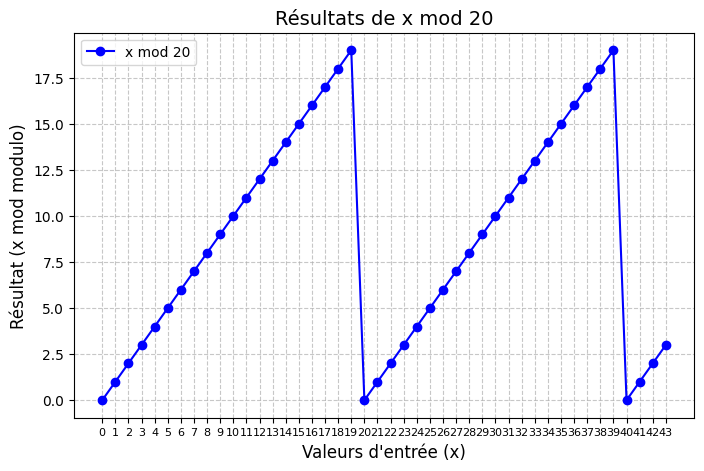

In [75]:
# Paramètres
modulo = 20  # Change cette valeur pour tester d'autres modulus
values = range(int(2.2*modulo))  # Valeurs d'entrée (0 à 9)

# Calcul des résultats modulo
mod_results = [value % modulo for value in values]
approximate_mod_results = [(modulo / (2 * np.pi)) * np.sin((2 * np.pi * t) / modulo) for t in values ]

# Création du graphique
plt.figure(figsize=(8, 5))  # Taille de la figure
plt.plot(values, mod_results, marker='o', linestyle='-', color='b', label=f'x mod {modulo}')

# Personnalisation du graphique
plt.title(f"Résultats de x mod {modulo}", fontsize=14)
plt.xlabel("Valeurs d'entrée (x)", fontsize=12)
plt.ylabel("Résultat (x mod modulo)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(values, fontsize="8")  # Affiche tous les ticks de 0 à 9
plt.legend()

# Affichage
plt.show()

C'est donc une fonction périodique en $q$; Donc nous cherchons une approximation de cette fonction qui est périodique en $q$, qui se calcule avec des opérations linéaires et qui ne consomme pas trop de niveaux multiplicatifs. 
Nous savons que dans $B = -AS + \Delta m + e$, la partie $\Delta m +e << q_0$. Par conséquent, $\Delta m + e$ se trouve sur la première partie d'une des dents de scie de la fonction. Nous pouvons restreindre nos recherche à une fonction qui approxime bien la fonction de réduction modulaire uniquement sur les premières parties des dents de scies. 
Une fonction qui répond à ces critères est la fonction sinus donné par $f(x) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi x}{q_0})$ : 

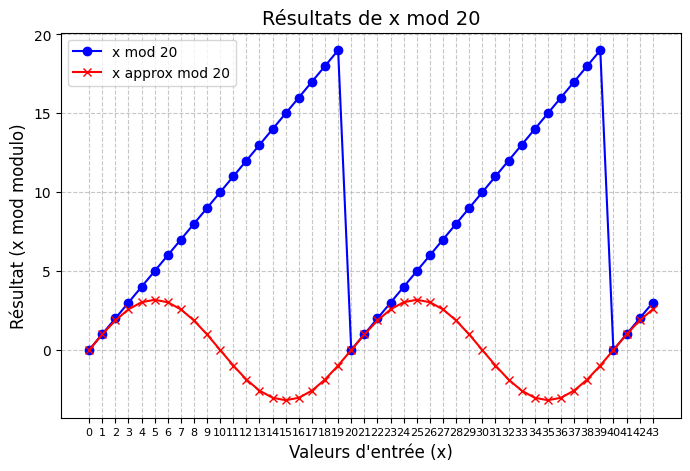

In [76]:
# Paramètres
modulo = 20  # Change cette valeur pour tester d'autres modulus
values = range(int(2.2*modulo))  # Valeurs d'entrée (0 à 9)

# Calcul des résultats modulo
mod_results = [value % modulo for value in values]
approximate_mod_results = [(modulo / (2 * np.pi)) * np.sin((2 * np.pi * t) / modulo) for t in values ]

# Création du graphique
plt.figure(figsize=(8, 5))  # Taille de la figure
plt.plot(values, mod_results, marker='o', linestyle='-', color='b', label=f'x mod {modulo}')
plt.plot(values, approximate_mod_results, marker='x', linestyle='-', color='r', label=f'x approx mod {modulo}')


# Personnalisation du graphique
plt.title(f"Résultats de x mod {modulo}", fontsize=14)
plt.xlabel("Valeurs d'entrée (x)", fontsize=12)
plt.ylabel("Résultat (x mod modulo)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(values, fontsize="8")  # Affiche tous les ticks de 0 à 9
plt.legend()

# Affichage
plt.show()

Avec un modulo vraiment grand, nous avons la représentation suivante : 

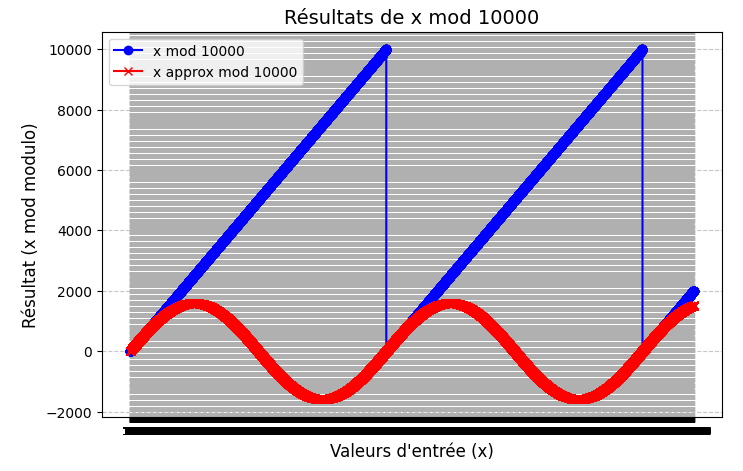

Il apparemment clairement que si $\Delta m + e \ mod \ q_0$ est petit, alors l'approximation sera bonne, et très mauvaise sinon. 
Cela se vérifie aussi mathématiquement. Pour rappel, nous avons $f(x) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi x}{q_0})$. Le développement limite d'ordre $3$ de la fonction $sin$ nous donne $sin(x) = x - \frac{x^3}{6} + O(x^3)$. Ainsi, dans le cas où $x$ est très petit, nous avons $sin(x) \approx x$. Dans notre cas, nous avons 
$$
\begin{array}{cc}
f(\Delta m + e + k q_0) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi (\Delta m + e + k q_0)}{q_0}) \\
= \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi (\Delta m + e)}{q_0} + \frac{2 \pi kq_0}{q_0} ) \\
\frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi (\Delta m + e)}{q_0} + 2 \pi k)
\end{array}
$$
Comme la fonction $sin$ est de périodique en $2 \pi$, nous avons $sin(\theta + 2 \pi) = sin(\theta)$ donc
$$
\begin{array}{cc}
f(\Delta m + e + k q_0) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi (\Delta m + e)}{q_0})
\end{array}
$$
Avec $\Delta m + e \ mod \ q_0 << q_0$, nous avons $sin(\frac{2 \pi (\Delta m + e)}{q_0}) \approx (\frac{2 \pi (\Delta m + e)}{q_0})$ donc 
$$
\begin{array}{cc}
f(\Delta m + e + k q_0) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi (\Delta m + e)}{q_0}) \\
\approx \frac{q_0}{2 \pi} \cdot \frac{2 \pi (\Delta m + e)}{q_0} \\
\approx \Delta m + e
\end{array}
$$
Nous avons donc trouver une fonction qui approxime bien la réduction modulaire. Cependant, la fonction $sin$ ne se calcule par linéairement donc nous allons avoir besoin de l'approximer pour l'évaluer de façon homomorphe. Nous allons utiliser la série de Taylor pour approximer la fonction. A partir d'une fonction $f(x)$, son approximation de Taylor centré en $a$ est donné par $f(a) + \frac{f'(a)}{1!}(X - a) +\frac{f''(a)}{2!}(X - a)^2 + \dots = \sum_{d=0}^{\infty} \frac{f^{(d)}(a)}{d!}(X - a)^d$.
Il est possible de couper cette série à un certain degré $D$ pour obtenir une approximation de la fonction. Généralement, plus le degré $D$ est grand, plus l'approximation est précise. Egalement, la fonction est plus précise lorsque les données sont proche de $X - a$. 
Dans notre cas, nous cherchons à approximer $sin$ proche de $0$ :
$$
\begin{array}{cc}
f(x) = \frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi}{q_0}\cdot 0) + \frac{q_0}{2 \pi} \cdot \frac{2 \pi}{q_0} \cdot \frac{cos(\frac{2 \pi}{q_0}\cdot 0)}{1!}\cdot x + \frac{q_0}{2 \pi} \cdot (\frac{2 \pi}{q_0})^2 \cdot \frac{-sin(\frac{2 \pi}{q_0} \cdot 0)}{2!} \cdot x^2 + \dots \\
= \frac{q_0}{2 \pi} \dot \sum_{j=0}^{\infty}\big(\frac{(-1)^j}{(2j+1)!} \cdot (\frac{2 \pi x}{q_0})^{2j + 1} \big) \\
\approx \frac{q_0}{2 \pi} \cdot \sum_{j=0}^h \big(\frac{(-1)^j}{(2j+1)!} \cdot (\frac{2 \pi x}{q_0})^{2j + 1} \big) = \hat{f}(x)
\end{array}
$$
Au final, $f(x) \approx \hat{f}(x)$, avec $\hat{f}(x)$ un polynôme de degré $(2h + 1)$.

Le problème de cette approche est que notre entrée sera $\Delta m + kq_0$. Le problème est que nous allons avoir besoin de calculer notre approximation polynomiale dans l'intervalle $[-q_0k, q_0k]$. De cet fait, le degré explose et la méthode devient inefficace. 
Une autre idée est de se servir de la formule d'Euler $e^{i \cdot \theta} = cos \theta + i \cdot sin \theta$ qui nous donne : 
$$
\begin{array}{cc}
e^{-i \cdot \theta} = cos \theta - i \cdot sin \theta \\
e^{i \cdot \theta} - e^{-i \cdot \theta} = (cos \theta + i \cdot sin \theta) - ( cos \theta - i \cdot sin \theta ) \\
= 2i \ sin \theta \\
\frac{-i}{2}(e^{i \cdot \theta} - e^{-i \cdot \theta}) = \frac{-i}{2} \cdot 2i \ sin \theta \\
= sin \theta
\end{array}
$$
En remplaçant $\theta$ par $\frac{2 \pi x}{q_0}$ nous avons 
$$
\begin{array}{cc}
\frac{q_0}{2 \pi} \cdot sin(\frac{2 \pi x}{q_0}) = \frac{q_0}{2 \pi} \cdot \frac{-i}{2}(e^{i \cdot \frac{2 \pi x}{q_0}} - e^{-i \cdot \frac{2 \pi x}{q_0}})
\end{array}
$$
A nouveau, pour calculer $e^x$, nous avons besoin de l'approximer. En utilisant le développement limite, nous avons $e^x \approx 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!}$, ce qui nous donne : 
$$
\begin{array}{cc}
e^{\frac{2 \pi i x}{q_0}} = \sum_{k=0}^{\infty}\frac{1}{k!}(\frac{2 \pi i x}{q_0})^k
\end{array}
$$
En coupant au degré $d_0$, nous obtenons : 
$$
\begin{array}{cc}
e^{\frac{2 \pi i x}{q_0}} \approx \sum_{k=0}^{d_0}\frac{1}{k!}(\frac{2 \pi i x}{q_0})^k
\end{array}
$$
Une manière efficace de faire se calculer est de le décomposer comme suit : 
$$
\begin{array}{cc}
e^x = (e^{x/2^r})^{2^r} \\
(e^{\frac{2 \pi i x}{q_0}/2^r}) = \sum_{k=0}^{\infty}\frac{1}{k!}(\frac{2 \pi i x}{2^r q_0})^k
\end{array}
$$
Puis de faire le somme cumulatif des carrés : 
$$
\begin{array}{cc}
e^{\frac{2 \pi i x}{q_0}} = ((((\sum_{k=0}^{\infty}\frac{1}{k!}(\frac{2 \pi i x}{2^r q_0})^k)^2)^2)^{\dots})^2
\end{array}
$$
Une fois $e^{\frac{2 \pi i x}{q_0}}$ obtenu, il nous reste à calculer son conjugué $e^{\frac{-i \cdot 2 \pi x}{q_0}}$. Conjugué le vecteur homomorphiquement veut dire que nous changeons la sortie du décodage de $Vc = (y_1, \dots, y_n, \overline{y_n}, \dots, \overline{y_1})$ en $(\overline{y_1}, \dots, \overline{y_n}, y_n, \dots,y_1)$.  
En modifiant la matrice décodage correctement, nous pouvons simplement obtenir le conjugué de notre vecteur. En effet, la transformation de décodage est la suivante : 
$$
\begin{array}{cc}
\begin{pmatrix}  
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
1 & \omega^7 & (\omega^{7})^{2} & \cdots & (\omega^7)^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
c_4 \\
\vdots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
y_1 \\
\vdots \\
y_{n} \\
\overline{y_n} \\
\vdots \\
\overline{y_1}
\end{pmatrix}  \\ \\
y_1 = c_1 + \omega c_2 + \omega^2 c_3 + \dots + \omega^{n-1} c_n \\
\vdots \\
y_n = c_1 + \omega c_2 + \omega^2 c_3 + \dots + \omega^{n-1} c_n \\
\overline{y_n} = c_1 + \omega^{n-1} c_2 + \omega^{n-1^2} c_3 + \dots + \omega^{n-1^{n-1}} c_n \\
\vdots \\
\overline{y_1} = c_1 + \omega^{2n-1} c_2 + \omega^{(2n-1)^2} c_3 + \dots + \omega^{(2n-1)^{n-1}} c_n \\
\end{array}
$$
Pour avoir en premier coefficient $\overline{y_1}$ à la place de $y_1$, il suffit d'intervertir les lignes de la matrice ce qui nous donne : 
$$
\begin{array}{cc}
\begin{pmatrix}  
1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1} \\
\vdots & & \ddots & & \vdots\\
1 & \omega^7 & (\omega^{7})^{2} & \cdots & (\omega^7)^{n - 1} \\
1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\
1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\
1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} 
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
c_4 \\
\vdots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
\overline{y_1} \\
\vdots \\
\overline{y_n} \\
y_n \\
\vdots \\
y_1
\end{pmatrix} 
\end{array}
$$
Nous pouvons remarquer que $\omega^{2n-1} = \overline{\omega} = \omega^{-1}, \omega^{2n-3} = \overline{\omega^{3}} = (\omega^3)^{-1}, \dots$ et ainsi réécrire la matrice comme 
$$
\begin{array}{cc}
\begin{pmatrix}  
1 & \omega^{-1} & (\omega^{2})^{-1} & \cdots & (\omega^{n - 1})^{-1} \\  
1 & (\omega^3)^{-1} & ((\omega^{3})^{2})^{-1} & \cdots & ((\omega^3)^{n - 1})^{-1} \\
1 & (\omega^5)^{-1} & ((\omega^{5})^{2})^{-1} & \cdots & ((\omega^5)^{n - 1})^{-1} \\
1 & (\omega^7 )^{-1} & ((\omega^{7})^{2})^{-1} & \cdots & ((\omega^7)^{n - 1})^{-1} \\
\vdots & & \ddots & & \vdots\\
1 & (\omega^{2n-1})^{-1} & ((\omega^{2n-1})^{2})^{-1} & \cdots & ((\omega^{2n-1})^{n - 1})^{-1}
\end{pmatrix}
\begin{pmatrix}
c_1 \\
c_2 \\
c_3 \\
c_4 \\
\vdots \\
c_n
\end{pmatrix}
=
\begin{pmatrix}
\overline{y_1} \\
\vdots \\
\overline{y_n} \\
y_n \\
\vdots \\
y_1
\end{pmatrix}
\end{array}
$$
Au final, pour que le résultat du décodage d'un vecteur soit le conjugué de son décodé, il faut évaluer notre polynôme en l'inverse des racines unités : 
$\overline{y_k} = c_1 + c_2(\omega^{k})^{-1}+ \dots + c_{n-1}  (\omega^{k^{n-1}})^{-1}$. 
Nous savons donc que pour obtenir le conjugué, il suffit de prendre l'inverse des racines unités. Cependant, nous souhaitons conjuguer homomorphiquement, donc nous ne pouvons pas modifier la matrice de décodage, nous pouvons simplement agir sur $(A,B)$. Plutôt que d'évaluer notre fonction en l'inverse des points d'évaluations, i.e $f(\omega^{-1})$, nous allons plutôt chercher à d'abord inverser le polynômes avant de l'évaluer sur les points d'évaluations, i. e $f(X^{-1})(\omega)$. En modifiant les coefficients du polynômes de $X$ à $X^{-1}$, nous modifions aussi la relation de déchiffrement :
$$
\begin{array}{cc}
B + AS \Rightarrow B^{-1} + A^{-1}S^{-1}
\end{array}
$$
L'utilisateur ne dispose que de sa clé privée $S$, donc nous avons besoin de modifier la clé de chiffrement du ciphertext de $S^{-1}$ vers $S$. C'est l'opération de key switching, qui définit le passage d'un ciphertext se déchiffrant via $S'$ vers un ciphertext se déchiffrant via $S$ définie comme : 
$$
\begin{array}{cc}
Encryption(\Delta m)_S = (0, B) + \langle Decomp^{\beta,\ell}(A), RLev(S') \rangle
\end{array}
$$

Dans notre cas, nous souhaitons passer de $S^{-1}$ à $S$ donc : 
$$
\begin{array}{cc}
Encryption(\Delta m)_S = (0, B^{-1}) + \langle Decomp^{\beta,\ell}(A^{-1}), RLev_S(S^{-1}) \rangle
\end{array}
$$

Pour changer de clé, nous avons besoin de $RLev_s(S^{-1})$, soit le chiffrement par la clé $S$ de la décomposition de la clé $S^{-1}$. Cela ressemble aux clés de relinéarisation $RLev^{\beta, \ell} (S^2)$, qui était le chiffrement par la clé $S$ de la décomposition de $S^2$. De la même façon, l'utilisateur aura besoin de calculer au préalable une clé de conjugaison $RLev_s(S^{-1})$ puis l'envoyer à l'évaluateur pour que celui-ci puisse conjuguer de façon homomorphe au besoin. 

Nous avons donc une méthode pour augmenter le modulus de $q_0$ vers $q_L$ et faire disparaître le résidu $kq_0$ dans notre ciphertext. 





Pour le moment, nous appliquons la fonction sinus à notre ciphertext qui est représenté par les coefficients du polynômes et un problème persiste. En effet, effectuer une opération homomorphe sur un ciphertext, revient à l'effectuer les valeurs en input. Donc pour le moment, en faisant la fonction sinus $f(x)$ homomorphiquement, nous ne faisons pas réellement $(f(c_0), f(c_1), \dots, f(c_{n-1}))$ mais plutôt $(f(y_0), \dots, f(y_{\frac{n}{2}-1}), f(\overline{y_0}), \dots, f(\overline{y_{\frac{n}{2}-1}}))$. Malheureusement, le résultat n'est pas le même. En effet, imaginons nous voulons agir en direct sur les slots, donc d'abord nous déchiffrons 
$$\begin{array}{cc}
(B + k' q_0) + (A+k q_0)S \\
= -AS + \Delta m + e + k'q_0 + AS + kq_0S \\
= \Delta m + e + k'q_0 + kq_0S \\
\end{array}$$
puis nous décodons : $V \cdot (\Delta m + e + K(x)q_0)$ alors la multiplication matricielle va multiplier les résidus entiers par des nombres complexes fractionnaires. ainsi, la méthode précédemment vue ne fonctionnera plus.  Donc lorsque le résidus est sur les coefficients, il est entiers mais lorsqu'il est décodé et passer sur les inputs, il n'est plus forcément entiers. Donc nous ne pouvons pas faire $f(x)$ homomorphiquement sur notre cipher, car nous agirions sur les inputs plutôt que sur les coefficients. Nous aimerions donc que les valeurs qui soient manipulés lors d'opérations homomorphes soient les coefficients plutôt que les inputs. Actuellement, nos valeurs en slots sont nos inputs $(y, \overline{y})$. Ils sont en relation avec leur représentation en coefficient non chiffrés via $(y, \overline{y}) = V \cdot m$. Ainsi, nos valeurs que nous manipulons dans les slots sont $V \cdot m$, et nous aimerions que ça soit les valeurs des coefficients donc $m$. Donc il suffit de multiplier les valeurs dans les slots par $V^{-1}$, i.e 
$$
\begin{array}{|c|c|c|}
\hline
\text{Slots values} & \text{Ciphertext} & \text{Plaintext} \\
\hline
{(y, \overline{y})} & (A, -AS + \Delta m + e) & \Delta m + e \\
\Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow \\
(y, \overline{y}) + Ki(x)q_0 & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) & \Delta m + e + K''(x)q_0 \\
\Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically}\Downarrow \\
\Delta m + e + K''(x)q_0  & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) * Encoding(V^{-1}) & \Delta m + e + K''(x)q_0 \cdot V^{-1} \\
\hline
\end{array}
$$

Donc nous avons besoin d'effectuer l'opération $V^-1(y, \overline{y})$ de façon homomorphe. La multiplication matricielle naïve d'une matrice carrée $n \times n$ s'effectue par la concaténation des produits scalaires de chaque ligne (ou vecteur) de la matrice avec le vecteur en question : 
$$
\begin{array}{cc}
V^{T^{-1}}c = \begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1} \cdot 
\begin{pmatrix}
c_0 \\
c_1 \\
c_2 \\
\vdots \\
\vdots \\
c_{n-1}
\end{pmatrix} \\
= \begin{pmatrix}
v^{T^{-1}}_{0,0} & v^{T^{-1}}_{0,1} & v^{T^{-1}}_{0,2} & \dots & v^{T^{-1}}_{0,n-2} & v^{T^{-1}}_{0,n-1} \\
v^{T^{-1}}_{1,0} & v^{T^{-1}}_{1,1} & v^{T^{-1}}_{1,2} & \dots & v^{T^{-1}}_{1,n-2} & v^{T^{-1}}_{1,n-1} \\
v^{T^{-1}}_{2,0} & v^{T^{-1}}_{2,1} & v^{T^{-1}}_{2,2} & \dots & v^{T^{-1}}_{2,n-2} & v^{T^{-1}}_{2,n-1} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots\\
v^{T^{-1}}_{n-1,0} & v^{T^{-1}}_{n-1,1} & v^{T^{-1}}_{n-1,2} & \dots & v^{T^{-1}}_{n-1,n-2} & v^{T^{-1}}_{n-1,n-1}
\end{pmatrix} \cdot \begin{pmatrix}
c_0 \\
c_1 \\
c_2 \\
\vdots \\
\vdots \\
c_{n-1}
\end{pmatrix} \\
= \begin{pmatrix}
v^{T^{-1}}_{0,0} c_0 + v^{T^{-1}}_{0,1} c_1 + v^{T^{-1}}_{0,2} c_2 + \dots + v^{T^{-1}}_{0,n-2} c_{n-2} + v^{T^{-1}}_{0,n-1} c_{n-1} \\
v^{T^{-1}}_{1,0} c_0 + v^{T^{-1}}_{1,1} c_1 + v^{T^{-1}}_{1,2} c_2 + \dots + v^{T^{-1}}_{1,n-2} c_{n-2} + v^{T^{-1}}_{1,n-1} c_{n-1} \\
v^{T^{-1}}_{2,0} c_0 + v^{T^{-1}}_{2,1} c_1 + v^{T^{-1}}_{2,2} c_2 + \dots + v^{T^{-1}}_{2,n-2} c_{n-2} + v^{T^{-1}}_{2,n-1} + c_{n-1} \\
\vdots \\
\vdots \\
v^{T^{-1}}_{n-1,0} c_0 + v^{T^{-1}}_{n-1,1} c_1 + v^{T^{-1}}_{n-1,2} c_2 + \dots + v^{T^{-1}}_{n-1,n-2} + c_{n-2} v^{T^{-1}}_{n-1,n-1} + c_{n-1}
\end{pmatrix} \\
= 
\begin{pmatrix}
\langle \vec{V^{T^{-1}}}_0, c \rangle \\
\langle \vec{V^{T^{-1}}}_1, c \rangle \\
\langle \vec{V^{T^{-1}}}_2, c \rangle \\
\vdots \\
\vdots \\
\langle \vec{V^{T^{-1}}}_{n-1}, c \rangle
\end{pmatrix}
\end{array}
$$

Les opérations homomorphe disponibles sur les slots sont l'addition terme à terme et la multiplication terme à terme. Sans le produits scalaire, nous ne pouvons pas faire la multiplication matricielle naïvement. Halevi et Shoup (https://doi.org/10.1007/978-3-662-44371-2_31) nous donne une méthode pour faire la multiplication matricielle entre une matrice en plaintext et un vecteur en ciphertext : La méthode diagonale. Nous savons que nous pouvons opérer des additions termes à termes et des multiplications terme à terme. Donc nous pouvons déjà décomposer le résultat de la multiplication matricielle comme une addition de vecteur : 
$$
\begin{array}{cc} V^{{-1}} \cdot (y, \overline{y}) = 
\begin{pmatrix}
v^{-1}_{0,0} (y, \overline{y})_0 + v^{{-1}}_{0,1} (y, \overline{y})_1 + v^{{-1}}_{0,2} (y, \overline{y})_2 + \dots + v^{{-1}}_{0,n-2} (y, \overline{y})_{n-2} + v^{{-1}}_{0,n-1} (y, \overline{y})_{n-1} \\
v^{{-1}}_{1,0} (y, \overline{y})_0 + v^{{-1}}_{1,1} (y, \overline{y})_1 + v^{{-1}}_{1,2} (y, \overline{y})_2 + \dots + v^{{-1}}_{1,n-2} (y, \overline{y})_{n-2} + v^{{-1}}_{1,n-1} (y, \overline{y})_{n-1} \\
v^{{-1}}_{2,0} (y, \overline{y})_0 + v^{{-1}}_{2,1} (y, \overline{y})_1 + v^{{-1}}_{2,2} (y, \overline{y})_2 + \dots + v^{{-1}}_{2,n-2} (y, \overline{y})_{n-2} + v^{{-1}}_{2,n-1} + (y, \overline{y})_{n-1} \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,0} (y, \overline{y})_0 + v^{{-1}}_{n-1,1} (y, \overline{y})_1 + v^{{-1}}_{n-1,2} (y, \overline{y})_2 + \dots + v^{{-1}}_{n-1,n-2} + (y, \overline{y})_{n-2} v^{{-1}}_{n-1,n-1} + (y, \overline{y})_{n-1}
\end{pmatrix} \\
= \begin{pmatrix}
v^{{-1}}_{0,0} (y, \overline{y})_0 \\
v^{{-1}}_{1,0} (y, \overline{y})_0 \\
v^{{-1}}_{2,0} (y, \overline{y})_0  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,0} (y, \overline{y})_0 
\end{pmatrix} + \begin{pmatrix}
v^{{-1}}_{0,1} (y, \overline{y})_1 \\
v^{{-1}}_{1,1} (y, \overline{y})_1 \\
v^{{-1}}_{2,1} (y, \overline{y})_1  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,1} (y, \overline{y})_1 
\end{pmatrix} + \dots + \begin{pmatrix}
v^{{-1}}_{0,n-1} (y, \overline{y})_{n-1} \\
v^{{-1}}_{1,n-1} (y, \overline{y})_{n-1} \\
v^{{-1}}_{2,n-1} (y, \overline{y})_{n-1} \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,n-1} (y, \overline{y})_{n-1} 
\end{pmatrix} \\
\text{En posant cette fois ci } (v^{{-1}}_{0,0}, v^{{-1}}_{0,1}, \dots, v^{{-1}}_{0,n-1}) = \vec{V^{{-1}}}_{0} , \text{ nous obtenons } \\
V^{{-1}} \cdot (y, \overline{y}) = \vec{V^{{-1}}}_{0}(y, \overline{y})_0 + \vec{V^{{-1}}}_{1}(y, \overline{y})_1 + \dots + \vec{V^{{-1}}}_{n-1}(y, \overline{y})_{n-1}
\end{array}
$$
La décomposition en somme paraît utile mais nous laisse avec les coefficients $y_0, y_1, \dots, \overline{y_{\frac{n}{2}-1}}$ séparés les uns des autres, nous ne pouvons pas évaluer homomorphiquement $\vec{V^{{-1}}}_{i}y_i$. Nous avons besoin de trouver une décomposition en somme pour laquelle pour chaque vecteur, les coefficients $y_i$ sont différents pour chaque ligne. Ainsi, nous pourrons calculer la multiplication terme à terme entre un vecteur $\vec{V^{{-1}}}_{i}$ et un vecteur de slots $y$. Comme nous réalisons une somme de vecteur, nous pouvons simplement échanger des termes entre les vecteurs afin de répartir les termes $y_i$ dans chaque vecteur  :
$$
\begin{array}{cc}
\begin{pmatrix}
v^{{-1}}_{0,0} y_0 \\
v^{{-1}}_{1,0} y_0 \\
v^{{-1}}_{2,0} y_0  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,0} y_0 
\end{pmatrix} + \begin{pmatrix}
v^{{-1}}_{0,1} y_1 \\
v^{{-1}}_{1,1} y_1 \\
v^{{-1}}_{2,1} y_1  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,1} y_1 
\end{pmatrix} + \begin{pmatrix}
v^{{-1}}_{0,2} y_2 \\
v^{{-1}}_{1,2} y_2 \\
v^{{-1}}_{2,2} y_2  \\
\vdots \\
\vdots \\
v^{T^{-1}}_{n-1,2} y_2 
\end{pmatrix} + \dots + \begin{pmatrix}
v^{T^{-1}}_{0,n-1} \overline{y}_{\frac{n}{2}-1} \\
v^{T^{-1}}_{1,n-1} \overline{y}_{\frac{n}{2}-1} \\
v^{T^{-1}}_{2,n-1} \overline{y}_{\frac{n}{2}-1} \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,n-1} \overline{y}_{\frac{n}{2}-1} 
\end{pmatrix} \\ \\
= \begin{pmatrix}
v^{{-1}}_{0,0} y_0 \\
v^{{-1}}_{1,1} y_1 \\
v^{{-1}}_{2,2} y_2  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,n-1} \overline{y}_{\frac{n}{2}-1} 
\end{pmatrix} + \begin{pmatrix}
v^{{-1}}_{0,1} y_1 \\
v^{{-1}}_{1,2} y_2 \\
v^{{-1}}_{2,3} y_3  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,0} y_{0} 
\end{pmatrix} + \begin{pmatrix}
v^{{-1}}_{0,2} y_2 \\
v^{{-1}}_{1,3} y_3 \\
v^{{-1}}_{2,4} y_4  \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,1} y_{1} 
\end{pmatrix} + \dots + \begin{pmatrix}
v^{{-1}}_{0,n-1} \overline{y}_{\frac{n}{2}-1} \\
v^{{-1}}_{1,0} y_{0} \\
v^{{-1}}_{2,1} y_{1} \\
\vdots \\
\vdots \\
v^{{-1}}_{n-1,n-2} \overline{y}_{n\frac{n}{2}2} 
\end{pmatrix} \\
\end{array}
$$
Ainsi, nous pouvons à présent représenter  la multiplication matricielle comme une somme de produit terme à terme de deux vecteurs, $v$ et $(y, \overline{y})$. En faisant attention aux indices, nous pouvons nous rendre compte que chaque vecteur $v_i$ est en fait une diagonale de la matrice initiale $V^{{-1}}$. Donc nous pouvons construire à l'avance chaque vecteur $v$ en construisant la matrice $V^{{-1}}$ puis en en extrayant chaque diagonale. Nous pourrons ensuite encoder chaque diagonale pour effectuer les multiplications plaintext-ciphertext avec $c$, le vecteur chiffré des slots $(y, \overline{y})$ puis la somme pour obtenir le résultat final. 
Par contre, le vecteur initial $(y, \overline{y})$ qui est notre vecteur d'input et de la forme $(y_0, y_1, y_2, \dots, \dots, \overline{y}_{n-1})$. Dans notre cas, nous avons de plusieurs formes de ce vecteur  : 
$$
\begin{array}{cc}
(y_0, y_1, y_2, \dots, \dots, \overline{y}_{\frac{n}{2}-1}), (y_1, y_2, y_3, \dots, \dots, y_{0}), (y_2, y_3, y_4, \dots, \dots, y_{1}), \dots, (\overline{y}_{\frac{n}{2}-1}, y_0, y_1, \dots, \dots, \overline{y}_{\frac{n}{2}-2}), 
\end{array}
$$

Chacune de ces versions est une version de $(y, \overline{y})$ après rotation des coefficients de $1$ à $n-1$ positions vers la gauche

C'est le cas classique de la méthode diagonale pour la multiplication matrice-vecteur : 
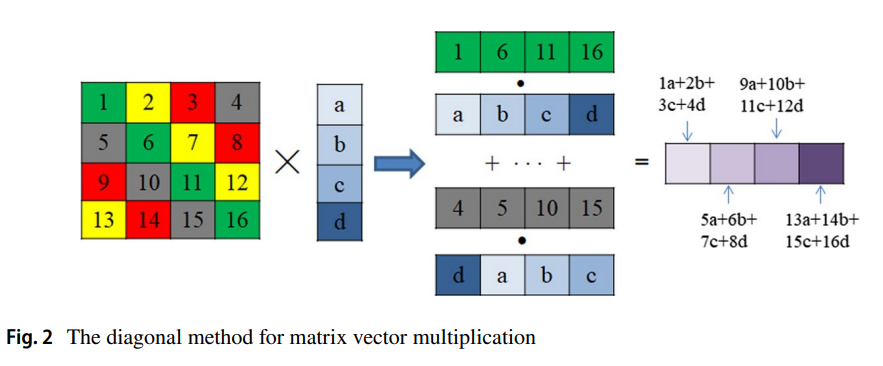

(source : https://doi.org/10.1007/s11227-022-04850-4?urlappend=%3Futm_source%3Dresearchgate.net%26utm_medium%3Darticle). 

Le calcul revient à effectuer : 
$$
\sum_{i=0}^{n-1} diag_{i + r \ mod \ n-1} \odot y^{<(i + r) \ mod \ n-1>}
$$
avec $r$ le nombre de rotation et $diag_{(i+r)_j} = M_{i, (i + r \ mod \ n)}$. 

Nous pouvons nous demander comment allons nous faire ces rotations homomorphiquement. Précédemment, nous avons vu que prendre l'inverse des coefficients permettaient de prendre la conjugaison du vecteur des slots. Pour se faire, notre traitement revenais au même qu'échanger la première moitié de la matrice de décodage avec la deuxième moitié. Pour faire des rotations du vecteur de sortie d'une place à la fois, nous allons avoir besoin d'une méthode plus précise. Tout d'abord, nous avons besoin de changer la matrice d'encodage/décodage pour permettre la rotation homomorphe efficace de notre vecteur chiffré. Nous allons opérer le changement suivant : 
$$
\begin{array}{cc}
\begin{pmatrix}  

1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  

1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\

1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{\frac{n}{2}-1} & (\omega^{\frac{n}{2}-1})^{2} & \cdots & (\omega^{\frac{n}{2}-1})^{n - 1} \\

1 & \omega^{\frac{n}{2}} & (\omega^{\frac{n}{2}})^{2} & \cdots & (\omega^{\frac{n}{2}})^{n - 1} \\

1 & \omega^{\frac{n}{2}+1} & (\omega^{\frac{n}{2}+1})^{2} & \cdots & (\omega^{\frac{n}{2}+1})^{n - 1} \\

1 & \omega^{\frac{n}{2}+2} & (\omega^{\frac{n}{2}+2})^{2} & \cdots & (\omega^{\frac{n}{2}+2})^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}

\end{pmatrix}

\Rightarrow
 
\begin{pmatrix}  

1 & \omega^{J(0)} & \omega^{J(0)^2} & \cdots & \omega^{J(0)^{n - 1}} \\  

1 & \omega^{J(1)} & (\omega^{J(1)})^{2} & \cdots & (\omega^{J(1)})^{n - 1} \\

1 & \omega^{J(2)} & (\omega^{J(1)})^{2} & \cdots & (\omega^{J(1)})^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{J(\frac{n}{2}-1)} & (\omega^{J(\frac{n}{2}-1)})^{2} & \cdots & (\omega^{J(\frac{n}{2}-1)})^{n - 1} \\

1 & \omega^{J_*(0)} & \omega^{J_*(0)^2} & \cdots & \omega^{J_*(0)^{n - 1}} \\ 

1 & \omega^{J_*(1)} & \omega^{J_*(1)^2} & \cdots & \omega^{J_*(1)^{n - 1}} \\ 

1 & \omega^{J_*(2)} & \omega^{J_*(2)^2} & \cdots & \omega^{J_*(2)^{n - 1}} \\ 

\vdots & & \ddots & & \vdots\\

1 & \omega^{J_*(\frac{n}{2}-1)} & \omega^{J_*(\frac{n}{2}-1)^2} & \cdots & \omega^{J_*(\frac{n}{2}-1)^{n - 1}} \\ 

\end{pmatrix}

\end{array}
$$
avec la fonction $J(x) = 5^x \ mod \ 2n$ et $J_*(x) = -5^x \ mod \ 2n$. Il est connu en théorie des nombre que 
ces deux fonctions pour $0 \leq x < \frac{n}{2}$ génèrent l'ensemble des nombres impaires compris entre $[0,2n-1]$. De plus, nous savons que pour $0 \leq x < \frac{n}{2}$, nous avons $J(x) - J_*(x) \equiv 0 \ mod \ 2n$. Dans notre cas, nous souhaitons faire des rotations du vecteur de sortie, en séparant les rotations du vecteur d'entrée, de celle sur son conjugué : 
$$
\begin{array}{cc}
 y' = (y_0, y_1,y_2, \dots, y_n, \overline{y_n}, \overline{y_{n-1}}, \dots, \overline{y_1}, \overline{y_0}) = (y | \text{ reverse order}(\overline{y})) \\
 \downarrow \text{après 1 rotation} \downarrow \\
 (y_1, y_2, \dots, y_n, y_0, \overline{y_{n-1}}, \overline{y_{n-2}}, \dots, \overline{y_{1}}, \overline{y_0}, \overline{y_{n}})
\end{array}
$$
Donc nous voulons en 1 seule opération opérer deux "sous-rotations" à un seul et même vecteur. Intuitivement, il faudra faire une rotations de la première moitié de la matrice d'encodage/décodage et une rotation de la deuxième moitié, pour arriver à deux sous-rotations pour le vecteur de sortie. Cependant, nous ne pouvons qu'appliquer une transformation unique à l'ensemble du vecteur, et donc de la matrice. Les transformations $J(x)$ et $J_*(x)$ sont pratique car elles permettent de facilement séparés en deux le calcul des racines unités de la matrice. Donc on peut facilement faire apparaître deux blocs, sur lesquels une même opération n'aura le même résultat, car initialement définies différemment. De plus, les deux fonctions sont cycliques. Par conséquent, en augmentant $x$, nous sommes assurés de retombé sur un autre élément du même bloc. Le premier élément du premier bloc est défini par $\omega^{J(0)}$, puis le deuxième élément est défini par $\omega^{J(1)}$ et ainsi de suite. Donc pour faire une rotation des lignes, il suffit de passer de
$$
\begin{array}{cc}
J(0) \rightarrow J(1) \\
J(1) \rightarrow J(2) \\
\vdots \\
J(\frac{n}{2}-1) \rightarrow J(0) \\
\end{array}
$$
soit 
$$
\begin{array}{cc}
5^0 \ mod \ 2n \rightarrow 5^1 \ mod \ 2n \\
5^1 \ mod \ 2n \rightarrow 5^2 \ mod \ 2n \\
\vdots \\
5^{\frac{n}{2}-1} \ mod \ 2n \rightarrow 5^0 \ mod \ 2n \\
\end{array}
$$

Lorsque nous effectuerons la rotations, nous disposerons déjà du vecteur. Par conséquent, nous cherchons la transformation $\omega^{J(x)}$ vers $\omega^{J(x+1)}$ en partant de $(\omega^{J(x)})$ (et réciproquement a transformation $\omega^{J_*(x)}$ vers $\omega^{J_*(x+1)}$ en partant de $(\omega^{J_*(x)})$). En replaçant $J$, nous avons : 
$$
\begin{array}{cc}
(\omega^{J(x)}) = (\omega^{5^x \ mod \ 2n}) \\
(\omega^{J(x)}) = (\omega^{5^x \ mod \ 2n}) \rightarrow \omega^{J(x+1)} = (\omega^{5^{x+1} \ mod \ 2n}) \\
(\omega^{J(x)})^5 = (\omega^{5J(x)}) = (\omega^{5(5^x \ mod \ 2n)}) = (\omega^{(5^{x+1} \ mod \ 2n)})  \\
\end{array}
$$
Et pour $J_*$ nous avons : 
$$
\begin{array}{cc}
(\omega^{J_*(x)}) = (\omega^{-5^x \ mod \ 2n}) \\
(\omega^{J_*(x)}) = (\omega^{-5^x \ mod \ 2n}) \rightarrow \omega^{J_*(x+1)} = (\omega^{-5^{x+1} \ mod \ 2n}) \\
(\omega^{J_*(x)})^5 = (\omega^{5J_*(x)}) = (\omega^{5(-5^x \ mod \ 2n)}) = (\omega^{(-5^{x+1} \ mod \ 2n)})  \\
\end{array}
$$
Ainsi, pour effectuer une rotation, il suffit de prendre la puissance $5$. Pour faire deux rotations, il suffit de passer à la puissance $5^2$… Comme nous travaillons avec les $2n$-e racines unités impaires, nous avons la relations $\omega^k = \omega^{l}$ si $k \equiv l \ mod \ 2n$. De cette façon, le passage de $J(\frac{n}{2} - 1) \rightarrow J(0)$ se fait naturellement Par exemple, pour une rotation, nous avons 
$$
\begin{array}{cc}
J(\frac{n}{2} - 1) \rightarrow J(0) \\
\omega^{5^{\frac{n}{2} - 1}} \rightarrow \omega^{5^0} \\
(\omega^{5^{\frac{n}{2} - 1}})^5 = \omega^{5^{\frac{n}2{}}}
\end{array}
$$

Cependant, nos rotations doivent boucler après $\frac{n}{2}-1$, $(\omega^{J(\frac{n}{2}-1)}) = (\omega^{5^{\frac{n}{2}-1} \ mod \ 2n}) \rightarrow \omega^{J(0)} = (\omega^{5^{0} \ mod \ 2n})$ donc qui pour $\omega^{\frac{n}{2}}$ ressort $\omega^1$, donc $\frac{n}{2} \equiv 0 \ mod \ \frac{n}{2}$. 
A nouveau, un résultat de théorie des nombres nous indiquant que $5^{\frac{n}{2}} \equiv 1 \ mod \ 2n$. 
Au final, pour opérer $h$ rotations, nous appliquons simplement $\cdot^{J(h)}$ au élément du vecteur. 
Comme lors de la conjugaison, nous allons aussi devoir réaliser un changement de clé pour que le ciphertext se déchiffre à nouveau avec la clé privée de l'utilisateur, nous souhaitons passer de la clé $S^{J(h)}$ à $S$ : 
$$
\begin{array}{cc}
Encryption(\Delta m)_S = (0, B^{J(h)}) + \langle Decomp^{\beta,\ell}(A^{J(h)}), RLev_S(S^{J(h)}) \rangle
\end{array}
$$
Par conséquent, l'utilisateur aura aussi besoin de nous envoyer au préalable un ensemble de clés de rotation, une décomposition de clé de rotation pour chaque possibilité de rotation dont nous aurons besoin. 

Il faut se rappeler que nous souhaitons effectuer les opérations homomorphiquement. Par conséquent, $\cdot^{J(h)}$ ne sera pas appliquer au vecteur encodé, mais au vecteur chiffré. Nous procéderons de manière similaire à l'inversion utilisée pour la conjugaison du vecteur de sortie, d'abord le passage à la puissance, puis le changement de clé pour revenir à un ciphertext qui se déchiffre avec la clé initiale. 

Il est à noter que nous modifions la matrice d'encodage/décodage comme suit 
$$
\begin{array}{cc}
\begin{pmatrix}  

1 & \omega & \omega^{2} & \cdots & \omega^{n - 1} \\  

1 & \omega^3 & (\omega^{3})^{2} & \cdots & (\omega^3)^{n - 1} \\

1 & \omega^5 & (\omega^{5})^{2} & \cdots & (\omega^5)^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{\frac{n}{2}-1} & (\omega^{\frac{n}{2}-1})^{2} & \cdots & (\omega^{\frac{n}{2}-1})^{n - 1} \\

1 & \omega^{\frac{n}{2}} & (\omega^{\frac{n}{2}})^{2} & \cdots & (\omega^{\frac{n}{2}})^{n - 1} \\

1 & \omega^{\frac{n}{2}+1} & (\omega^{\frac{n}{2}+1})^{2} & \cdots & (\omega^{\frac{n}{2}+1})^{n - 1} \\

1 & \omega^{\frac{n}{2}+2} & (\omega^{\frac{n}{2}+2})^{2} & \cdots & (\omega^{\frac{n}{2}+2})^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{2n-1} & (\omega^{2n-1})^{2} & \cdots & (\omega^{2n-1})^{n - 1}

\end{pmatrix}

\Rightarrow
 
\begin{pmatrix}  

1 & \omega^{J(0)} & \omega^{J(0)^2} & \cdots & \omega^{J(0)^{n - 1}} \\  

1 & \omega^{J(1)} & (\omega^{J(1)})^{2} & \cdots & (\omega^{J(1)})^{n - 1} \\

1 & \omega^{J(2)} & (\omega^{J(1)})^{2} & \cdots & (\omega^{J(1)})^{n - 1} \\

\vdots & & \ddots & & \vdots\\

1 & \omega^{J(\frac{n}{2}-1)} & (\omega^{J(\frac{n}{2}-1)})^{2} & \cdots & (\omega^{J(\frac{n}{2}-1)})^{n - 1} \\

1 & \omega^{J_*(0)} & \omega^{J_*(0)^2} & \cdots & \omega^{J_*(0)^{n - 1}} \\ 

1 & \omega^{J_*(1)} & \omega^{J_*(1)^2} & \cdots & \omega^{J_*(1)^{n - 1}} \\ 

1 & \omega^{J_*(2)} & \omega^{J_*(2)^2} & \cdots & \omega^{J_*(2)^{n - 1}} \\ 

\vdots & & \ddots & & \vdots\\

1 & \omega^{J_*(\frac{n}{2}-1)} & \omega^{J_*(\frac{n}{2}-1)^2} & \cdots & \omega^{J_*(\frac{n}{2}-1)^{n - 1}} \\ 

\end{pmatrix}
\end{array}
$$
Tout d'abord, la matrice reste une base d'encodage valide, car nous nous contentons de réarranger l'ordre des lignes. Ensuite, cela modifie la relation que nous avions $V^{-1} = \frac{V^T \cdot I_n^R}{n}$. En effet, le changement d'ordre des lignes impacte la reversal matrice, qui pouvait auparavant être définie via $V \cdot V^T = n \cdot I^R_n$, et qui sera toujours définie par la même relation $\tilde{V} \cdot \tilde{V^T} = n \cdot I^R_n$, mais ne donnera pas le même résultat, les lignes ne seront pas placées dans le même ordre. 

Nous savons maintenant comment nous pouvons faire des rotations du vecteur $y$. Grâce à cela et la méthode diagonale pour la multiplication matrice-vecteur, nous pouvons élaborer une méthode permettant de faire la multiplication matrice-vecteur homomorphiquement. 

Contrairement à la méthode diagonale classique, les rotations sur le vecteur $y$ ne sont pas, dans notre cas, circulante sur l'ensemble, mais sur chacune des deux sous parties : 
$$
\begin{array}{cc}
\begin{pmatrix}
y_0 \\
y_1 \\
\vdots \\
y_{\frac{n}{2}-1} \\
\overline{y_0} \\
\overline{y_1} \\
\vdots \\
\overline{y_{\frac{n}{2}-1}}
\end{pmatrix} 
\Rightarrow 
\begin{pmatrix}
y_1 \\
y_2 \\
\vdots \\
y_0 \\
\overline{y_1} \\
\overline{y_2} \\
\vdots \\
\overline{y_0}
\end{pmatrix} 
\Rightarrow 
\begin{pmatrix}
y_2 \\
y_3 \\
\vdots \\
y_1 \\
\overline{y_2} \\
\overline{y_3} \\
\vdots \\
\overline{y_1}
\end{pmatrix} 
\Rightarrow \dots
\end{array}
$$
Ainsi un élément $y_i$ après $r$ rotations, se place en position
- $y_{(i + r \ mod \ \frac{n}{2})}$ pour $i < \frac{n}{2}$  
- $y_{\frac{n}{2} + (i + r mod \frac{n}{2}  )}$ pour $i \ge \frac{n}{2}$ 
Ici, $y_i$ se réfère simplement au $i$ élément du vecteur total, il n'est pas question de conjugaison. 

Avec ces ajustement, nous obtenons la nouvelle formule : 
$$
\sum_{i=0}^{n-1} diag_{i + r \ mod \ n-1} \odot y^{<(i + r) \ mod \ n-1>}
$$
avec $diag_{i + r \ mod \ n-1} \left\{\begin{array}{ll} M_{i, i + r \ mod \ \frac{n}{2}  } \text{ si } i < \frac{n}{2} \\ M_{i, \frac{n}{2} + (i + r \ mod \ \frac{n}{2}  )} \text{ si } i \ge \frac{n}{2}   \end{array} \right.$  

et    $y^{<(i + r) \ mod \ n-1>} \left\{ \begin{array}{ll} y_{i + r \ mod \ \frac{n}{2}  } \text{ si } i < \frac{n}{2} \\ y_{\frac{n}{2} + (i + r \ mod \ \frac{n}{2})} \text{ si } i \ge \frac{n}{2} \end{array}\right.$ 

Cependant, cette formule ne suffit pas à calculer l'entièreté de la multiplication matrice-vecteur. En effet, les éléments $M_{i,j}$ pour $i < \frac{n}{2}, j \ge \frac{n}{2}$ et pour $i \ge \frac{n}{2}, j < \frac{n}{2}$ ne sont jamais visités. Ils ne peuvent pas l'être car ils sont censés multipliés respectivement la partie conjugués et non conjugués de nos slots alors que notre vecteur se présent comme $y = (\text{non conjugué, conjugué})$. Donc nous allons avoir besoin du vecteur $\overline{y}=(\text{conjugué, non conjugué})$. De cette façon, nous pourrons reprendre la même formule mais en multipliant cette fois-ci le vecteur conjugué : 
$$
\sum_{i=0}^{n-1} diag_{i + r \ mod \ n-1} \odot \overline{y^{<(i + r) \ mod \ n-1>}}
$$
toujours avec 
avec $diag_{i + r \ mod \ n-1} \left\{\begin{array}{ll} M_{i, i + r \ mod \ \frac{n}{2}  } \text{ si } i \ge \frac{n}{2} \\ M_{i, \frac{n}{2} + (i + r \ mod \ \frac{n}{2}  )} \text{ si } i < \frac{n}{2}   \end{array} \right.$  

et    $y^{<(i + r) \ mod \ n-1>} \left\{ \begin{array}{ll} y_{i + r \ mod \ \frac{n}{2}  } \text{ si } i < \frac{n}{2} \\ y_{\frac{n}{2} + (i + r \ mod \ \frac{n}{2})} \text{ si } i \ge \frac{n}{2} \end{array}\right.$ 


Pour illustrer, la première formule visite les valeurs en rouges dans le calcul suivant : 
$$\begin{array}{cc}
\begin{pmatrix}
\textcolor{red}{1} & \textcolor{red}{1} & \textcolor{red}{1} & \textcolor{red}{\cdots} & \cdots & \cdots & 1 & 1 \\
\textcolor{red}{\omega^{1}} & \textcolor{red}{\omega^{3^{1}}} & \textcolor{red}{\omega^{5^{1}}} & \textcolor{red}{\cdots} & \cdots & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \vdots & \vdots & \vdots & \vdots \\ 
\textcolor{red}{\omega^{\frac{n}{2}-1}} & \textcolor{red}{\omega^{3^{\frac{n}{2}-1}}} & \textcolor{red}{\omega^{5^{\frac{n}{2}-1}} }& \textcolor{red}{\cdots} & \cdots & \cdots &  \omega^{(2n-3)^{\frac{n}{2}-1}} & \omega^{(2n-1)^{\frac{n}{2}-1}} \\
\omega^{\frac{n}{2}} & \omega^{3^{\frac{n}{2}}} & \omega^{5^{\frac{n}{2}}} & \cdots & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{\frac{n}{2}}}} & \textcolor{red}{\omega^{(2n-1)^{\frac{n}{2}}}} \\
\omega^{\frac{n}{2}+1} & \omega^{3^{\frac{n}{2}+1}} & \omega^{5^{\frac{n}{2}+1}} & \cdots & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{\frac{n}{2}+1}}} & \textcolor{red}{\omega^{(2n-1)^{\frac{n}{2}+1}}} \\
\vdots & \vdots & \vdots & \vdots & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{n-1}}} & \textcolor{red}{\omega^{(2n-1)^{n-1}}} \\
\end{pmatrix}^{-1} \cdot \
\begin{pmatrix}
y_0 \\
y_1 \\
\vdots \\
y_{\frac{n}{2}-1} \\
\overline{y_0} \\
\overline{y_1} \\
\vdots \\
\overline{y_{\frac{n}{2}-1}}
\end{pmatrix}
\end{array}
$$
Et la deuxième formule visite les valeurs en noires : 
$$
\begin{array}{cc}
\begin{pmatrix}
\textcolor{red}{1} & \textcolor{red}{1} & \textcolor{red}{1} & \textcolor{red}{\cdots} & \cdots & \cdots & 1 & 1 \\
\textcolor{red}{\omega^{1}} & \textcolor{red}{\omega^{3^{1}}} & \textcolor{red}{\omega^{5^{1}}} & \textcolor{red}{\cdots} & \cdots & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \vdots & \vdots & \vdots & \vdots \\ 
\textcolor{red}{\omega^{\frac{n}{2}-1}} & \textcolor{red}{\omega^{3^{\frac{n}{2}-1}}} & \textcolor{red}{\omega^{5^{\frac{n}{2}-1}} }& \textcolor{red}{\cdots} & \cdots & \cdots &  \omega^{(2n-3)^{\frac{n}{2}-1}} & \omega^{(2n-1)^{\frac{n}{2}-1}} \\
\omega^{\frac{n}{2}} & \omega^{3^{\frac{n}{2}}} & \omega^{5^{\frac{n}{2}}} & \cdots & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{\frac{n}{2}}}} & \textcolor{red}{\omega^{(2n-1)^{\frac{n}{2}}}} \\
\omega^{\frac{n}{2}+1} & \omega^{3^{\frac{n}{2}+1}} & \omega^{5^{\frac{n}{2}+1}} & \cdots & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{\frac{n}{2}+1}}} & \textcolor{red}{\omega^{(2n-1)^{\frac{n}{2}+1}}} \\
\vdots & \vdots & \vdots & \vdots & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} & \textcolor{red}{\vdots} \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\cdots} & \textcolor{red}{\omega^{(2n-3)^{n-1}}} & \textcolor{red}{\omega^{(2n-1)^{n-1}}} \\
\end{pmatrix}^{-1} \cdot \
\begin{pmatrix}
\overline{y_0} \\
\overline{y_1} \\
\vdots \\
\overline{y_{\frac{n}{2}-1}} \\
y_0 \\
y_1 \\
\vdots \\
y_{\frac{n}{2}-1}
\end{pmatrix}
\end{array}
$$
En sommant les deux résultats obtenus, nous obtenus le résultat de la multiplication matrice vecteur : 
$$
V^{T^{-1}}y = \sum_{i=0}^{n-1} diag_{i + r \ mod \ n-1} \odot y^{<(i + r) \ mod \ n-1>} +  diag^{\text(conj)}_{i + r \ mod \ n-1} \odot \overline{y^{<(i + r) \ mod \ n-1>}}
$$
Donc pour faire notre multiplication $V^-1 \cdot (y, \overline{y})$, nous avons besoin de construire $\frac{n}{2}$ diagonales qui multiplieront des rotations de $(y, \overline{y})$, et construire $\frac{n}{2}$ diagonales qui multiplieront des rotations de $(\overline{y}, y)$. 
Un autre point est de que nous ne pouvons pas encoder directement les diagonales en l'état : Chaque diagonale est de dimension $N$ avant encodage, alors que notre schéma ne prend que des entrée de taille $N/2$. Nous pouvons représenter notre méthode diagonale comme réalisant le calcul suivant : 
$$
\begin{array}{cc}
V^{{-1}} \cdot Dec(c) = V^{{-1}} \cdot (y_0, \dots, y_{\frac{n}{2}-1}, \overline{y_0}, \dots, \overline{y_{\frac{n}{2}-1}})^T \\
\begin{pmatrix}
1 & 1 & 1 & \cdots & 1 & 1 \\
\omega^{1} & \omega^{3^{1}} & \omega^{5^{1}} & \cdots & \omega^{(2n-3)^{1}} & \omega^{(2n-1)^{1}} \\
\omega^{2} & \omega^{3^{2}} & \omega^{5^{2}} & \cdots & \omega^{(2n-3)^{2}} & \omega^{(2n-1)^{2}} \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\ 
\omega^{n-1} & \omega^{3^{n-1}} & \omega^{5^{n-1}} & \cdots & \omega^{(2n-3)^{n-1}} & \omega^{(2n-1)^{n-1}} \\
\end{pmatrix}^{-1} \cdot \
\begin{pmatrix}
y_0 \\
\vdots \\
y_{\frac{n}{2}-1} \\
\overline{y_0} \\
\vdots \\
\overline{y_{\frac{n}{2}-1}}
\end{pmatrix} \\
= \begin{pmatrix}
\textcolor{red}{A} & 0 \\
0 & \textcolor{red}{D}
\end{pmatrix} 
\cdot 
\begin{pmatrix}
y \\
\overline{y}
\end{pmatrix}
+
\begin{pmatrix}
\textcolor{red}{0} & B \\
C & \textcolor{red}{0}
\end{pmatrix} 
\cdot 
\begin{pmatrix}
\overline{y} \\
y
\end{pmatrix}
\end{array}
$$
Chaque bloc $A,B,C,D$ sont de taille $\frac{n}{2}  \times \frac{n}{2}$. En acceptant que le résultat soit en deux blocs distincts, nous pouvons calculer les résultats comme suit : 
$$
\begin{array}{cc}
ct_{slot_1} = \textcolor{red}{A}y + B\overline{y} \\
ct_{slot_2} = Cy + \textcolor{red}{D}\overline{y}
\end{array}
$$
Pour rappel, $A,B,C,D$ sont issues de $V^{{-1}} = \frac{V^T \times I^R_n}{n}$, ce qui nous donne : 
$$
\begin{array}{cc}
ct_{slot_1} = \frac{V^T_{\textcolor{red}{A}} \cdot I^R_{\frac{n}{2}} \cdot y + V^T_B \cdot I^R_{\frac{n}{2}} \cdot\overline{y}}{n}\\
ct_{slot_2} = \frac{V^T_B \times I^R_{\frac{n}{2}} \cdot y + V^T_{\textcolor{red}{D}} \times I^R_{\frac{n}{2}} \cdot \overline{y}}{n}
\end{array}
$$
Chaque bloc $V_x$ est constitué de $\frac{n}{2}$ vecteurs de taille $\frac{n}{2}$ donc nous pouvons les encodés, les multipliés terme à terme avec le vecteur après rotation $c, \overline{c}$ correspondant, puis sommer les résultats pour le bloc et avec le bloc correspondant. 

Pour conjugué le vecteur des slots homomorphiquement, nous avons vu précédemment qu'il suffit de prendre l'inverse de $c(X)$, soit $c(X^{-1)})$.

Au final, pour faire la multiplication matricielle en homomorphe, nous aurons besoin d'effectuer $n^2$ multiplications, $n/2$ par vecteur et il y a $2n$ vecteurs, et $2n-2$ additions, ainsi que $n$ rotations Nous utilisons un seul niveau de profondeur multiplicative, car toutes les multiplications s'effectuent en parallèle. 

Nous nous retrouvons avec les coefficients dans les slots. Nous pouvons maintenant appliquer notre fonction sinus de façon homomorphe : 
$$
\begin{array}{|c|c|c|}
\hline
\text{Slots values} & \text{Cipher values} & \text{Plaintext} \\
\hline
{(y, \overline{y})} & (A, -AS + \Delta m + e) & \Delta m + e \\
\Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow \\
(y, \overline{y}) + Ki(x)q_0 & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) & \Delta m + e + K''(x)q_0 \\
\Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically}\Downarrow \\
\Delta m + e + K''(x)q_0  & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) * Encoding(V^{-1}) & \Delta m + e + K''(x)q_0 \cdot V^{-1} \\
\Downarrow f(x) \text{ homomorphically} \Downarrow & \Downarrow f(x) \text{ homomorphically} \Downarrow & \Downarrow f(x) \text{ homomorphically}\Downarrow \\
\Delta m + e & Encoding(f)((A + K(x)q_0, -AS + \Delta m + e + K'(x)) * Encoding(V^{-1})) & f()\Delta m + e + K''(x)q_0 \cdot V^{-1} \\
\hline
\end{array}
$$
A présent que nous nous sommes débarasser des résidus du ModRaise, nous aimerions à nouveau avoir nos inputs dans les slots values, et nos coefficients en plaintext values. Il faut donc faire l'opération inverse, $V$ : 
$$
\begin{array}{|c|c|c|}
\hline
\text{Slots values} & \text{Cipher values} & \text{Plaintext} \\
\hline
{(y, \overline{y})} & (A, -AS + \Delta m + e) \ mod \ q_0 & \Delta m + e  \ mod \ q_0 \\
\Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow & \Downarrow \text{ModRaise} \Downarrow \\
(y, \overline{y}) + Ki(x)q_0 & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) & \Delta m + e + K''(x)q_0 \\
\Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically} \Downarrow & \Downarrow \cdot V^{-1}\text{ homomorphically}\Downarrow \\
\Delta m + e + K''(x)q_0  & (A + K(x)q_0, -AS + \Delta m + e + K'(x)) * Encoding(V^{-1}) & \Delta m + e + K''(x)q_0 \cdot V^{-1} \\
\Downarrow f(x) \text{ homomorphically} \Downarrow & \Downarrow f(x) \text{ homomorphically} \Downarrow & \Downarrow f(x) \text{ homomorphically}\Downarrow \\
\Delta m + e & Encoding(f)((A + K(x)q_0, -AS + \Delta m + e + K'(x)) * Encoding(V^{-1})) & f()\Delta m + e + K''(x)q_0 \cdot V^{-1} \\
\Downarrow \cdot V\text{ homomorphically} \Downarrow & \Downarrow \cdot V\text{ homomorphically} \Downarrow & \Downarrow \cdot V\text{ homomorphically}\Downarrow \\
{(y, \overline{y})} & (A, -AS + \Delta m + e)  \ mod \ q_L & \Delta m + e  \ mod \ q_L \\
\hline
\end{array}
$$

Dans la littérature, l'étape de passer les coefficients dans les slots se nomment $\text{CoeftoSlot}$, son inverse se nomme $\text{SlottoCoef}$ et l'étape de nettoyage du résidus se nomme $\text{EvalExp}$. 

Finalement le boostrapping s'effectue en 4 étapes : 
- ModRaise
- CoeftoSlot
- EvalExp + ImagExt
- SlottoCoeff

Nous allons commencer par modifier nos fonctions d'encodage et de décodage pour permettre la rotation des vecteurs 

## Démonstration

### Encodage permettant les rotations

In [77]:
# Matrice d'encodage permettant la rotation des vecteurs 
def helper_func_j (i, n) : 
    return (5**(i)) % (2*n)

def helper_func_minus_j (i, n) : 
    return (-5**(i)) % (2*n)

In [78]:
def CKKS_Encoding_with_rotation(m, Delta, q=None): 
    n_div_2 = len(m)
    if (n_div_2 & (n_div_2 - 1)) != 0 : 
        n_div_2 = 1 << (n_div_2 - 1).bit_length()
        m = np.concatenate((m, np.zeros(n_div_2 - len(m))), axis=0)
    m_and_conj = np.concatenate((m, m.conjugate()), axis=0)
    n = n_div_2*2
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=object) # Pour en faire une matrice de type complexe. 
    for ligne in range(n//2):
        for col in range(n): 
            V[ligne, col] = (w**(helper_func_j(ligne, n)))**col
            V[ligne + n//2, col] = (w**(helper_func_minus_j(ligne, n)))**col

    reversal_matrix_rotation = np.array(
    [[int(round(v.real)) for v in row]
     for row in (V @ V.T) / n],
    dtype=object
    )

    m_encoded_as_pol = (V.T @ reversal_matrix_rotation)/n @ m_and_conj

    m_encoded_as_pol_appr = check_ckks_imag(v_encoded_as_pol=m_encoded_as_pol)

    m_int_encoded_as_pol_appr = np.array(
        [int(round(Delta * x)) for x in m_encoded_as_pol_appr],
        dtype=object
    )
    return m_int_encoded_as_pol_appr

In [79]:
def CKKS_decoding_with_rotation(m_encoded, Delta):
    n = len(m_encoded)
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(n//2):
        for col in range(n): 
            V[ligne, col] = (w**(helper_func_j(ligne, n)))**col
            V[ligne + n//2, col] = (w**(helper_func_minus_j(ligne, n)))**col
    y_estimated = V @ (1/Delta * m_encoded)
    return (y_estimated[0:(n//2)])

In [80]:
list_of_inputs = []
list_of_encrypted_inputs = []
for i in range(nb_mult+1): 
    y = (np.round(np.random.randn(1, n//2), 2)*0.9 + (np.round(np.random.randint(-1,1, size=(1,n//2))*(1j), 2)))[0]
    list_of_inputs.append(y)
    list_of_encrypted_inputs.append(
        CKKS_Encryption(
            m_encoded=CKKS_Encoding_with_rotation(
                m=y, Delta=Delta, q=q
            ), q=q, S=S
        )
    )

In [81]:
intial_combine_cipher = list_of_encrypted_inputs[-1]
q_for_mult = q
for i in range(nb_mult):
    print(f"{i+1}e multiplication")
    combine_cipher_final, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication
6e multiplication
7e multiplication
8e multiplication
9e multiplication
10e multiplication
11e multiplication
12e multiplication
13e multiplication
14e multiplication
15e multiplication
16e multiplication
17e multiplication
18e multiplication
19e multiplication
20e multiplication
21e multiplication
22e multiplication
23e multiplication
24e multiplication
25e multiplication
26e multiplication
27e multiplication
28e multiplication
29e multiplication
30e multiplication


In [82]:
CKKS_mult_func_decoded = CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_for_mult
        ), q=q_for_mult
    ),Delta=Delta
)

expected_result = 1
for i in range(nb_mult+1): 
    expected_result = expected_result * list_of_inputs[i]

In [83]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {error_real_part * 100 / (np.abs(expected_result.real)+0.000000001)} (%)\n"
    f"{'Partie imaginaire':<26} : {error_imag_part * 100 / (np.abs(expected_result.imag)+0.00000001)} (%)"
)

CKKS mult function decoded : [(0.6568865471445604-4.0787890613348985j) (-0.0016333998051871745-0.00845831745061898j)]
Expected result            : [ 0.65688655-4.07878906j -0.0016334 -0.00845832j]
Erreur de précision        : [(2.808864252301646e-14+1.1457501614131615e-13j) (-1.6128591517894364e-15+1.8561541192951836e-16j)]
Erreur de précision (%)
Partie réelle              : [ 4.27602645e-12 -9.87423997e-11] (%)
Partie imaginaire          : [2.80904489e-12 2.19446945e-12] (%)


### ModRaise

Pour augmenter le modulus, il nous suffit de l'augmenter artificillement. Cela fera apparaître un résidu $kq_0$ qui sera retiré lors de l'étape EvalExp. 

Nous pouvons étudier l'impact du ModRaising en étudiant directement les coefficients (et non les valeurs dans les slots). Ainsi, intialement nous devrions avoir les coefficients $\Delta m + e$, et après ModRaising, ils passeront à $\Delta m + e + K(X)q_0$.

In [84]:
print(expected_result, erreur_precision, sep="\n")

[ 0.65688655-4.07878906j -0.0016334 -0.00845832j]
[(2.808864252301646e-14+1.1457501614131615e-13j) (-1.6128591517894364e-15+1.8561541192951836e-16j)]


In [85]:
# Récupération des coefficients "propres" avant ModRaising 
coef_before_modraising = modulus_centering(
    CKKS_Decryption(
        combine_cipher_final,
        S=S, 
        Delta=Delta,
        q=q_0
    ), q=q_0
) 
coef_before_modraising

array([32762657366968718958, -120625727531894362997, -204362368939275879648, -167190119535371436657], dtype=object)

In [86]:
# Récupération des coefficients avec le résidus ajouté par ModRaising 
coef_after_modraising = modulus_centering(
    CKKS_Decryption(
        combine_cipher_final,
        S=S, 
        Delta=Delta,
        q=q
    ), q=q
) 
coef_after_modraising

array([10000032762657366968718958, -120625727531894362997, -10000204362368939275879648, -20000167190119535371436657], dtype=object)

En soustrayant le ciphertext avec élévation du module à celui avant élévation, il ne devrait rester que le résidu $K(X)q_0$. 

In [87]:
facteur_mod_raised = (coef_after_modraising - coef_before_modraising) // q_0
facteur_mod_raised

array([1, 0, -1, -2], dtype=object)

Nous pouvons constater que c'est bien le cas. La différence entre les deux ciphertext est uniquement une différence d'un multiple de $q_0$ sur chaque coefficient. Ici, cela nous paraît simple de le retirer. C'est normal, nous avons pu déchiffrer nos messages pour les comparer. En contexte réel, les messages sont chiffrés, donc il est impossible de les comparer et d'obtenir une différence de mutiple de $q_0$ qu'on pourrait ensuite venir retirer. A la place nous utilisons une fonction qui retire un éventail de mutiple de $q_0$ tant que les hypothèses de départ sont respectées. 

### CoeftoSlot

Nous allons à présenter multiplier les slots par $V^{-1}$ de façon homomorphe pour que les valeurs en slots ne soient plus le message mais les coefficients. Nous allons commencer par créer les 4 sous-blocs de la matrices $V^{-1}$. Ensuite nous allons encoder les différentes diagonales de chaunes de ces sous-matrices.

In [88]:
# Calcul de V^-1 
w = np.exp(1j * np.pi / n)
V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
for ligne in range(n//2):
    for col in range(n): 
        V[ligne, col] = (w**(helper_func_j(ligne, n)))**col
        V[ligne + n//2, col] = (w**(helper_func_minus_j(ligne, n)))**col
V = np.round(V, 14)
reversal_matrix_rotation = np.array(
    [[int(round(v)) for v in row]
     for row in ((V @ V.T)/n).real],
    dtype=object
)
V_for_diag = (V.T @ reversal_matrix_rotation)/n

In [89]:
def construct_encoded_diags_from_block(V_for_diag, Delta): 
    n = V_for_diag.shape[0]
    # Extraction des 4 sous-blocs
    A_block =  V_for_diag[:(n//2), :(n//2)]
    B_block = V_for_diag[:(n//2), (n//2):]
    C_block =  V_for_diag[(n//2):, :(n//2)]
    D_block = V_for_diag[(n//2):, (n//2):]

    # Construction des diagonales pour chaque bloc 
    list_of_diags_A_block = []
    list_of_diags_B_block = []
    list_of_diags_C_block = []
    list_of_diags_D_block = []

    for r in range(n//2): 
        diag_A_bloc = []
        diag_B_bloc = []
        diag_C_bloc = []
        diag_D_bloc = []
        for i in range(n//2):
            diag_A_bloc.append(A_block[i, (i + r) % (n//2)])
            diag_B_bloc.append(B_block[i, (i + r) % (n//2)])
            diag_C_bloc.append(C_block[i, (i + r) % (n//2)])
            diag_D_bloc.append(D_block[i, (i + r) % (n//2)])

        list_of_diags_A_block.append(CKKS_Encoding_with_rotation(m=np.array(diag_A_bloc, dtype=object), Delta=Delta))
        list_of_diags_B_block.append(CKKS_Encoding_with_rotation(m=np.array(diag_B_bloc, dtype=object), Delta=Delta))
        list_of_diags_C_block.append(CKKS_Encoding_with_rotation(m=np.array(diag_C_bloc, dtype=object), Delta=Delta))
        list_of_diags_D_block.append(CKKS_Encoding_with_rotation(m=np.array(diag_D_bloc, dtype=object), Delta=Delta))

    return list_of_diags_A_block, list_of_diags_B_block, list_of_diags_C_block, list_of_diags_D_block

In [90]:
list_of_diags_A_block, list_of_diags_B_block, list_of_diags_C_block, list_of_diags_D_block = construct_encoded_diags_from_block(V_for_diag, Delta=Delta)

Pour réaliser la mutiplication vecteur-matrice, nous passons par la méthode diagonale. Donc nous avons besoin de stocker chaque rotation possible de notre vecteur chiffré. Pour faire une rotation d'un vecteur chiffré, nous avons besoin de générer des clés de rotation, qui dans un contexte réel sont envoyés par l'utiliseur et donc généré avant tout traitement des valeurs chiffrées. 

In [91]:
def generate_rotation_keys(rotation, S, q, decomp_factors_beta): 
    list_of_S_powered_Encr = []
    n = len(S)
    S_powered = np.zeros(shape=(n),dtype=object)
    # Crer S^h
    for j in range(n): 
        coef = S[j]
        power_of_coef = (j*(helper_func_j(rotation, n))) % (2*n)
        if power_of_coef >= n : 
            sign = -1
            power_of_coef = power_of_coef - n 
        else : 
            sign = 1
        S_powered[power_of_coef] += sign * coef 

    for i, decomp_factor in enumerate(decomp_factors_beta) :
        list_of_S_powered_Encr.append(
            CKKS_Encryption(
                m_encoded= mod_for_arb_int(decomp_factor*S_powered, q),
                q = q, 
                S = S
            )
        )

    return list_of_S_powered_Encr

In [92]:
def key_switching(list_of_prev_keys_encr, cipher_prev_key, decomp_factors_beta, q): 
    ell = len(decomp_factors_beta)

    A_powered = cipher_prev_key[0]
    B_powered = cipher_prev_key[1]
    B_powered_ciph = np.array(([0]*n,B_powered), dtype=object)

    recomp_part = np.array(
    [
        [0 for _ in range(n)],
        [0 for _ in range(n)]
    ],
    dtype=object
    )
    
    A_powered_factors = compute_D_2_factors(D_2=A_powered, decomp_factors_beta=decomp_factors_beta)

    # Pour chaque facteur decomposé 
    for i in range(ell): 
        # Pour chaque partie du ciphertext (soit A et B)
        for j in range(len(list_of_prev_keys_encr[i])):
            recomp_part[j] += poly_mutl_mod(A_powered_factors[i], list_of_prev_keys_encr[i][j], q)

    recomp_part = np.array([
        mod_for_arb_int(recomp_part[0], q), 
        mod_for_arb_int(recomp_part[1], q)
        ]
    )

    key_switched_cipher = CKKS_addition_ct(
        Encr_m_i=recomp_part, 
        Encr_m_j=B_powered_ciph, 
        q=q
    )

    return key_switched_cipher

In [93]:
def rotate_cipher(Encr_m, rotation, list_of_S_powered_Encr, decomp_factors_beta, q): 
    n = Encr_m.shape[1]
    # Rotation via J(h) 
    Encr_m_rotated = np.zeros(shape=(2, n),dtype=object)
    for i, cipher in enumerate(Encr_m):
        for j in range(n): 
            coef = cipher[j]
            power_of_coef = (j*(helper_func_j(i=rotation, n=n))) % (2*n)
            if power_of_coef >= n : 
                sign = -1
                power_of_coef = power_of_coef - n 
            else : 
                sign = 1
            Encr_m_rotated[i][power_of_coef] += (sign * coef) % q 

    rotated_cipher = key_switching(
        list_of_prev_keys_encr=list_of_S_powered_Encr, 
        cipher_prev_key=Encr_m_rotated, 
        decomp_factors_beta=decomp_factors_beta, 
        q=q
    )

    return rotated_cipher

Nous allons aussi avoir besoin de conjugué notre ciphertext pour réaliser l'ensemble des opérations à faire dans le cadre de la méthode diagonale. 

In [94]:
def generate_inversion_keys(S, q, decomp_factors_beta): 
    list_of_S_inv_Encr = []
    n = len(S)
    S_inv = S.copy()

    for i in range(len(S_inv)): 
        if i == 0 : 
            S_inv[i] = S[(i)]
        else : 
            S_inv[i] = (-S[(n-i)])

    for i, decomp_factor in enumerate(decomp_factors_beta) :
        list_of_S_inv_Encr.append(
            CKKS_Encryption(
                m_encoded= mod_for_arb_int(decomp_factor*S_inv, q),
                q = q, 
                S = S
            )
        )
    return list_of_S_inv_Encr

list_of_S_inv_Encr = generate_inversion_keys(S=S, q=q_for_mult, decomp_factors_beta=decomp_factors_beta)

In [95]:
def conjugate_cipher(Encr_m, list_of_S_inv_Encr, decomp_factors_beta, q):
    Encr_m_conj_key_switched = Encr_m.copy()
    for i in range(len(Encr_m[0])): 
        if i == 0 : 
            Encr_m_conj_key_switched[0][i] = Encr_m[0][(i)]
            Encr_m_conj_key_switched[1][i] = Encr_m[1][(i)]
        else : 
            Encr_m_conj_key_switched[0][i] = (- Encr_m[0][(n - i)]) % q
            Encr_m_conj_key_switched[1][i] = (- Encr_m[1][(n - i)]) % q

    Encr_m_conj = key_switching(
        list_of_prev_keys_encr=list_of_S_inv_Encr, 
        cipher_prev_key=Encr_m_conj_key_switched,
        decomp_factors_beta=decomp_factors_beta, 
        q=q
    )
            
    return Encr_m_conj

In [96]:
# Consturire les différentes rotations de notre vecteur chiffré 
list_of_rotated_cipher = []
list_of_rotated_conj_cipher = []


rotation_list_of_S_powered_Encr = []
for i in range(n//2):
    rotation_list_of_S_powered_Encr.append(
        generate_rotation_keys(
            rotation=i, 
            S=S, 
            q=q, 
            decomp_factors_beta= decomp_factors_beta
            )
        )

# Conjugaison du cipher 
conjugations_keys = generate_inversion_keys(
    S=S, q=q, decomp_factors_beta=decomp_factors_beta
    )

combine_cipher_final_conj=conjugate_cipher(
    Encr_m=combine_cipher_final, 
    list_of_S_inv_Encr=conjugations_keys, 
    decomp_factors_beta=decomp_factors_beta, 
    q=q
)

for i in range(n//2): 
    list_of_rotated_cipher.append(
        rotate_cipher(
            Encr_m=combine_cipher_final, 
            rotation=i, 
            list_of_S_powered_Encr=rotation_list_of_S_powered_Encr[i],
            decomp_factors_beta=decomp_factors_beta, 
            q=q
        )
    )

    list_of_rotated_conj_cipher.append(
        rotate_cipher(
            Encr_m=combine_cipher_final_conj, 
            rotation=i, 
            list_of_S_powered_Encr=rotation_list_of_S_powered_Encr[i],
            decomp_factors_beta=decomp_factors_beta, 
            q=q
        )
    )

In [97]:
# Rotation du vecteur classique 
zero_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_cipher[0], 
            S=S, 
            Delta=Delta, 
            q=q
        ), q=q
    ), Delta=Delta
)

first_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_cipher[1], 
            S=S, 
            Delta=Delta, 
            q=q
        ), q=q
    ), Delta=Delta
)

print(CKKS_mult_func_decoded, zero_rot, first_rot,  sep="\n")

[(0.6568865471445604-4.0787890613348985j) (-0.0016333998051871745-0.00845831745061898j)]
[(241422.01312385668-241425.43502637092j) (-41421.357870709544+41421.347778992174j)]
[(-41421.357870709384+41421.3477789921j) (241422.0131238569-241425.43502637115j)]


In [98]:
# Rotation du vecteur conjugué 
zero_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_conj_cipher[0], 
            S=S, 
            Delta=Delta, 
            q=q
        ), q=q
    ), Delta=Delta
)

first_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_conj_cipher[1], 
            S=S, 
            Delta=Delta, 
            q=q
        ), q=q
    ), Delta=Delta
)

print(np.conj(CKKS_mult_func_decoded), zero_rot, first_rot,  sep="\n")

[(0.6568865471445604+4.0787890613348985j) (-0.0016333998051871745+0.00845831745061898j)]
[(241422.01312385668+241425.4350263709j) (-41421.357870709406-41421.34777899202j)]
[(-41421.35787070935-41421.34777899205j) (241422.01312385674+241425.43502637104j)]


In [99]:
# Produits entre les diagonales de V^-1 et c 
A_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher[0], 
            m_j = list_of_diags_A_block[0],
            q=q, 
            Delta=Delta
        )

B_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_conj_cipher[0], 
            m_j = list_of_diags_B_block[0],
            q=q, 
            Delta=Delta
        )

C_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher[0], 
            m_j = list_of_diags_C_block[0],
            q=q, 
            Delta=Delta
        )

D_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_conj_cipher[0], 
            m_j = list_of_diags_D_block[0],
            q=q, 
            Delta=Delta
        )

for i in range(1, n//2, 1): 
    # A block
    A_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher[i], 
            m_j = list_of_diags_A_block[i],
            q=q, 
            Delta=Delta
        )
    
    A_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
        Encr_m_i=A_part_coef_to_slot_ciph_0, 
        Encr_m_j=A_part_coef_to_slot_ciph_1, 
        q=q_prime
    )

    # B block
    B_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_conj_cipher[i], 
            m_j = list_of_diags_B_block[i],
            q=q, 
            Delta=Delta
        )
    
    B_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
        Encr_m_i=B_part_coef_to_slot_ciph_0, 
        Encr_m_j=B_part_coef_to_slot_ciph_1, 
        q=q_prime
    )

    # C block
    C_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher[i], 
            m_j = list_of_diags_C_block[i],
            q=q, 
            Delta=Delta
        )
    
    C_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
        Encr_m_i=C_part_coef_to_slot_ciph_0, 
        Encr_m_j=C_part_coef_to_slot_ciph_1, 
        q=q_prime
    )

    # D block
    D_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_conj_cipher[i], 
            m_j = list_of_diags_D_block[i],
            q=q, 
            Delta=Delta
        )
    
    D_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
        Encr_m_i=D_part_coef_to_slot_ciph_0, 
        Encr_m_j=D_part_coef_to_slot_ciph_1, 
        q=q_prime
    )


# Somme des produits
Coef_in_slot_upper_part = CKKS_addition_ct(
    Encr_m_i=A_part_coef_to_slot_ciph_0, 
    Encr_m_j=B_part_coef_to_slot_ciph_0, 
    q=q_prime
)

Coef_in_slot_lower_part = CKKS_addition_ct(
    Encr_m_i=C_part_coef_to_slot_ciph_0, 
    Encr_m_j=D_part_coef_to_slot_ciph_0, 
    q=q_prime
)

Coef_in_slot_upper_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_upper_part, 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=1 # Pour récupérer Delta m + e et pas m + e/Delta
)

Coef_in_slot_lower_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_lower_part, 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=1
)

test_in_clear = Delta * V_for_diag @ np.concatenate((expected_result, np.conj(expected_result)), axis=0, dtype=object).reshape(4,1)

print(Coef_in_slot_upper_part_test, Coef_in_slot_lower_part_test, test_in_clear, sep="\n")
# Je récupère Delta m + e

[(1.0000032762657374e+25-6979321856j) (-1.2062572754384611e+20+1610612736j)]
[(-1.000020436236895e+25-2147483648j) (-2.0000167190119623e+25+4294967296j)]
[[(3.2762657366967337e+19+992j)]
 [(-1.2062572753189983e+20-5232j)]
 [(-2.043623689392816e+20-128j)]
 [(-1.6719011953537512e+20+1184j)]]


En déchiffrant puis décodant notre vecteur, nous récupérons les valeurs qui sont dans les slots. Si notre méthode de CoeftoSlot fonctionnent bien, nous devrions y retrouver les coefficients de départ $\Delta m + e$ avec le résidus du ModRaise $K(x)q_0$. Nous les comparons avec les coefficients "propres" et nous obtenons des valeurs différentes. C'est normal, pour les comparer, il faudrait au préalable retirer le résidus $K(x)q_0$.

In [100]:
print(
    Coef_in_slot_upper_part_test[0] - facteur_mod_raised[0]*q_0,
    Coef_in_slot_upper_part_test[1] - facteur_mod_raised[1]*q_0, 
    Coef_in_slot_lower_part_test[0] - facteur_mod_raised[2]*q_0,
    Coef_in_slot_lower_part_test[1] - facteur_mod_raised[3]*q_0, 
    sep="\n"
) 

(3.2762657373142647e+19-6979321856j)
(-1.2062572754384611e+20+1610612736j)
(-2.0436236894889155e+20-2147483648j)
(-1.671901196213226e+20+4294967296j)


Nous retrouvons bien les coefficients de départ, à présent dans les slors. 

### EvalExp

On se sert de l'astuce de changement de scale pour faire une division gratuite par q_0 

In [101]:
Old_Delta = Delta 
Delta = q_0 

In [102]:
r = 12

const_to_encode = (2*np.pi*1j)/(2**r)
const_to_encode

0.0015339807878856412j

In [103]:
# Calcul de la première exponentielle 
encoded_const = CKKS_Encoding_with_rotation(m=np.array([const_to_encode] * (n//2), dtype="object"), Delta=Delta, q=q_prime)

zero_term = CKKS_Encoding_with_rotation(
    m = np.array(([1] * (n//2)), dtype=object),
    Delta=Delta, 
    q=q_prime
) # = 1 

first_term, q_first = CKKS_multiplication_pltx(
    Encr_m_i=Coef_in_slot_upper_part, 
    m_j = encoded_const,
    q=q_prime, 
    Delta=Delta
)

second_term_square_part, q_second = CKKS_mutiplication_ct(
        Encr_m_i=first_term, 
        Encr_m_j=first_term,
        q=q_first, 
        Delta=Delta, 
        S=S
    )

second_term, q_third = CKKS_multiplication_pltx(
    Encr_m_i=second_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/2] * (n//2)), dtype=object), Delta=Delta, q=q_second), 
    q=q_second, 
    Delta=Delta
)

third_term_square_part, q_third = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=first_term, 
    q=q_second, 
    Delta=Delta, 
    S=S
)

third_term, q_fourth = CKKS_multiplication_pltx(
    Encr_m_i=third_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/6] * (n//2)), dtype=object), Delta=Delta, q=q_third),
    q=q_third, 
    Delta=Delta
)

fourth_term_square_part, q_third = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=second_term_square_part, 
    q=q_second, 
    Delta=Delta, 
    S=S
)

fourth_term, q_fourth = CKKS_multiplication_pltx(
    Encr_m_i=fourth_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/24] * (n//2)), dtype=object), Delta=Delta, q=q_third),
    q=q_third, 
    Delta=Delta
)

fifth_term_square_part, q_fourth = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=third_term_square_part, 
    q=q_third, 
    Delta=Delta, 
    S=S
)

fifth_term, q_fifth = CKKS_multiplication_pltx(
    Encr_m_i=fifth_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/120] * (n//2)), dtype=object), Delta=Delta, q=q_fourth),
    q=q_fourth, 
    Delta=Delta
)

In [104]:
#Addition de tout les termes 
decomp_exp = CKKS_addition_pltx(
    Encr_m_i=CKKS_addition_ct(
        Encr_m_i=first_term, 
        Encr_m_j=CKKS_addition_ct(
            Encr_m_i=second_term, 
            Encr_m_j=CKKS_addition_ct(
                Encr_m_i=third_term, 
                Encr_m_j=CKKS_addition_ct(
                    Encr_m_i=fourth_term, 
                    Encr_m_j=fifth_term, 
                    q=q_fifth
                ), q=q_fifth
            ), q=q_fifth,
        ), q=q_fifth,
    ), m_j=zero_term,  
    q=q_fifth
)

In [105]:
#Squaring répétés 
decomp_exp_to_square = decomp_exp
q_for_mult_squaring = q_fifth
for i in range(r): 
    print(f"{i+1}e multiplication")
    exp_recomp, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=decomp_exp_to_square, 
                Encr_m_j=decomp_exp_to_square,
                q=q_for_mult_squaring, 
                Delta=Delta, 
                S=S
            )
    q_for_mult_squaring = q_prime_final
    decomp_exp_to_square = exp_recomp

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication
6e multiplication
7e multiplication
8e multiplication
9e multiplication
10e multiplication
11e multiplication
12e multiplication


In [106]:
CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
           exp_recomp, S, Delta, q_prime_final 
        ), q_prime_final
    ), Delta
)

array([(0.999999999788416+2.0585384827913832e-05j), (0.9999999971282857-7.579137990181704e-05j)], dtype=object)

In [107]:
# Calcul du conjugué de exp 
exp_recomp_conj = conjugate_cipher(
    Encr_m=exp_recomp, 
    list_of_S_inv_Encr=generate_inversion_keys(
        S=S, q=q_prime_final, decomp_factors_beta=decomp_factors_beta
    ), 
    decomp_factors_beta=decomp_factors_beta, 
    q=q_prime_final
)

In [108]:
# Soustraction de deux ciphertext 
exp_final_term = np.array(
    [
        mod_for_arb_int((exp_recomp[0] - exp_recomp_conj[0]), q_prime_final),
        mod_for_arb_int((exp_recomp[1] - exp_recomp_conj[1]), q_prime_final)
    ],
    dtype=object
)

In [109]:
const_factor = CKKS_Encoding_with_rotation(
    np.array([0.25 / np.pi / 1j] * (n//2)), 
    Delta = Delta
)

Coef_in_slot_upper_part_cleaned, q_after_cleaning = CKKS_multiplication_pltx(
    Encr_m_i=exp_final_term, 
    m_j = const_factor,
    q = q_prime_final,
    Delta = Delta
)

A nouveau, comme on doit multiplier par $q_0$, on va en profiter pour remettre la scale à Delta. On le fera une fois que la EvlaExp est faites sur la deuxième partie du cipher. 

In [110]:
CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
            Encr_m=Coef_in_slot_upper_part_cleaned, 
            S=S, 
            Delta=Delta, 
            q=q_after_cleaning
        ), q=q_after_cleaning
    ), Delta=Delta
)

array([(3.2762657508114118e-06-9.317362419797304e-21j), (-1.2062572755129919e-05-1.0164395367051604e-20j)], dtype=object)

In [111]:
# Même procédé pour le deuxième ciphertext 
first_term, q_first = CKKS_multiplication_pltx(
    Encr_m_i=Coef_in_slot_lower_part, 
    m_j = encoded_const,
    q=q_prime, 
    Delta=Delta
)

second_term_square_part, q_second = CKKS_mutiplication_ct(
        Encr_m_i=first_term, 
        Encr_m_j=first_term,
        q=q_first, 
        Delta=Delta, 
        S=S
    )

second_term, q_third = CKKS_multiplication_pltx(
    Encr_m_i=second_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/2] * (n//2)), dtype=object), Delta=Delta, q=q_second), 
    q=q_second, 
    Delta=Delta
)

third_term_square_part, q_third = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=first_term, 
    q=q_second, 
    Delta=Delta, 
    S=S
)

third_term, q_fourth = CKKS_multiplication_pltx(
    Encr_m_i=third_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/6] * (n//2)), dtype=object), Delta=Delta, q=q_third),
    q=q_third, 
    Delta=Delta
)

fourth_term_square_part, q_third = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=second_term_square_part, 
    q=q_second, 
    Delta=Delta, 
    S=S
)

fourth_term, q_fourth = CKKS_multiplication_pltx(
    Encr_m_i=fourth_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/24] * (n//2)), dtype=object), Delta=Delta, q=q_third),
    q=q_third, 
    Delta=Delta
)

fifth_term_square_part, q_fourth = CKKS_mutiplication_ct(
    Encr_m_i=second_term_square_part, 
    Encr_m_j=third_term_square_part, 
    q=q_third, 
    Delta=Delta, 
    S=S
)

fifth_term, q_fifth = CKKS_multiplication_pltx(
    Encr_m_i=fifth_term_square_part, 
    m_j = CKKS_Encoding(np.array(([1/120] * (n//2)), dtype=object), Delta=Delta, q=q_fourth),
    q=q_fourth, 
    Delta=Delta
)

#Addition de tout les termes 
decomp_exp = CKKS_addition_pltx(
    Encr_m_i=CKKS_addition_ct(
        Encr_m_i=first_term, 
        Encr_m_j=CKKS_addition_ct(
            Encr_m_i=second_term, 
            Encr_m_j=CKKS_addition_ct(
                Encr_m_i=third_term, 
                Encr_m_j=CKKS_addition_ct(
                    Encr_m_i=fourth_term, 
                    Encr_m_j=fifth_term, 
                    q=q_fifth
                ), q=q_fifth
            ), q=q_fifth,
        ), q=q_fifth,
    ), m_j=zero_term,  
    q=q_fifth
)

#Squaring répétés 
decomp_exp_to_square = decomp_exp
q_for_mult_squaring = q_fifth
for i in range(r): 
    print(f"{i+1}e multiplication")
    exp_recomp, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=decomp_exp_to_square, 
                Encr_m_j=decomp_exp_to_square,
                q=q_for_mult_squaring, 
                Delta=Delta, 
                S=S
            )
    q_for_mult_squaring = q_prime_final
    decomp_exp_to_square = exp_recomp

# Calcul du conjugué de exp 
exp_recomp_conj = conjugate_cipher(
    Encr_m=exp_recomp, 
    list_of_S_inv_Encr=conjugations_keys, 
    decomp_factors_beta=decomp_factors_beta, 
    q=q_prime_final
)

# Soustraction de deux ciphertext 
exp_final_term = np.array(
    [
        mod_for_arb_int((exp_recomp[0] - exp_recomp_conj[0]), q_prime_final),
        mod_for_arb_int((exp_recomp[1] - exp_recomp_conj[1]), q_prime_final)
    ],
    dtype=object
)

Coef_in_slot_lower_part_cleaned, q_after_cleaning = CKKS_multiplication_pltx(
    Encr_m_i=exp_final_term, 
    m_j = const_factor,
    q = q_prime_final,
    Delta = Delta
)

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication
6e multiplication
7e multiplication
8e multiplication
9e multiplication
10e multiplication
11e multiplication
12e multiplication


Changement de scale pour diviser par Delta. 

In [112]:
Delta = Old_Delta 

Maintenant que les coefficients sont cleaned, nous les repassons coefs. 

In [113]:
Coef_in_slot_upper_part_cleaned_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_upper_part_cleaned, 
            S=S, 
            Delta=Delta, 
            q=q_after_cleaning
        ), q=q_after_cleaning
    ), Delta=1 # Pour récupérer Delta m + e et pas m + e/Delta
)

Coef_in_slot_lower_part_cleaned_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_lower_part_cleaned, 
            S=S, 
            Delta=Delta, 
            q=q_after_cleaning
        ), q=q_after_cleaning
    ), Delta=1
)

In [114]:
print(
    Coef_in_slot_upper_part_cleaned_test, 
    Coef_in_slot_lower_part_cleaned_test, 
    coef_before_modraising,
    sep="\n")

[(3.276265750811413e+19-90112j) (-1.2062572755129919e+20-106496j)]
[(-2.04362368269944e+20-104448j) (-1.6719011945494983e+20+38912j)]
[32762657366968718958 -120625727531894362997 -204362368939275879648 -167190119535371436657]


### SlottoCoeff

In [115]:
list_of_diags_A_block_inv, list_of_diags_B_block_inv, list_of_diags_C_block_inv, list_of_diags_D_block_inv = construct_encoded_diags_from_block(V, Delta=Delta)

In [116]:
q_prime = q_after_cleaning
Coef_in_slot_upper_part = Coef_in_slot_upper_part_cleaned
Coef_in_slot_lower_part = Coef_in_slot_lower_part_cleaned

# Consturire les différentes rotations de c 
list_of_rotated_cipher_upper = []
list_of_rotated_cipher_lower = []

rotation_list_of_S_powered_Encr_Slot_to_Coef = []
for i in range(n//2):
    rotation_list_of_S_powered_Encr_Slot_to_Coef.append(
        generate_rotation_keys(
            rotation=i, 
            S=S, 
            q=q_prime, 
            decomp_factors_beta= decomp_factors_beta
            )
        )

for i in range(n//2): 
    list_of_rotated_cipher_upper.append(
        rotate_cipher(
            Encr_m=Coef_in_slot_upper_part, 
            rotation=i, 
            list_of_S_powered_Encr=rotation_list_of_S_powered_Encr_Slot_to_Coef[i],
            decomp_factors_beta=decomp_factors_beta, 
            q=q_prime
        )
    )

    list_of_rotated_cipher_lower.append(
        rotate_cipher(
            Encr_m=Coef_in_slot_lower_part, 
            rotation=i, 
            list_of_S_powered_Encr=rotation_list_of_S_powered_Encr_Slot_to_Coef[i],
            decomp_factors_beta=decomp_factors_beta, 
            q=q_prime
        )
    )

Coef_in_slot_upper_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_upper_part, 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=Delta
)

Coef_in_slot_lower_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Coef_in_slot_lower_part, 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=Delta
)

Coef_in_slot_upper_part_test_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_cipher_upper[1], 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=Delta
)

Coef_in_slot_lower_part_test_rot = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=list_of_rotated_cipher_lower[1], 
            S=S, 
            Delta=Delta, 
            q=q_prime
        ), q=q_prime
    ), Delta=Delta
)

print(Coef_in_slot_upper_part_test, Coef_in_slot_upper_part_test_rot, Coef_in_slot_lower_part_test, Coef_in_slot_lower_part_test_rot, sep="\n")

[(0.3276265750811412-9.992007221626409e-16j) (-1.2062572755129919-9.992007221626409e-16j)]
[(-1.2062572755129906-1.1657341758564144e-14j) (0.32762657508116294+1.0658141036401503e-14j)]
[(-2.04362368269944-1.0685896612017132e-15j) (-1.6719011945494986+3.885780586188048e-16j)]
[(-1.6719011945494868+3.774758283725532e-15j) (-2.043623682699444-7.840950111415168e-15j)]


In [117]:
# Produits entre les diagonales et c 
A_part_slot_to_coef_ciph_0, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_upper[0], 
            m_j = list_of_diags_A_block_inv[0],
            q=q_prime, 
            Delta=Delta
        )

B_part_slot_to_coef_ciph_0, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_lower[0], 
            m_j = list_of_diags_B_block_inv[0],
            q=q_prime, 
            Delta=Delta
        )

C_part_slot_to_coef_ciph_0, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_upper[0], 
            m_j = list_of_diags_C_block_inv[0],
            q=q_prime, 
            Delta=Delta
        )

D_part_slot_to_coef_ciph_0, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_lower[0], 
            m_j = list_of_diags_D_block_inv[0],
            q=q_prime, 
            Delta=Delta
        )

for i in range(1, n//2, 1): 
    # A block
    A_part_slot_to_coef_ciph_1, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_upper[i], 
            m_j = list_of_diags_A_block_inv[i],
            q=q_prime, 
            Delta=Delta
        )
    
    A_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
        Encr_m_i=A_part_slot_to_coef_ciph_0, 
        Encr_m_j=A_part_slot_to_coef_ciph_1, 
        q=q_second
    )

    # B block
    B_part_slot_to_coef_ciph_1, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_lower[i], 
            m_j = list_of_diags_B_block_inv[i],
            q=q_prime, 
            Delta=Delta
        )
    
    B_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
        Encr_m_i=B_part_slot_to_coef_ciph_0, 
        Encr_m_j=B_part_slot_to_coef_ciph_1, 
        q=q_second
    )

    # C block
    C_part_slot_to_coef_ciph_1, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_upper[i], 
            m_j = list_of_diags_C_block_inv[i],
            q=q_prime, 
            Delta=Delta
        )
    
    C_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
        Encr_m_i=C_part_slot_to_coef_ciph_0, 
        Encr_m_j=C_part_slot_to_coef_ciph_1, 
        q=q_second
    )

    # D block
    D_part_slot_to_coef_ciph_1, q_second = CKKS_multiplication_pltx(
            Encr_m_i=list_of_rotated_cipher_lower[i], 
            m_j = list_of_diags_D_block_inv[i],
            q=q_prime, 
            Delta=Delta
        )
    
    D_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
        Encr_m_i=D_part_slot_to_coef_ciph_0, 
        Encr_m_j=D_part_slot_to_coef_ciph_1, 
        q=q_second
    )


# Somme des produits
Slot_in_coef_upper_part = CKKS_addition_ct(
    Encr_m_i=A_part_slot_to_coef_ciph_0, 
    Encr_m_j=B_part_slot_to_coef_ciph_0, 
    q=q_second
)

Slot_in_coef_lower_part = CKKS_addition_ct(
    Encr_m_i=C_part_slot_to_coef_ciph_0, 
    Encr_m_j=D_part_slot_to_coef_ciph_0, 
    q=q_second
)

Slot_in_coef_upper_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Slot_in_coef_upper_part, 
            S=S, 
            Delta=Delta, 
            q=q_second
        ), q=q_second
    ), Delta=Delta
)

Slot_in_coef_lower_part_test = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=Slot_in_coef_lower_part, 
            S=S, 
            Delta=Delta, 
            q=q_second
        ), q=q_second
    ), Delta=Delta
)

print(expected_result, Slot_in_coef_upper_part_test,  Slot_in_coef_lower_part_test, sep="\n")

[ 0.65688655-4.07878906j -0.0016334 -0.00845832j]
[(0.6568865478501431-4.078789054210194j) (-0.0016333976878135648-0.008458311188730638j)]
[(0.6568865478500876+4.078789054210121j) (-0.001633397687849425+0.008458311188764278j)]


In [118]:
print(
    f"{'CKKS mult function decoded':<26} : {Slot_in_coef_upper_part_test}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

expected_result_real_part = np.array([z.real for z in expected_result])
expected_result_imag_part = np.array([z.imag for z in expected_result])
Slot_in_coef_upper_part_test_real_part = np.array([z.real for z in Slot_in_coef_upper_part_test])
Slot_in_coef_upper_part_test_imag_part = np.array([z.imag for z in Slot_in_coef_upper_part_test])
erreur_precision = (Slot_in_coef_upper_part_test - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {np.abs(expected_result_real_part - Slot_in_coef_upper_part_test_real_part) * 100 / Slot_in_coef_upper_part_test_real_part} (%)\n"
    f"{'Partie imaginaire':<26} : {np.abs(expected_result_imag_part - Slot_in_coef_upper_part_test_imag_part) * 100 / Slot_in_coef_upper_part_test_imag_part} (%)"
)

CKKS mult function decoded : [(0.6568865478501431-4.078789054210194j) (-0.0016333976878135648-0.008458311188730638j)]
Expected result            : [ 0.65688655-4.07878906j -0.0016334 -0.00845832j]
Erreur de précision        : [(7.056107920178079e-10+7.124818957038315e-09j) (2.1173719969187765e-09+6.261888526801207e-09j)]
Erreur de précision (%)
Partie réelle              : [ 1.07417452e-07 -1.29629913e-04] (%)
Partie imaginaire          : [-1.74679761e-07 -7.40323734e-05] (%)


Il reste donc 60 - 27 niveaux de multiplications. Cela veut dire que le boostrapping en prend 26, donc presque la moitié. Il faudrait mesurer le trade-off, plus de profondeur donc meilleur proprortion profondeur/boostrapping avec le temps de calcul du boostrapping. 

In [119]:
import math

n_delta = 2
n_q0 = r + 5 + 1

rhs = (Delta ** n_delta) * (q_0 ** n_q0)
x = int(np.ceil(math.log(rhs) / math.log(Delta)))
print(x)

list_of_inputs = []
list_of_encrypted_inputs = []
nb_mult_to_compute = nb_mult - int(x)
for i in range(nb_mult_to_compute): 
    y = (np.random.randn(1, n//2) + (np.random.randint(-3,3, size=(1,n//2))*(1j)))[0]
    # y = np.array([2, 2], dtype=object)
    list_of_inputs.append(y)
    list_of_encrypted_inputs.append(
        CKKS_Encryption(
            m_encoded=CKKS_Encoding_with_rotation(
                m=y, Delta=Delta
            ), q=q, S=S
        )
    )

25


In [120]:
intial_combine_cipher = Slot_in_coef_upper_part
q_for_mult = q_second
for i in range(nb_mult_to_compute):
    print(f"{i+1}e multiplication")
    combine_cipher_final, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication


In [121]:
CKKS_mult_func_decoded = CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_for_mult
        ), q=q_for_mult
    ),Delta=Delta
)

expected_result = Slot_in_coef_upper_part_test
for i in range(nb_mult_to_compute): 
    expected_result = expected_result * list_of_inputs[i]

In [122]:
print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

expected_result_real_part = np.array([z.real for z in expected_result])
expected_result_imag_part = np.array([z.imag for z in expected_result])
CKKS_mult_func_decoded_real_part = np.array([z.real for z in CKKS_mult_func_decoded])
CKKS_mult_func_decoded_imag_part = np.array([z.imag for z in CKKS_mult_func_decoded])
erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {np.abs(expected_result_real_part - CKKS_mult_func_decoded_real_part) * 100 / CKKS_mult_func_decoded_real_part} (%)\n"
    f"{'Partie imaginaire':<26} : {np.abs(expected_result_imag_part - CKKS_mult_func_decoded_imag_part) * 100 / CKKS_mult_func_decoded_imag_part} (%)"
)

CKKS mult function decoded : [(-22.47388612278755-107.96084690246877j) (0.045437142864962254+0.030182084262730058j)]
Expected result            : [(-22.47388612278751-107.96084690246838j) (0.04543714286497907+0.03018208426272414j)]
Erreur de précision        : [(-4.263256414560601e-14-3.979039320256561e-13j) (-1.6812939929167214e-14+5.918876500032866e-15j)]
Erreur de précision (%)
Partie réelle              : [-1.89698230e-13  3.70026346e-11] (%)
Partie imaginaire          : [-3.68563181e-13  1.96105625e-11] (%)


## Boostrapping : Wrap-up

In [123]:
def get_mod_raised(Delta, q_0, nb_mult): 
    return q_0*(Delta**nb_mult)

In [124]:
def Coef_to_Slot(cipher, rotations_keys, conjugations_keys, decomp_factors_beta, Delta, q): 
    # Calcul de V^-1 
    n = cipher.shape[1]
    w = np.exp(1j * np.pi / n)
    V = np.zeros(shape=(n,n), dtype=complex) # Pour en faire une matrice de type complexe. 
    for ligne in range(n//2):
        for col in range(n): 
            V[ligne, col] = (w**(helper_func_j(ligne, n)))**col
            V[ligne + n//2, col] = (w**(helper_func_minus_j(ligne, n)))**col
    V = np.round(V, 14)
    reversal_matrix_rotation = np.array(
        [[int(round(v)) for v in row]
        for row in ((V @ V.T)/n).real],
        dtype=object
    )
    V_for_diag = np.asarray((V.T @ reversal_matrix_rotation) / n)

    # Construction des diagonales 
    list_of_diags_A_block, list_of_diags_B_block, list_of_diags_C_block, list_of_diags_D_block = construct_encoded_diags_from_block(V_for_diag, Delta=Delta)

    # Consturire les différentes rotations de c 
    list_of_rotated_cipher = []
    list_of_rotated_conj_cipher = []

    # Conjugaison du cipher 
    cipher_conj=conjugate_cipher(
        Encr_m=cipher, 
        list_of_S_inv_Encr=conjugations_keys, 
        decomp_factors_beta=decomp_factors_beta, 
        q=q
    )

    for i in range(n//2): 
        list_of_rotated_cipher.append(
            rotate_cipher(
                Encr_m=cipher, 
                rotation=i, 
                list_of_S_powered_Encr=rotations_keys[i],
                decomp_factors_beta=decomp_factors_beta, 
                q=q
            )
        )

        list_of_rotated_conj_cipher.append(
            rotate_cipher(
                Encr_m=cipher_conj, 
                rotation=i, 
                list_of_S_powered_Encr=rotations_keys[i],
                decomp_factors_beta=decomp_factors_beta, 
                q=q
            )
        )

            # Produits entre les diagonales et c 
    A_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher[0], 
                m_j = list_of_diags_A_block[0],
                q=q, 
                Delta=Delta
            )

    B_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_conj_cipher[0], 
                m_j = list_of_diags_B_block[0],
                q=q, 
                Delta=Delta
            )

    C_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher[0], 
                m_j = list_of_diags_C_block[0],
                q=q, 
                Delta=Delta
            )

    D_part_coef_to_slot_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_conj_cipher[0], 
                m_j = list_of_diags_D_block[0],
                q=q, 
                Delta=Delta
            )

    for i in range(1, n//2, 1): 
        # A block
        A_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher[i], 
                m_j = list_of_diags_A_block[i],
                q=q, 
                Delta=Delta
            )
        
        A_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
            Encr_m_i=A_part_coef_to_slot_ciph_0, 
            Encr_m_j=A_part_coef_to_slot_ciph_1, 
            q=q_prime
        )

        # B block
        B_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_conj_cipher[i], 
                m_j = list_of_diags_B_block[i],
                q=q, 
                Delta=Delta
            )
        
        B_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
            Encr_m_i=B_part_coef_to_slot_ciph_0, 
            Encr_m_j=B_part_coef_to_slot_ciph_1, 
            q=q_prime
        )

        # C block
        C_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher[i], 
                m_j = list_of_diags_C_block[i],
                q=q, 
                Delta=Delta
            )
        
        C_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
            Encr_m_i=C_part_coef_to_slot_ciph_0, 
            Encr_m_j=C_part_coef_to_slot_ciph_1, 
            q=q_prime
        )

        # D block
        D_part_coef_to_slot_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_conj_cipher[i], 
                m_j = list_of_diags_D_block[i],
                q=q, 
                Delta=Delta
            )
        
        D_part_coef_to_slot_ciph_0 = CKKS_addition_ct(
            Encr_m_i=D_part_coef_to_slot_ciph_0, 
            Encr_m_j=D_part_coef_to_slot_ciph_1, 
            q=q_prime
        )

    # Somme des produits
    Coef_in_slot_upper_part = CKKS_addition_ct(
        Encr_m_i=A_part_coef_to_slot_ciph_0, 
        Encr_m_j=B_part_coef_to_slot_ciph_0, 
        q=q_prime
    )

    Coef_in_slot_lower_part = CKKS_addition_ct(
        Encr_m_i=C_part_coef_to_slot_ciph_0, 
        Encr_m_j=D_part_coef_to_slot_ciph_0, 
        q=q_prime
    )

    return Coef_in_slot_upper_part, Coef_in_slot_lower_part, q_prime, V

In [125]:
def compute_poly_term_for_exp(cipher, r, Delta, q):
    n = cipher.shape[1]
    encoded_const = CKKS_Encoding_with_rotation(
        m=np.array(
            [(2*np.pi*1j)/(2**r)] * (n//2), 
            dtype="object"
        ), 
        Delta=Delta, 
        q=q
    )

    zero_term = CKKS_Encoding_with_rotation(
        m = np.array(([1] * (n//2)), dtype=object),
        Delta=Delta, 
        q=q
    ) # = 1 

    first_term, q_first = CKKS_multiplication_pltx(
        Encr_m_i=cipher, 
        m_j = encoded_const,
        q=q, 
        Delta=Delta
    )

    second_term_square_part, q_second = CKKS_mutiplication_ct(
            Encr_m_i=first_term, 
            Encr_m_j=first_term,
            q=q_first, 
            Delta=Delta, 
            S=S
        )

    second_term, q_third = CKKS_multiplication_pltx(
        Encr_m_i=second_term_square_part, 
        m_j = CKKS_Encoding(np.array(([1/2] * (n//2)), dtype=object), Delta=Delta, q=q_second), 
        q=q_second, 
        Delta=Delta
    )

    third_term_square_part, q_third = CKKS_mutiplication_ct(
        Encr_m_i=second_term_square_part, 
        Encr_m_j=first_term, 
        q=q_second, 
        Delta=Delta, 
        S=S
    )

    third_term, q_fourth = CKKS_multiplication_pltx(
        Encr_m_i=third_term_square_part, 
        m_j = CKKS_Encoding(np.array(([1/6] * (n//2)), dtype=object), Delta=Delta, q=q_third),
        q=q_third, 
        Delta=Delta
    )

    fourth_term_square_part, q_third = CKKS_mutiplication_ct(
        Encr_m_i=second_term_square_part, 
        Encr_m_j=second_term_square_part, 
        q=q_second, 
        Delta=Delta, 
        S=S
    )

    fourth_term, q_fourth = CKKS_multiplication_pltx(
        Encr_m_i=fourth_term_square_part, 
        m_j = CKKS_Encoding(np.array(([1/24] * (n//2)), dtype=object), Delta=Delta, q=q_third),
        q=q_third, 
        Delta=Delta
    )

    fifth_term_square_part, q_fourth = CKKS_mutiplication_ct(
        Encr_m_i=second_term_square_part, 
        Encr_m_j=third_term_square_part, 
        q=q_third, 
        Delta=Delta, 
        S=S
    )

    fifth_term, q_fifth = CKKS_multiplication_pltx(
        Encr_m_i=fifth_term_square_part, 
        m_j = CKKS_Encoding(np.array(([1/120] * (n//2)), dtype=object), Delta=Delta, q=q_fourth),
        q=q_fourth, 
        Delta=Delta
    )

    return [
        zero_term, 
        first_term, 
        second_term, 
        third_term, 
        fourth_term, 
        fifth_term
    ], q_fifth

def sum_poly_term_for_exp(list_of_poly_terms, q):
    return CKKS_addition_pltx(
        Encr_m_i=CKKS_addition_ct(
            Encr_m_i=list_of_poly_terms[1], 
            Encr_m_j=CKKS_addition_ct(
                Encr_m_i=list_of_poly_terms[2], 
                Encr_m_j=CKKS_addition_ct(
                    Encr_m_i=list_of_poly_terms[3], 
                    Encr_m_j=CKKS_addition_ct(
                        Encr_m_i=list_of_poly_terms[4], 
                        Encr_m_j=list_of_poly_terms[5], 
                        q=q
                    ), q=q
                ), q=q,
            ), q=q,
        ), m_j=list_of_poly_terms[0],  
        q=q
    )

def squarring_to_recomp_exp(sumed_term, r, Delta, q, S):
    decomp_exp_to_square = sumed_term
    q_for_mult_squaring = q
    for i in range(r): 
        exp_recomp, q_prime_final = CKKS_mutiplication_ct(
                    Encr_m_i=decomp_exp_to_square, 
                    Encr_m_j=decomp_exp_to_square,
                    q=q_for_mult_squaring, 
                    Delta=Delta, 
                    S=S
                )
        q_for_mult_squaring = q_prime_final
        decomp_exp_to_square = exp_recomp

    return exp_recomp, q_prime_final

In [126]:
def EvalExp(cipher, r, Delta, q, S):
    poly_terms, q_after = compute_poly_term_for_exp(
        cipher=cipher, 
        r=r, 
        Delta=Delta, 
        q=q
    )

    sumed_poly_terms = sum_poly_term_for_exp(
        list_of_poly_terms=poly_terms, 
        q=q_after
    )

    exp_recomposed, q_prime_after_squarring = squarring_to_recomp_exp(
        sumed_term=sumed_poly_terms,
        r=r, 
        Delta=Delta,
        q=q_after, 
        S=S
    )

    return exp_recomposed, q_prime_after_squarring

In [152]:
def Eval_Sinus(
        cipher, 
        r, 
        conjugations_keys_for_exp, 
        decomp_factors_beta,
        q_0, 
        Delta, 
        q, 
        S
    ): 

    Old_Delta = Delta 
    Delta = q_0 

    n = cipher.shape[1]

    computed_exp, q_after = EvalExp(
        cipher=cipher, 
        r=r, 
        Delta=Delta, 
        q=q, 
        S=S
    )

    exp_recomp_test = CKKS_decoding_with_rotation(
        modulus_centering(
            CKKS_Decryption(
            computed_exp, S, Delta, q_after 
            ), q_after
        ), Delta
    )

    # Calcul du conjugué de exp 
    conjugated_computed_exp = conjugate_cipher(
        Encr_m=computed_exp, 
        list_of_S_inv_Encr=conjugations_keys_for_exp,
        decomp_factors_beta=decomp_factors_beta, 
        q=q_after
    )

    conj_exp_recomp_test = CKKS_decoding_with_rotation(
        modulus_centering(
            CKKS_Decryption(
            conjugated_computed_exp, S, Delta, q_after 
            ), q_after
        ), Delta
    )
    

    # Soustraction des deux exponentielles  
    exp_final_term = np.array(
        [
            mod_for_arb_int((computed_exp[0] - conjugated_computed_exp[0]), q_after),
            mod_for_arb_int((computed_exp[1] - conjugated_computed_exp[1]), q_after)
        ],
        dtype=object
    )

    # Multiplication par la constante 
    const_factor = CKKS_Encoding_with_rotation(
        np.array([0.25 / np.pi / 1j] * (n//2)), 
        Delta = Delta
    )

    Coef_in_slot_cleaned, q_after_cleaning = CKKS_multiplication_pltx(
        Encr_m_i=exp_final_term, 
        m_j = const_factor,
        q = q_after,
        Delta = Delta
    )

    Delta = Old_Delta

    return Coef_in_slot_cleaned, q_after_cleaning


In [128]:
def Slot_to_Coef(V, cipher_upper, cipher_lower, rotation_keys, Delta, q):
    list_of_diags_A_block_inv, list_of_diags_B_block_inv, list_of_diags_C_block_inv, list_of_diags_D_block_inv = construct_encoded_diags_from_block(V, Delta=Delta)

    n = cipher_upper.shape[1]
    
    # Consturire les différentes rotations de c 
    list_of_rotated_cipher_upper = []
    list_of_rotated_cipher_lower = []

    # rotation_list_of_S_powered_Encr_Slot_to_Coef = []
    # for i in range(n//2):
    #     rotation_list_of_S_powered_Encr_Slot_to_Coef.append(
    #         generate_rotation_keys(
    #             rotation=i, 
    #             S=S, 
    #             q=q, 
    #             decomp_factors_beta= decomp_factors_beta
    #             )
    #         )

    for i in range(n//2): 
        list_of_rotated_cipher_upper.append(
            rotate_cipher(
                Encr_m=cipher_upper, 
                rotation=i, 
                list_of_S_powered_Encr=rotation_keys[i],
                decomp_factors_beta=decomp_factors_beta, 
                q=q
            )
        )

        list_of_rotated_cipher_lower.append(
            rotate_cipher(
                Encr_m=cipher_lower, 
                rotation=i, 
                list_of_S_powered_Encr=rotation_keys[i],
                decomp_factors_beta=decomp_factors_beta, 
                q=q
            )
        )

    # Produits entre les diagonales et c 
    A_part_slot_to_coef_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_upper[0], 
                m_j = list_of_diags_A_block_inv[0],
                q=q, 
                Delta=Delta
            )

    B_part_slot_to_coef_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_lower[0], 
                m_j = list_of_diags_B_block_inv[0],
                q=q, 
                Delta=Delta
            )

    C_part_slot_to_coef_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_upper[0], 
                m_j = list_of_diags_C_block_inv[0],
                q=q, 
                Delta=Delta
            )

    D_part_slot_to_coef_ciph_0, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_lower[0], 
                m_j = list_of_diags_D_block_inv[0],
                q=q, 
                Delta=Delta
            )

    for i in range(1, n//2, 1): 
        # A block
        A_part_slot_to_coef_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_upper[i], 
                m_j = list_of_diags_A_block_inv[i],
                q=q, 
                Delta=Delta
            )
        
        A_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
            Encr_m_i=A_part_slot_to_coef_ciph_0, 
            Encr_m_j=A_part_slot_to_coef_ciph_1, 
            q=q_prime
        )

        # B block
        B_part_slot_to_coef_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_lower[i], 
                m_j = list_of_diags_B_block_inv[i],
                q=q, 
                Delta=Delta
            )
        
        B_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
            Encr_m_i=B_part_slot_to_coef_ciph_0, 
            Encr_m_j=B_part_slot_to_coef_ciph_1, 
            q=q_prime
        )

        # C block
        C_part_slot_to_coef_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_upper[i], 
                m_j = list_of_diags_C_block_inv[i],
                q=q, 
                Delta=Delta
            )
        
        C_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
            Encr_m_i=C_part_slot_to_coef_ciph_0, 
            Encr_m_j=C_part_slot_to_coef_ciph_1, 
            q=q_prime
        )

        # D block
        D_part_slot_to_coef_ciph_1, q_prime = CKKS_multiplication_pltx(
                Encr_m_i=list_of_rotated_cipher_lower[i], 
                m_j = list_of_diags_D_block_inv[i],
                q=q, 
                Delta=Delta
            )
        
        D_part_slot_to_coef_ciph_0 = CKKS_addition_ct(
            Encr_m_i=D_part_slot_to_coef_ciph_0, 
            Encr_m_j=D_part_slot_to_coef_ciph_1, 
            q=q_prime
        )


    # Somme des produits
    Slot_in_coef_upper_part = CKKS_addition_ct(
        Encr_m_i=A_part_slot_to_coef_ciph_0, 
        Encr_m_j=B_part_slot_to_coef_ciph_0, 
        q=q_prime
    )

    Slot_in_coef_lower_part = CKKS_addition_ct(
        Encr_m_i=C_part_slot_to_coef_ciph_0, 
        Encr_m_j=D_part_slot_to_coef_ciph_0, 
        q=q_prime
    )

    return Slot_in_coef_upper_part, Slot_in_coef_lower_part, q_prime


In [145]:
def boostrapping(
    cipher, 
    list_of_rotation_keys_Coef_to_Slot, 
    conjugations_keys_for_Coef_to_slot, 
    conjugations_keys_for_exp,
    list_of_rotation_keys_Slot_to_Coef,
    decomp_factors_beta, 
    r,
    q_0,
    nb_mult,
    Delta, 
    q, 
    S
):
    #ModRaising
    q_raised = get_mod_raised(Delta, q_0, nb_mult)

    #CoefToSlot
    Coef_in_slot_upper_part, Coef_in_slot_lower_part, q_prime, V = Coef_to_Slot(
        cipher=cipher, 
        rotations_keys=list_of_rotation_keys_Coef_to_Slot,
        conjugations_keys=conjugations_keys_for_Coef_to_slot,
        decomp_factors_beta=decomp_factors_beta,
        Delta=Delta,
        q=q_raised
    )

    #Sinus for cleaning K(X)*q_0, first part of the coefficients 
    cleaned_cipher_upper, q_after_cleaning = Eval_Sinus(
        cipher=Coef_in_slot_upper_part, 
        r=r,
        conjugations_keys_for_exp=conjugations_keys_for_exp,
        decomp_factors_beta=decomp_factors_beta, 
        q_0=q_0, 
        Delta=Delta, 
        q=q_prime, 
        S=S
    )

    #Sinus for cleaning K(X)*q_0, second part of the coefficients 
    cleaned_cipher_lower, q_after_cleaning = Eval_Sinus(
        cipher=Coef_in_slot_lower_part, 
        r=r,
        conjugations_keys_for_exp=conjugations_keys_for_exp,
        decomp_factors_beta=decomp_factors_beta, 
        q_0=q_0, 
        Delta=Delta, 
        q=q_prime, 
        S=S
    )

    #SlottoCoef
    Slot_in_coef_upper_part, Slot_in_coef_lower_part, q_after_bootstrapping = Slot_to_Coef(
        V=V, 
        cipher_upper=cleaned_cipher_upper,
        cipher_lower=cleaned_cipher_lower,
        rotation_keys=list_of_rotation_keys_Slot_to_Coef,
        Delta=Delta, 
        q=q_after_cleaning
    )

    return (      
        Slot_in_coef_upper_part, Slot_in_coef_lower_part, q_after_bootstrapping
        )

### Opérations jusqu'au niveau 0 

In [153]:
list_of_inputs = []
list_of_encrypted_inputs = []
for i in range(nb_mult+1): 
    y = (np.round(np.random.randn(1, n//2), 2)*0.9 + (np.round(np.random.randint(-1,1, size=(1,n//2))*(1j), 2)))[0]
    list_of_inputs.append(y)
    list_of_encrypted_inputs.append(
        CKKS_Encryption(
            m_encoded=CKKS_Encoding_with_rotation(
                m=y, Delta=Delta, q=q
            ), q=q, S=S
        )
    )

intial_combine_cipher = list_of_encrypted_inputs[-1]
q_for_mult = q
for i in range(nb_mult):
    print(f"{i+1}e multiplication")
    combine_cipher_final, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final
    
CKKS_mult_func_decoded = CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_for_mult
        ), q=q_for_mult
    ),Delta=Delta
)

expected_result = 1
for i in range(nb_mult+1): 
    expected_result = expected_result * list_of_inputs[i]

print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {error_real_part * 100 / (np.abs(expected_result.real)+0.000000001)} (%)\n"
    f"{'Partie imaginaire':<26} : {error_imag_part * 100 / (np.abs(expected_result.imag)+0.00000001)} (%)"
)

1e multiplication
2e multiplication
3e multiplication
4e multiplication
5e multiplication
6e multiplication
7e multiplication
8e multiplication
9e multiplication
10e multiplication
11e multiplication
12e multiplication
13e multiplication
14e multiplication
15e multiplication
16e multiplication
17e multiplication
18e multiplication
19e multiplication
20e multiplication
21e multiplication
22e multiplication
23e multiplication
24e multiplication
25e multiplication
26e multiplication
27e multiplication
28e multiplication
29e multiplication
30e multiplication
CKKS mult function decoded : [(-3.882668354415785e-06-1.7968185289288417e-06j) (6.117144623376815e-05+0.00019435042433061669j)]
Expected result            : [-3.88266835e-06-1.79681853e-06j  6.11714462e-05+1.94350424e-04j]
Erreur de précision        : [(-5.421010862427522e-20+6.479802046495398e-20j) (8.673617379884035e-19+2.7376104855258987e-18j)]
Erreur de précision (%)
Partie réelle              : [-1.39584804e-12  1.41789611e-12] (%

### Générations des clés nécéssaires au boostrapping 

In [154]:
list_of_rotation_keys_Coef_to_Slot = []
for i in range(n//2):
    list_of_rotation_keys_Coef_to_Slot.append(
        generate_rotation_keys(
            rotation=i, 
            S=S, 
            q=q, 
            decomp_factors_beta= decomp_factors_beta
            )
        )

In [155]:
conjugations_keys_for_Coef_to_slot = generate_inversion_keys(
    S=S, q=q, decomp_factors_beta=decomp_factors_beta
)

In [156]:
r = 12

conjugations_keys_for_exp = generate_inversion_keys(
    S=S, q=((q//Delta)//(q_0**(5+r))), decomp_factors_beta=decomp_factors_beta
)

In [157]:
list_of_rotation_keys_Slot_to_Coef = []
for i in range(n//2):
    list_of_rotation_keys_Slot_to_Coef.append(
        generate_rotation_keys(
            rotation=i, 
            S=S, 
            q=((q//Delta)//(q_0**(5+r)))//Delta, 
            decomp_factors_beta= decomp_factors_beta
            )
        )

### Lancement du boostrapping 

In [158]:
boostrapped_cipher, boostrapped_cipher_conj, q_after_bootstrapping = boostrapping(
    cipher=combine_cipher_final, 
    list_of_rotation_keys_Coef_to_Slot=list_of_rotation_keys_Coef_to_Slot, 
    conjugations_keys_for_Coef_to_slot =conjugations_keys_for_Coef_to_slot,
    conjugations_keys_for_exp =conjugations_keys_for_exp,
    list_of_rotation_keys_Slot_to_Coef = list_of_rotation_keys_Slot_to_Coef,
    decomp_factors_beta=decomp_factors_beta, 
    r=r, 
    q_0=q_0, 
    nb_mult=nb_mult,
    Delta=Delta, 
    q=q_for_mult, 
    S=S
)

In [159]:
boostrapped_cipher_result = CKKS_decoding_with_rotation(
    m_encoded=modulus_centering(
        x=CKKS_Decryption(
            Encr_m=boostrapped_cipher, 
            S=S, 
            Delta=Delta, 
            q=q_after_bootstrapping
        ), q=q_after_bootstrapping
    ), Delta=Delta
)

print(
    f"{'CKKS mult function decoded':<26} : {boostrapped_cipher_result}\n"
    f"{'Expected result':<26} : {expected_result}"
    )


expected_result_real_part = np.array([z.real for z in expected_result])
expected_result_imag_part = np.array([z.imag for z in expected_result])
boostrapped_cipher_result_real_part = np.array([z.real for z in boostrapped_cipher_result])
boostrapped_cipher_result_imag_part = np.array([z.imag for z in boostrapped_cipher_result])
erreur_precision = (boostrapped_cipher_result - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {np.abs(expected_result_real_part - boostrapped_cipher_result_real_part) * 100 / boostrapped_cipher_result_real_part} (%)\n"
    f"{'Partie imaginaire':<26} : {np.abs(expected_result_imag_part - boostrapped_cipher_result_imag_part) * 100 / boostrapped_cipher_result_imag_part} (%)"
)

CKKS mult function decoded : [(-3.8806252996274085e-06-1.7983126784086627e-06j) (6.117223329908626e-05+0.00019435406064403996j)]
Expected result            : [-3.88266835e-06-1.79681853e-06j  6.11714462e-05+1.94350424e-04j]
Erreur de précision        : [(2.0430547883223916e-09-1.4941494797562431e-09j) (7.870653189790983e-10+3.636313426015397e-09j)]
Erreur de précision (%)
Partie réelle              : [-0.05264757  0.00128664] (%)
Partie imaginaire          : [-0.08308619  0.00187097] (%)


### Nouvelles opérations sur le ciphertext boostrappé 

In [160]:
import math

n_delta = 2 # Consommation de niveau de profondeur à coefficient Delta = 1 multiplication en COeftoSlot et 1 en SlottoCoef
n_q0 = r + 5 + 1 # Consommation de niveau de profondeur à coefficient q_0 = 5 (=d) multiplication pour le polynôme et 15 (=r) pour le squarring et 1 pour la constante finale

rhs = (Delta ** n_delta) * (q_0 ** n_q0)
conso_depth = int(np.ceil(math.log(rhs) / math.log(Delta)))
remaining_depth = nb_mult - conso_depth
print(f"Le boostrapping consomme {conso_depth} niveaux. Il en reste {remaining_depth} avant un nouveau boostrapping.")

Le boostrapping consomme 25 niveaux. Il en reste 5 avant un nouveau boostrapping.


In [161]:
intial_combine_cipher = boostrapped_cipher
q_for_mult = q_after_bootstrapping
for i in range(remaining_depth):
    combine_cipher_final, q_prime_final = CKKS_mutiplication_ct(
                Encr_m_i=intial_combine_cipher, 
                Encr_m_j=list_of_encrypted_inputs[i],
                q=q_for_mult, 
                Delta=Delta, 
                S=S
            )
    q_for_mult = q_prime_final
    intial_combine_cipher = combine_cipher_final
    
CKKS_mult_func_decoded = CKKS_decoding_with_rotation(
    modulus_centering(
        CKKS_Decryption(
            combine_cipher_final,
            S=S, 
            Delta=Delta,
            q=q_for_mult
        ), q=q_for_mult
    ),Delta=Delta
)

for i in range(remaining_depth): 
    expected_result = expected_result * list_of_inputs[i]

print(
    f"{'CKKS mult function decoded':<26} : {CKKS_mult_func_decoded}\n"
    f"{'Expected result':<26} : {expected_result}"
    )

erreur_precision = (CKKS_mult_func_decoded - expected_result)
error_real_part = np.array([z.real for z in erreur_precision])
error_imag_part = np.array([z.imag for z in erreur_precision])

print(
    f"{'Erreur de précision':<26} : {erreur_precision}\n"
    f"Erreur de précision (%)\n"
    f"{'Partie réelle':<26} : {error_real_part * 100 / np.abs(expected_result.real)} (%)\n"
    f"{'Partie imaginaire':<26} : {error_imag_part * 100 / (np.abs(expected_result.imag)+0.000000001)} (%)"
)

CKKS mult function decoded : [(-5.582897578712922e-08+1.2102003542367246e-07j) (8.770010103236172e-05-1.592165332598433e-05j)]
Expected result            : [-5.57823073e-08+1.21083619e-07j  8.76984797e-05-1.59215106e-05j]
Erreur de précision        : [(-4.6668500816316984e-11-6.358326871626841e-11j) (1.6212978188180453e-09-1.4274680575624603e-10j)]
Erreur de précision (%)
Partie réelle              : [-0.08366183  0.00184872] (%)
Partie imaginaire          : [-0.05208174 -0.00089651] (%)


# Conclusion 

Grâce à CKKS, il est possible de faire effectue rpar une personne tierce un ensemble d'additions et d emultiplications de façon chiffrées, avant de nous renovyer une approximation assez bonne du résultat escompté. 

D'un point de vue technique, CKKS est très dense et comporte beaucoup de subtilité, notamment du point de vue de la gestion des paramètres et de l'optimisation. 